## Сравнение обучаемого входного шума и входного шума с фиксированными параметрами. Подбор оптимального количества компонент гауссовско смеси

GPU: T4

In [1]:
%pip install -q uproot
%pip install -q awkward-pandas


[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
%pip install gdown==4.6.1

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [3]:
import torch
from torch import optim, nn
from torch.utils.data import TensorDataset, DataLoader
import os
import gdown
import math
import warnings
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np
from IPython.display import clear_output
from scipy import stats
from scipy.stats import wasserstein_distance
import random
from scipy.interpolate import interp1d
from scipy.integrate import simpson
from torch.nn.utils import clip_grad_norm_, weight_norm, spectral_norm
import copy
import torch.nn.functional as F
import warnings

In [4]:
warnings.filterwarnings("ignore")

In [5]:
N = 2112  # neutron PDG
P = 2212  # proton PDG
pion_masses = {211: 0.13957039, -211: 0.13957039, 111: 0.1349768}  # pions masses
pions = list(pion_masses)  # pions PDG
directions = ["x", "y", "z"]  # momenta components
nucleons = [N, P]
particles = nucleons + pions
label_to_num = {col: i for i, col in enumerate(pions)}  # ordinal encoding for pions PDG
num_to_label = {v: k for k, v in label_to_num.items()}  # ordinal decoding for pions PDG
feat_dim = 3  # generated data dimensionality
seeds = [
    0xF00D
]  # , 0xC0FFEE] # , 0xDEAD]  # random seeds for experiments (use only one)
part_names = {
    111: r"$\pi_0$",
    -211: r"$\pi^-$",
    211: r"$\pi^+$",
    2112: r"$n$",
    2212: r"$p$",
}

In [6]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)


def get_masked_pt(p, pt_min=0.2, pt_max=None, eta_max=1.0):
    px, py, pz = p[..., 0], p[..., 1], p[..., 2]
    pt = torch.sqrt(px**2 + py**2)
    p_total = torch.sqrt(pt**2 + pz**2)
    eta = 0.5 * torch.log((p_total + pz) / (p_total - pz + 1e-10))
    mask = (pt > pt_min) & (torch.abs(eta) < eta_max)
    if pt_max is not None:
        mask = mask & (pt < pt_max)
    return mask, pt


def calc_pt_dist(data, pt_min=0.0, pt_max=1.2, eta_max=10.0):
    pt_list = []
    for event in data:
        mask, pt_event = get_masked_pt(event, pt_min, pt_max, eta_max)
        pt_sel = pt_event[mask]
        pt_list.append(pt_sel)
    return (
        torch.cat(pt_list)
        if pt_list
        else torch.tensor(
            [], device=data.device if isinstance(data, torch.Tensor) else data[0].device
        )
    )


def kl_divergence(real_kde, fake_kde, x, eps=1e-12):
    p = real_kde.evaluate(x)
    q = fake_kde.evaluate(x)
    return simpson(p * np.log((p + eps) / (q + eps)), x)


def w2_distance_1d(real, fake):
    real_sorted = np.sort(real)
    fake_sorted = np.sort(fake)
    if len(real_sorted) != len(fake_sorted):
        q = np.linspace(0, 1, min(len(real_sorted), len(fake_sorted)))
        real_quant = np.quantile(real_sorted, q)
        fake_quant = np.quantile(fake_sorted, q)
        return np.sqrt(np.mean((real_quant - fake_quant) ** 2))
    else:
        return np.sqrt(np.mean((real_sorted - fake_sorted) ** 2))


def calc_energy(px, py, pz, masses):
    return torch.sqrt(px**2 + py**2 + pz**2 + masses**2)


def calc_m_inv(row, mass_number=131):
    energy = np.sum(row["fParticles.fE"])
    px = np.sum(row["fParticles.fPx"])
    py = np.sum(row["fParticles.fPy"])
    pz = np.sum(row["fParticles.fPz"])
    M_inv = np.sqrt(np.maximum(0, energy**2 - (px**2 + py**2 + pz**2)))
    return M_inv / mass_number


def select_particles(row, target_col, mask_cols):
    feature_arr = np.array(row[target_col])
    mask_arr = np.zeros_like(feature_arr)
    for col in mask_cols:
        mask_arr += row[col]
    return feature_arr[mask_arr.astype(bool)]


def calc_pseudorapidity(px=None, py=None, pz=None, eps=1e-5):
    if isinstance(px, torch.Tensor):
        norm = torch.sqrt(px**2 + py**2 + pz**2)
        return 0.5 * torch.log(eps + (norm + pz) / (eps + norm - pz))
    else:
        norm = np.sqrt(px**2 + py**2 + pz**2)
        return 0.5 * np.log(eps + (norm + pz) / (eps + norm - pz))


def calc_pT(px, py):
    return np.sqrt(px**2 + py**2)


def calc_flows(px, py, weights=None):
    phi = np.arctan2(py, px)
    n = len(phi)
    w = np.ones(n) if weights is None else weights
    sum_w = np.sum(w)
    v1 = np.sum(w * np.cos(phi)) / sum_w
    v2 = np.sum(w * np.cos(2 * phi)) / sum_w
    v3 = np.sum(w * np.cos(3 * phi)) / sum_w
    return v1, v2, v3


def get_nucleons_by_type(status, part_type="spectators"):
    if part_type == "spectators":
        return status == 0
    else:
        return status != 0


def get_part_spec(row, target_col, part_type="spectators"):
    nucleon_mask = np.array(row[N]) | np.array(row[P])
    nucleon_indices = np.where(nucleon_mask)[0]
    status = np.array(row["fParticles.fStatus"])[nucleon_indices]
    type_mask = get_nucleons_by_type(status, part_type)
    selected_indices = nucleon_indices[type_mask]
    return np.array(row[target_col])[selected_indices]


def get_final_moms(mom_x, mom_y, mom_z, energy, max_size):
    if mom_x.shape[0] >= max_size:
        mask = np.ones(max_size, dtype=float)
        mom_x = mom_x[:max_size]
        mom_y = mom_y[:max_size]
        mom_z = mom_z[:max_size]
        energy = energy[:max_size]
        mom_merged = np.vstack((mom_x, mom_y, mom_z, energy)).T
    else:
        mask = np.zeros(max_size)
        mask[: len(mom_x)] = 1.0
        zeros_x = np.zeros(max_size)
        zeros_x[: len(mom_x)] = mom_x
        zeros_y = np.zeros(max_size)
        zeros_y[: len(mom_y)] = mom_y
        zeros_z = np.zeros(max_size)
        zeros_z[: len(mom_z)] = mom_z
        zeros_e = np.zeros(max_size)
        zeros_e[: len(energy)] = energy
        mom_merged = np.vstack((zeros_x, zeros_y, zeros_z, zeros_e)).T
    return mom_merged, mask


def preprocess_urqmd(urqmd, max_size_t=80, max_size_c=250, return_cols=False):
    urqmd_new = pd.DataFrame()
    if "fB" in urqmd.columns:
        urqmd_new["B"] = urqmd["fB"]
    urqmd_new["m_inv"] = urqmd.apply(calc_m_inv, axis=1)
    for p in particles:
        urqmd[p] = urqmd["fParticles.fPdg"].apply(lambda x: np.array(x) == p)
    for d in directions:
        urqmd_new[f"mom_{d}"] = urqmd.apply(
            lambda x: select_particles(x, f"fParticles.fP{d}", nucleons), axis=1
        )
        urqmd_new[f"coord_{d}"] = urqmd.apply(
            lambda x: select_particles(x, f"fParticles.f{d.upper()}", nucleons), axis=1
        )
        urqmd_new[f"mom_part_{d}"] = urqmd.apply(
            lambda x: get_part_spec(x, f"fParticles.fP{d}", "participants"), axis=1
        )
        urqmd_new[f"coord_part_{d}"] = urqmd.apply(
            lambda x: get_part_spec(x, f"fParticles.f{d.upper()}", "participants"),
            axis=1,
        )
    urqmd_new["energy_part"] = urqmd.apply(
        lambda x: get_part_spec(x, "fParticles.fE", "participants"), axis=1
    )
    urqmd_new["energy"] = urqmd.apply(
        lambda x: select_particles(x, "fParticles.fE", nucleons), axis=1
    )
    urqmd_new["mom_norm"] = urqmd_new.apply(
        lambda x: np.sqrt(x["mom_x"] ** 2 + x["mom_y"] ** 2 + x["mom_z"] ** 2), axis=1
    )
    urqmd_new["pseudorapidity"] = urqmd_new.apply(
        lambda x: calc_pseudorapidity(px=x["mom_x"], py=x["mom_y"], pz=x["mom_z"]),
        axis=1,
    )
    urqmd_new["pseudorapidity_part"] = urqmd_new.apply(
        lambda x: calc_pseudorapidity(
            px=x["mom_part_x"], py=x["mom_part_y"], pz=x["mom_part_z"]
        ),
        axis=1,
    )
    urqmd_new["mom_T_part"] = urqmd_new.apply(
        lambda x: calc_pT(x["mom_part_x"], x["mom_part_y"]), axis=1
    )
    flows = urqmd_new.apply(
        lambda x: calc_flows(x["mom_part_x"], x["mom_part_y"]),
        axis=1,
        result_type="expand",
    )
    urqmd_new["v1"] = flows[0]
    urqmd_new["v2"] = flows[1]
    urqmd_new["v3"] = flows[2]
    urqmd_new["sum_mom"] = np.sqrt(
        urqmd_new["mom_x"].apply(np.sum) ** 2 + urqmd_new["mom_y"].apply(np.sum) ** 2
    )
    urqmd_new["rms_mom_T"] = np.sqrt(
        urqmd_new["mom_x"].apply(lambda arr: np.mean(arr**2))
        + urqmd_new["mom_y"].apply(lambda arr: np.mean(arr**2))
    )
    urqmd_new["n_p_ratio"] = urqmd.apply(lambda x: np.sum(x[N]) / np.sum(x[P]), axis=1)
    list_cols = [
        "mom_x",
        "mom_y",
        "mom_z",
        "mom_part_x",
        "mom_part_y",
        "mom_part_z",
        "mom_T_part",
        "coord_x",
        "coord_y",
        "coord_z",
        "coord_part_x",
        "coord_part_y",
        "coord_part_z",
        "energy_part",
        "mom_norm",
        "pseudorapidity_part",
        "pseudorapidity",
    ]
    percentiles = [0.5]
    for col in list_cols:
        urqmd_new[f"{col}_mean"] = urqmd_new[col].apply(np.mean)
        urqmd_new[f"{col}_var"] = urqmd_new[col].apply(np.var)
        urqmd_new[f"{col}_kurtosis"] = urqmd_new[col].apply(stats.kurtosis)
        urqmd_new[f"{col}_skew"] = urqmd_new[col].apply(stats.skew)
        for p in percentiles:
            urqmd_new[f"{col}_{p}_perc"] = urqmd_new[col].apply(
                lambda x: np.percentile(x, p)
            )
    for col in ["psi1", "psi2", "mom_T", "phi"]:
        if col in urqmd_new.columns:
            urqmd_new.drop(columns=col, inplace=True)
    cond_cols = ["B"]
    urqmd[cond_cols] = urqmd_new[cond_cols]
    for p in particles:
        for d in directions:
            urqmd[f"{p}_mom_{d}"] = urqmd.apply(
                lambda x: select_particles(x, f"fParticles.fP{d}", [p]), axis=1
            )
        urqmd[f"{p}_energy"] = urqmd.apply(
            lambda x: select_particles(x, "fParticles.fE", [p]), axis=1
        )
    nucleons_cols = [f"{c}_moms" for c in nucleons if c != "nuclei"]
    nucleons_mask_cols = [f"{c}_mask" for c in nucleons if c != "nuclei"]
    df_rows = []
    for i, row in urqmd.iterrows():
        base_cond = {k: row[k] for k in cond_cols}
        for pion in pions:
            cond = base_cond.copy()
            cond["label"] = label_to_num[pion]
            cond["event"] = i
            mom_x = row[f"{pion}_mom_x"]
            mom_y = row[f"{pion}_mom_y"]
            mom_z = row[f"{pion}_mom_z"]
            energy = row[f"{pion}_energy"]
            for bc in nucleons:
                if bc == "nuclei":
                    continue
                baryon_mom_merged, baryon_mask = get_final_moms(
                    row[f"{bc}_mom_x"],
                    row[f"{bc}_mom_y"],
                    row[f"{bc}_mom_z"],
                    row[f"{bc}_energy"],
                    max_size_c,
                )
                cond[f"{bc}_moms"] = baryon_mom_merged
                cond[f"{bc}_mask"] = baryon_mask
            cond["nucleons_moms"] = np.concatenate(
                [cond["2112_moms"], cond["2212_moms"]], axis=0
            )
            cond["nucleons_mask"] = np.concatenate(
                [cond["2112_mask"], cond["2212_mask"]], axis=0
            )
            target_mom_merged, target_mask = get_final_moms(
                mom_x, mom_y, mom_z, energy, max_size_t
            )
            if target_mask.sum() == 0:
                continue
            cond["target_moms"] = target_mom_merged
            cond["target_mask"] = target_mask
            df_rows.append(cond)
    df = pd.DataFrame(df_rows)
    if return_cols:
        return df, cond_cols, ["nucleons_moms"], ["nucleons_mask"]
    return df

In [7]:
def plot_losses(losses):
    clear_output()
    len_ = len(losses.keys())
    fig, ax = plt.subplots(nrows=1, ncols=len_, figsize=(3 * len_, 3))
    for j, k in enumerate(losses.keys()):
        ax[j].plot([i + 1 for i in range(len(losses[k]))], losses[k])
        ax[j].set_title(k)
    plt.tight_layout()
    plt.show()


def plot_kde(real, fake, dim_names, part_type, num=None, show_plots=True):
    fig, axes = plt.subplots(2, 5, figsize=(25, 9))
    if num is not None:
        p_sq = real[..., 0] ** 2 + real[..., 1] ** 2 + real[..., 2] ** 2
        sorted_indices = torch.argsort(p_sq, dim=1, descending=True)
        kth_idx = sorted_indices[:, num]
        batch_idx = np.arange(real.shape[0])
        real = real[batch_idx, kth_idx]
        p_sq = fake[..., 0] ** 2 + fake[..., 1] ** 2 + fake[..., 2] ** 2
        sorted_indices = torch.argsort(p_sq, dim=1, descending=True)
        kth_idx = sorted_indices[:, num]
        batch_idx = np.arange(fake.shape[0])
        fake = fake[batch_idx, kth_idx]
    else:
        real = real.reshape(-1, real.shape[-1])
        fake = fake.reshape(-1, fake.shape[-1])
    real = real[~torch.all(real == 0.0, dim=1)]
    fake = fake[~torch.all(fake == 0.0, dim=1)]
    masses = torch.full_like(fake[..., -1], pion_masses[part_type])
    real_energy = real[..., -1]
    fake_energy = calc_energy(fake[..., 0], fake[..., 1], fake[..., 2], masses)
    real_eta = calc_pseudorapidity(real[..., 0], real[..., 1], real[..., 2])
    fake_eta = calc_pseudorapidity(fake[..., 0], fake[..., 1], fake[..., 2])
    metrics = {}
    for i in range(5):
        if i < 3:
            real_vals = real[:, i].numpy()
            fake_vals = fake[:, i].numpy()
            title_pre = f"{part_names[part_type]} ({dim_names[i]},"
            axes[0, i].set_xlabel(f"$p_{dim_names[i]}$")
            axes[1, i].set_xlabel(f"$p_{dim_names[i]}$")
        elif i == 3:
            real_vals = real_energy.numpy()
            fake_vals = fake_energy.numpy()
            title_pre = f"{part_names[part_type]} (" + r"$E$" + ", "
            axes[0, i].set_xlabel(r"$E$")
            axes[1, i].set_xlabel(r"$E$")
        else:
            real_vals = real_eta.numpy()
            fake_vals = fake_eta.numpy()
            title_pre = f"{part_names[part_type]} (" + r"$\eta$" + ", "
            axes[0, i].set_xlabel(r"$\eta$")
            axes[1, i].set_xlabel(r"$\eta$")
        kde_real = stats.gaussian_kde(real_vals, bw_method="scott")
        kde_fake = stats.gaussian_kde(fake_vals, bw_method="scott")
        x_points = np.linspace(
            min(real_vals.min(), fake_vals.min()),
            max(real_vals.max(), fake_vals.max()),
            1000,
        )
        pdf_real = kde_real(x_points)
        pdf_fake = kde_fake(x_points)
        kl = kl_divergence(kde_real, kde_fake, x_points)
        w1 = wasserstein_distance(real_vals, fake_vals)
        w2 = w2_distance_1d(real_vals, fake_vals)
        if i == 3:
            metrics["e_kl"] = kl
            metrics["e_w1"] = w1
        elif i > 3:
            metrics["eta_kl"] = kl
            metrics["eta_w1"] = w1
        axes[0, i].plot(x_points, pdf_real, label="UrQMD", color="tab:blue")
        axes[0, i].plot(x_points, pdf_fake, label="GAN", color="tab:red")
        axes[0, i].set_title(
            f'{title_pre} {"все частицы" if num is None else r"$p_{max}$" if num == 0 else num})\nKL={kl:.3f} W1={w1:.3f} W2={w2:.3f}'
        )
        axes[0, i].legend()
        axes[0, i].grid(True, alpha=0.3)
        axes[1, i].hist(real_vals, bins=50, alpha=0.5, color="tab:blue", label="UrQMD")
        axes[1, i].hist(
            fake_vals, bins=50, histtype="step", color="tab:red", label="GAN"
        )
        axes[1, i].set_title(
            f'{title_pre} {"все частицы" if num is None else r"$p_{max}$" if num == 0 else num})'
        )
        axes[1, i].legend()
        axes[1, i].grid(True, alpha=0.3)
    if show_plots:
        plt.tight_layout()
        plt.show()
    else:
        plt.close()
    return metrics


def plot_scatter(real, fake):
    fig = plt.figure(figsize=(12, 5))
    ax1 = fig.add_subplot(121, projection="3d")
    real_flat = real.reshape(-1, real.shape[-1])
    fake_flat = fake.reshape(-1, fake.shape[-1])
    real_flat = real_flat[~torch.all(real_flat == 0.0, dim=1)]
    fake_flat = fake_flat[~torch.all(fake_flat == 0.0, dim=1)]
    ax1.scatter(
        real_flat[:, 0],
        real_flat[:, 1],
        real_flat[:, 2],
        alpha=0.6,
    )
    ax1.set_xlim(-2, 2)
    ax1.set_xlabel(r"$p_x$", fontsize=14, labelpad=10)
    ax1.set_ylim(-2, 2)
    ax1.set_ylabel(r"$p_y$", fontsize=14, labelpad=10)
    ax1.set_zlim(-2, 2)
    ax1.set_zlabel(r"$p_z$", fontsize=14, labelpad=10)
    ax1.set_title("UrQMD")
    ax2 = fig.add_subplot(122, projection="3d")
    ax2.scatter(
        fake_flat[:, 0],
        fake_flat[:, 1],
        fake_flat[:, 2],
        alpha=0.6,
        color="orange",
    )
    ax2.set_xlim(-2, 2)
    ax2.set_xlabel(r"$p_x$", fontsize=14, labelpad=10)
    ax2.set_ylim(-2, 2)
    ax2.set_ylabel(r"$p_y$", fontsize=14, labelpad=10)
    ax2.set_zlim(-2, 2)
    ax2.set_zlabel(r"$p_z$", fontsize=14, labelpad=10)
    ax2.set_title("GAN")
    plt.show()


def calc_vn_vs_pt(
    data, pt_min, pt_max, eta_max, nbins, n, min_particles=15, n_interp=200
):
    pt_all, phi_all = [], []
    for event in data:
        if isinstance(event, torch.Tensor):
            event = event.cpu().numpy()
        px = event[..., 0]
        py = event[..., 1]
        pz = event[..., 2]
        pt = np.sqrt(px**2 + py**2)
        p_total = np.sqrt(pt**2 + pz**2)
        eta = 0.5 * np.log((p_total + pz) / (p_total - pz + 1e-10))
        mask = (pt > pt_min) & (pt < pt_max) & (np.abs(eta) < eta_max)
        pt_all.extend(pt[mask])
        phi_all.extend(np.arctan2(py[mask], px[mask]))
    pt_all = np.array(pt_all)
    phi_all = np.array(phi_all)
    bin_edges = np.linspace(pt_min, pt_max, nbins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    vn_vals = np.full(nbins, np.nan)
    err_vals = np.full(nbins, np.nan)
    for i in range(nbins):
        mask_bin = (pt_all >= bin_edges[i]) & (pt_all < bin_edges[i + 1])
        count = np.sum(mask_bin)
        if count >= min_particles:
            cos_nphi = np.cos(n * phi_all[mask_bin])
            vn_vals[i] = np.mean(cos_nphi)
            err_vals[i] = np.std(cos_nphi) / np.sqrt(count)
    p_interp = np.linspace(pt_min, pt_max, n_interp)
    valid = ~np.isnan(vn_vals)
    if np.sum(valid) < 2:
        vn_interp = np.zeros_like(p_interp)
        err_interp = np.full_like(p_interp, 1.0)
        is_interp = np.ones_like(p_interp, dtype=bool)
        return p_interp, vn_interp, err_interp, is_interp
    f_vn = interp1d(
        bin_centers[valid],
        vn_vals[valid],
        kind="linear",
        fill_value="extrapolate",
        bounds_error=False,
    )
    f_err = interp1d(
        bin_centers[valid],
        err_vals[valid],
        kind="linear",
        fill_value="extrapolate",
        bounds_error=False,
    )
    vn_interp = f_vn(p_interp)
    err_interp = f_err(p_interp)
    bin_width = bin_edges[1] - bin_edges[0]
    is_interp = np.ones_like(p_interp, dtype=bool)
    for j, p_j in enumerate(p_interp):
        dist = np.min(np.abs(bin_centers[valid] - p_j))
        if dist <= bin_width * 0.6:
            is_interp[j] = False
    mean_err = np.nanmean(err_vals[valid])
    err_interp[is_interp] = np.maximum(err_interp[is_interp], 2.0 * mean_err)
    return p_interp, vn_interp, err_interp, is_interp


def plot_vn(
    real_data,
    fake_data,
    pt_min=0.0,
    pt_max=1.2,
    eta_max=10.0,
    nbins=10,
    pt_bins=50,
    min_particles=15,
    n_interp=200,
):
    metrics = {}
    fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(16, 10))
    harmonics = [1, 2, 3]
    for idx, n in enumerate(harmonics):
        row = int(idx == 2)
        col = idx % 2
        real_p, real_vn, real_err, real_is_interp = calc_vn_vs_pt(
            real_data,
            pt_min,
            pt_max,
            eta_max,
            nbins,
            n,
            min_particles=min_particles,
            n_interp=n_interp,
        )
        fake_p, fake_vn, fake_err, fake_is_interp = calc_vn_vs_pt(
            fake_data,
            pt_min,
            pt_max,
            eta_max,
            nbins,
            n,
            min_particles=min_particles,
            n_interp=n_interp,
        )
        metrics[f"v{n}"] = np.nanmean((real_vn - fake_vn) ** 2)
        mask_real_meas = ~real_is_interp
        ax[row][col].plot(
            real_p[mask_real_meas],
            real_vn[mask_real_meas],
            color="C0",
            linewidth=2,
            label="UrQMD (измер.)",
        )
        ax[row][col].fill_between(
            real_p, real_vn - real_err, real_vn + real_err, alpha=0.2, color="C0"
        )
        mask_real_interp = real_is_interp
        if np.any(mask_real_interp):
            ax[row][col].plot(
                real_p[mask_real_interp],
                real_vn[mask_real_interp],
                "--",
                color="C0",
                linewidth=1,
                alpha=0.5,
                label="UrQMD (интерп.)" if idx == 0 else "",
            )
        mask_fake_meas = ~fake_is_interp
        ax[row][col].plot(
            fake_p[mask_fake_meas],
            fake_vn[mask_fake_meas],
            color="C3",
            linewidth=2,
            label="GAN (измер.)",
        )
        ax[row][col].fill_between(
            fake_p, fake_vn - fake_err, fake_vn + fake_err, alpha=0.2, color="C3"
        )
        mask_fake_interp = fake_is_interp
        if np.any(mask_fake_interp):
            ax[row][col].plot(
                fake_p[mask_fake_interp],
                fake_vn[mask_fake_interp],
                "--",
                color="C3",
                linewidth=1,
                alpha=0.5,
                label="GAN (интерп.)" if idx == 0 else "",
            )
        ax[row][col].set_xlabel(r"$p_T$ (GeV/c)", fontsize=12)
        ax[row][col].set_ylabel(f"$v_{{{n}}}$", fontsize=12)
        ax[row][col].legend(fontsize=9)
        ax[row][col].grid(alpha=0.3)
        ax[row][col].set_title(f"$v_{{{n}}}(p_T)$", fontsize=13)
    pt_real_all = calc_pt_dist(real_data)
    pt_fake_all = calc_pt_dist(fake_data)
    ax[1][1].hist(
        pt_real_all.numpy(),
        bins=pt_bins,
        density=True,
        alpha=0.5,
        label="UrQMD",
        color="C0",
    )
    ax[1][1].hist(
        pt_fake_all.numpy(),
        bins=pt_bins,
        density=True,
        alpha=0.5,
        label="GAN",
        color="C3",
    )
    ax[1][1].set_xlabel(r"$p_T$ (GeV/c)", fontsize=12)
    ax[1][1].set_ylabel("Нормированное число частиц", fontsize=12)
    ax[1][1].set_title("Распределение по $p_T$", fontsize=13)
    ax[1][1].legend()
    ax[1][1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return metrics


def plot_pt(real, fake, mode="pt"):
    real_keys = [
        part_names[k] if k in part_names.keys() else str(k) for k in real.keys()
    ]
    real_values = [np.mean(v) for v in real.values()]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(real_keys, real_values, label="UrQMD", alpha=0.5)
    fake_keys = [
        part_names[k] if k in part_names.keys() else str(k) for k in fake.keys()
    ]
    fake_values = [np.mean(v) for v in fake.values()]
    bars = ax.bar(fake_keys, fake_values, label="GAN", alpha=0.5)
    real_values = np.array(real_values)
    fake_values = np.array(fake_values)
    ratios = [
        round(val, 2) for val in (np.abs(real_values - fake_values) / real_values * 100)
    ]
    str_ratios = [f"{val}%" for val in ratios]
    ax.bar_label(bars, labels=str_ratios, padding=3)
    ax.set_xlabel("particle type")
    ax.set_ylabel("value")
    ax.set_title(
        "Доля поперечного импульса в событии"
        if mode == "pt"
        else "Доля полной энергии в событии"
    )
    ax.grid(axis="y", linestyle="--", alpha=0.7)
    ax.legend()
    plt.show()
    return np.mean(ratios)

In [8]:
def generate_transformer(G, batch_size, n_points, cond, labels, device, threshold=0.5):
    G.eval()
    cond = cond.to(device)
    labels = labels.to(device)
    with torch.no_grad():
        impulses, mask_probs = G(labels, cond)
    mask = (mask_probs >= threshold).float()
    impulses = impulses * mask.unsqueeze(-1)
    return impulses.cpu()


def count_pt(particles):
    pt_parts = {}
    sum_pt = 0
    for k, v in particles.items():
        pt = torch.sum(torch.sqrt(v[..., 0] ** 2 + v[..., 1] ** 2))
        sum_pt += pt
        pt_parts[k] = pt
    pt_parts = {k: (v / sum_pt).item() for k, v in pt_parts.items()}
    return pt_parts


def count_e(particles):
    e_parts = {}
    sum_e = 0
    for k, v in particles.items():
        e = torch.sum(v[..., -1])
        sum_e += e
        e_parts[k] = e
    e_parts = {k: (v / sum_e).item() for k, v in e_parts.items()}
    return e_parts


def count_e_with_mass(particles):
    e_parts = {}
    sum_e = 0
    for k, v in particles.items():
        if k == "нуклоны":
            e = torch.sum(v[..., -1])
            sum_e += e
            e_parts[k] = e
        else:
            e = torch.sum(
                calc_energy(
                    v[..., 0],
                    v[..., 1],
                    v[..., 2],
                    torch.full_like(v[:, 0], pion_masses[k]),
                )
            )
            sum_e += e
            e_parts[k] = e
    e_parts = {k: (v / sum_e).item() for k, v in e_parts.items()}
    return e_parts


def get_dist_metrics(
    G,
    generate_func,
    n_points,
    test_mom,
    test_cond,
    test_label,
    test_mask,
    device,
    **kwargs
):
    metrics = {}
    for i in range(len(num_to_label)):
        metrics[num_to_label[i]] = {}
        mask = torch.tensor(test_label) == i
        if mask.sum() == 0:
            continue
        other_test = torch.tensor(test_mom, dtype=torch.float32)[mask]
        label_test = torch.tensor(test_label)[mask]
        mask_test = torch.tensor(test_mask, dtype=torch.float32)[mask]
        cond_test = torch.tensor(test_cond, dtype=torch.float32)[mask]
        generated_other = generate_func(
            G, mask.sum(), n_points, cond_test, label_test, device, **kwargs
        )
        m = plot_kde(other_test, generated_other, ["Px", "Py", "Pz"], num_to_label[i])
        metrics[num_to_label[i]]["e_kl"] = m["e_kl"]
        metrics[num_to_label[i]]["e_w1"] = m["e_w1"]
        metrics[num_to_label[i]]["eta_kl"] = m["eta_kl"]
        metrics[num_to_label[i]]["eta_w1"] = m["eta_w1"]
        m_0 = plot_kde(
            other_test,
            generated_other,
            ["Px", "Py", "Pz"],
            num_to_label[i],
            num=0,
            show_plots=False,
        )
        metrics[num_to_label[i]]["e_kl_0"] = m_0["e_kl"]
        metrics[num_to_label[i]]["e_w1_0"] = m_0["e_w1"]
        metrics[num_to_label[i]]["eta_kl_0"] = m_0["eta_kl"]
        metrics[num_to_label[i]]["eta_w1_0"] = m_0["eta_w1"]
        plot_kde(
            other_test,
            generated_other,
            ["Px", "Py", "Pz"],
            num_to_label[i],
            num=1,
            show_plots=False,
        )
        plot_kde(
            other_test,
            generated_other,
            ["Px", "Py", "Pz"],
            num_to_label[i],
            num=2,
            show_plots=False,
        )
        plot_scatter(other_test, generated_other)
        vn_metrics = plot_vn(other_test, generated_other)
        for k, v in vn_metrics.items():
            metrics[num_to_label[i]][k] = v
    return metrics


def get_energy_metrics(
    G,
    generate_func,
    n_points,
    test_mom,
    test_nucl,
    test_nucl_mask,
    test_event,
    test_cond,
    test_label,
    test_mask,
    device,
    **kwargs
):
    all_real_pt = {}
    all_fake_pt = {}
    all_real_e = {}
    all_fake_e = {}
    for i in np.unique(test_event):
        mask = torch.tensor(test_event) == i
        if mask.sum() == 0:
            continue
        other_test = torch.tensor(test_mom, dtype=torch.float32)[mask]
        real = {}
        fake = {}
        real["нуклоны"] = torch.tensor(test_nucl, dtype=torch.float32)[mask][0]
        fake["нуклоны"] = torch.tensor(test_nucl, dtype=torch.float32)[mask][0]
        label_test = torch.tensor(test_label)[mask]
        mask_test = torch.tensor(test_mask, dtype=torch.float32)[mask]
        cond_test = torch.tensor(test_cond, dtype=torch.float32)[mask]
        generated_other = generate_func(
            G, mask.sum(), n_points, cond_test, label_test, device, **kwargs
        )
        for i in range(len(label_test)):
            real[num_to_label[label_test[i].item()]] = other_test[i]
            fake[num_to_label[label_test[i].item()]] = generated_other[i]
        real_pt = count_pt(real)
        fake_pt = count_pt(fake)
        real_e = count_e(real)
        fake_e = count_e_with_mass(fake)
        for k in real_pt.keys():
            if k in all_real_pt:
                all_real_pt[k].append(real_pt[k])
                all_fake_pt[k].append(fake_pt[k])
                all_real_e[k].append(real_e[k])
                all_fake_e[k].append(fake_e[k])
            else:
                all_real_pt[k] = [real_pt[k]]
                all_fake_pt[k] = [fake_pt[k]]
                all_real_e[k] = [real_e[k]]
                all_fake_e[k] = [fake_e[k]]
    metrics = {}
    pt_ = plot_pt(all_real_pt, all_fake_pt)
    e_ = plot_pt(all_real_e, all_fake_e, mode="energy")
    for p in pions:
        metrics[p] = {}
        metrics[p]["pt"] = pt_
        metrics[p]["e"] = e_
    return metrics

In [9]:
def compute_gradient_penalty(
    discriminator, real_data, fake_data, cond, labels, mask_real, mask_fake
):
    batch_size = real_data.size(0)
    epsilon = torch.rand(batch_size, 1, 1, device=real_data.device)
    interpolated = epsilon * real_data + (1 - epsilon) * fake_data
    interpolated.requires_grad_(True)
    combined_mask = (mask_real.bool() | mask_fake.bool()).float()
    d_interpolated = discriminator(interpolated, labels, cond, combined_mask)
    grad = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    grad = grad * combined_mask.unsqueeze(-1)
    grad = grad.view(batch_size, -1)
    grad_norm = grad.norm(2, dim=1)
    gp = ((grad_norm - 1) ** 2).mean()
    return gp


def wgan_gp_loss(
    d_real,
    d_fake,
    real_data,
    fake_data,
    discriminator,
    cond,
    labels,
    mask_real,
    mask_fake,
    lambda_gp=10,
):
    gp = compute_gradient_penalty(
        discriminator, real_data, fake_data, cond, labels, mask_real, mask_fake
    )
    d_loss = d_fake.mean() - d_real.mean() + lambda_gp * gp
    g_loss = -d_fake.mean()
    return d_loss, g_loss


def update_average(model_tgt, model_src, beta):
    with torch.no_grad():
        params_src = dict(model_src.named_parameters())
        params_tgt = dict(model_tgt.named_parameters())
        for k in params_src.keys():
            params_tgt[k].data.copy_(
                torch.lerp(params_tgt[k].data, params_src[k].data, 1.0 - beta)
            )


def train_epoch_transformer(
    G,
    D,
    dataloader,
    optim_G,
    optim_D,
    device,
    mode="lsgan",
    d_iters=1,
    lambda_mask=1.0,
    lambda_len=1.0,
    clip_val=1.0,
    use_shadow=False,
    G_shadow=None,
    ema_beta=0.5,
):
    G.train()
    D.train()
    epoch_d_loss = 0.0
    epoch_g_loss = 0.0
    epoch_mask_loss = 0.0
    epoch_len_loss = 0.0
    num_batches = 0
    for real_impulses, cond, labels, mask in dataloader:
        real_impulses = real_impulses[..., :-1].to(device)
        cond = cond.to(device)
        labels = labels.to(device)
        mask = mask.to(device)
        batch_size, max_len, feats = real_impulses.shape
        for _ in range(d_iters):
            optim_D.zero_grad()
            d_real = D(real_impulses, labels, cond, mask)
            with torch.no_grad():
                fake_impulses, fake_mask = G(labels, cond)
            d_fake = D(fake_impulses * fake_mask.unsqueeze(-1), labels, cond, fake_mask)
            if mode == "lsgan":
                d_real_mse = F.mse_loss(d_real, torch.ones(batch_size, device=device))
                d_fake_mse = F.mse_loss(d_fake, torch.zeros(batch_size, device=device))
                d_loss = (d_real_mse + d_fake_mse) / 2
            else:
                d_loss, _ = wgan_gp_loss(
                    d_real,
                    d_fake,
                    real_impulses,
                    fake_impulses,
                    D,
                    cond,
                    labels,
                    mask,
                    fake_mask,
                )
            d_loss.backward()
            nn.utils.clip_grad_norm_(D.parameters(), clip_val)
            optim_D.step()
        optim_G.zero_grad()
        fake_impulses, fake_mask = G(labels, cond)
        d_fake = D(fake_impulses * fake_mask.unsqueeze(-1), labels, cond, fake_mask)
        if mode == "lsgan":
            g_loss = F.mse_loss(d_fake, torch.ones(batch_size, device=device))
        else:
            g_loss = -d_fake.mean()
        mask_loss = F.binary_cross_entropy(fake_mask, mask)
        real_len = mask.sum(dim=1)
        fake_len = fake_mask.sum(dim=1)
        len_loss = F.mse_loss(fake_len, real_len)
        total_g_loss = g_loss + lambda_mask * mask_loss + lambda_len * len_loss
        total_g_loss.backward()
        nn.utils.clip_grad_norm_(G.parameters(), clip_val)
        optim_G.step()
        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        epoch_mask_loss += mask_loss.item()
        epoch_len_loss += len_loss.item()
        num_batches += 1
        if use_shadow and G_shadow is not None:
            update_average(G_shadow, G, ema_beta)
    return {
        "d_loss": epoch_d_loss / num_batches,
        "g_loss": epoch_g_loss / num_batches,
        "mask_loss": epoch_mask_loss / num_batches,
        "len_loss": epoch_len_loss / num_batches,
    }


def train_model(
    G,
    D,
    dataloader,
    optim_G,
    optim_D,
    device,
    mode,
    d_iters,
    epochs,
    train_epoch_func,
    generate_func,
    test_mom,
    test_cond,
    test_label,
    test_mask,
    num_classes,
    meson_count_max,
    scheduler_g=None,
    scheduler_d=None,
    use_shadow=False,
    ema_beta=0.5,
    model_name="best",
    **kwargs,
):
    if use_shadow:
        G_shadow = copy.deepcopy(G).eval()
        update_average(G_shadow, G, beta=0.0)
    else:
        G_shadow = None
    losses = {}
    for epoch in range(epochs):
        epoch_losses = train_epoch_func(
            G=G,
            D=D,
            dataloader=dataloader,
            optim_G=optim_G,
            optim_D=optim_D,
            device=device,
            mode=mode,
            d_iters=d_iters,
            ema_beta=ema_beta,
            G_shadow=G_shadow,
            use_shadow=use_shadow,
            **kwargs,
        )
        best_w1 = float("inf")
        for k, v in epoch_losses.items():
            if k in losses.keys():
                losses[k].append(v)
            else:
                losses[k] = [v]
        if (epoch + 1) % 10 == 0:
            plot_losses(losses)
            G.eval()
            if use_shadow:
                G_shadow.eval()
            gen = G_shadow if use_shadow else G
            metrics = {}
            for b in test_mom.keys():
                metrics[b] = get_dist_metrics(
                    gen,
                    generate_func,
                    meson_count_max,
                    test_mom[b],
                    test_cond[b],
                    test_label[b],
                    test_mask[b],
                    device,
                    **kwargs,
                )
                w1 = [
                    metrics[b][part_type]["eta_w1_0"]
                    for b in metrics
                    for part_type in metrics[b]
                ]
            average_w1 = sum(w1) / len(w1) if w1 else float("inf")
            if average_w1 <= best_w1:
                best_w1 = average_w1
                torch.save(D.state_dict(), f"{model_name}_d.pt")
                torch.save(G.state_dict(), f"{model_name}_g.pt")
                if use_shadow:
                    torch.save(G_shadow.state_dict(), f"{model_name}_g_shadow.pt")
            G.train()
            if use_shadow:
                G_shadow.train()
        if scheduler_g is not None:
            scheduler_g.step()
        if scheduler_d is not None:
            scheduler_d.step()
    return losses, G, G_shadow, D


def train_and_test(
    G,
    D,
    train_loader,
    optim_G,
    optim_D,
    device,
    mode,
    d_iters,
    epochs,
    train_epoch_func,
    generate_func,
    val_mom_obj,
    val_cond_obj,
    val_label_obj,
    val_mask_obj,
    val_nucl_obj,
    val_nucl_mask_obj,
    val_event_obj,
    test_mom_obj,
    test_cond_obj,
    test_label_obj,
    test_mask_obj,
    test_nucl_obj,
    test_nucl_mask_obj,
    test_event_obj,
    num_classes,
    meson_count_max,
    metrics_mode_name,
    seeds,
    final_metrics,
    scheduler_g=None,
    scheduler_d=None,
    use_shadow=False,
    ema_beta=0.5,
    model_name="best",
    **kwargs,
):
    if metrics_mode_name not in final_metrics.keys():
        final_metrics[metrics_mode_name] = {}
    for seed in seeds:
        final_metrics[metrics_mode_name][seed] = {}
        set_seed(seed)
        _, G, G_shadow, D = train_model(
            G=G,
            D=D,
            dataloader=train_loader,
            optim_G=optim_G,
            optim_D=optim_D,
            device=device,
            mode=mode,
            d_iters=d_iters,
            epochs=epochs,
            train_epoch_func=train_epoch_func,
            generate_func=generate_func,
            test_mom=val_mom_obj,
            test_cond=val_cond_obj,
            test_label=val_label_obj,
            test_mask=val_mask_obj,
            num_classes=num_classes,
            meson_count_max=meson_count_max,
            scheduler_d=scheduler_d,
            scheduler_g=scheduler_g,
            use_shadow=use_shadow,
            ema_beta=ema_beta,
            model_name=model_name,
            **kwargs,
        )
        G.load_state_dict(torch.load(f"{model_name}_g.pt"))
        D.load_state_dict(torch.load(f"{model_name}_d.pt"))
        if use_shadow:
            G_shadow.load_state_dict(torch.load(f"{model_name}_g_shadow.pt"))
        gen = G_shadow if use_shadow else G
        gen.eval()
        clear_output()
        with torch.no_grad():
            for b in test_mom_obj.keys():
                dist_metrics = get_dist_metrics(
                    gen,
                    generate_func,
                    meson_count_max,
                    test_mom_obj[b],
                    test_cond_obj[b],
                    test_label_obj[b],
                    test_mask_obj[b],
                    device,
                    **kwargs,
                )
                energy_metrics = get_energy_metrics(
                    gen,
                    generate_func,
                    meson_count_max,
                    test_mom_obj[b],
                    test_nucl_obj[b],
                    test_nucl_mask_obj[b],
                    test_event_obj[b],
                    test_cond_obj[b],
                    test_label_obj[b],
                    test_mask_obj[b],
                    device,
                    **kwargs,
                )
                combined = {}
                for pid in dist_metrics:
                    combined[pid] = {**dist_metrics[pid], **energy_metrics.get(pid, {})}
                for pid in energy_metrics:
                    if pid not in combined:
                        combined[pid] = energy_metrics[pid]
                final_metrics[metrics_mode_name][seed][b] = combined
    return G, G_shadow, D

In [10]:
METRICS = {}

In [11]:
batch_size = 128

In [12]:
if not os.path.exists("xexe_eos_1_bmn.root"):
    gdown.download("https://drive.google.com/uc?id=1EhDJ0DSe1AuHNRxUIbQV5r8AXo4TP8Kp")
if not os.path.exists("xexe_urqmd_5fm.root"):
    gdown.download("https://drive.google.com/uc?id=1mBNT9X2qJRgRFHAhRIfv6kFSHQRnbZ4T")
if not os.path.exists(
    "smash_particles_xecs_2.87gev_hardSkyrme_defaultSpot_10943245_10.root"
):
    gdown.download("https://drive.google.com/uc?id=1BrMboOkpiwmMfJO0PStSxUmiLqWqYHi_")
urqmd_1_7 = uproot.open("xexe_eos_1_bmn.root:events").arrays(library="pd")
urqmd_1_7_inv = urqmd_1_7.copy()
urqmd_1_7_inv["fParticles.fPx"] = urqmd_1_7_inv["fParticles.fPx"].apply(
    lambda x: (-np.array(x)).tolist()
)
urqmd_1_7_inv["fParticles.fPy"] = urqmd_1_7_inv["fParticles.fPy"].apply(
    lambda x: (-np.array(x)).tolist()
)
urqmd_1_7 = pd.concat([urqmd_1_7, urqmd_1_7_inv], ignore_index=True)
urqmd_5 = uproot.open("xexe_urqmd_5fm.root:events").arrays(library="pd")

In [13]:
epochs = 70

In [14]:
class GaussianMixtureLatent(nn.Module):
    def __init__(self, n_modes, dim, max_len):
        super().__init__()
        self.d = dim
        self.n_modes = n_modes
        self.max_len = max_len

    def forward(self, batch_size):
        pass


class LearnableMixtureLatent(GaussianMixtureLatent):
    def __init__(self, n_modes, dim, max_len=None):
        super().__init__(n_modes=n_modes, dim=dim, max_len=max_len)
        self.mu = nn.Parameter(torch.randn(n_modes, dim) * 0.02)
        self.log_sigma = nn.Parameter(torch.randn(n_modes, dim) * 0.02)
        self.register_buffer("weights", torch.ones(n_modes) / n_modes)

    def get_sigma(self):
        return torch.exp(torch.tanh(self.log_sigma))

    def forward(self, batch_size):
        sigma = self.get_sigma()
        comp_idx = torch.multinomial(self.weights, batch_size, replacement=True)
        if self.max_len is not None:
            z = torch.randn(batch_size, self.max_len, self.d, device=self.mu.device)
            mu_g = self.mu[comp_idx]
            sigma_g = sigma[comp_idx]
            return mu_g.unsqueeze(1) + sigma_g.unsqueeze(1) * z
        z = torch.randn(batch_size, self.d, device=self.mu.device)
        mu_g = self.mu[comp_idx]
        sigma_g = sigma[comp_idx]
        return mu_g + sigma_g * z


class FixedMixtureLatent(GaussianMixtureLatent):
    def __init__(self, n_modes, dim, param_scale=0.5, max_len=None):
        super().__init__(n_modes=n_modes, dim=dim, max_len=max_len)
        self.register_buffer("mu", param_scale * torch.randn(n_modes, dim))
        self.register_buffer("sigma", param_scale * torch.rand(n_modes, dim))
        self.register_buffer("weights", torch.ones(n_modes) / n_modes)

    def forward(self, batch_size):
        comp_idx = torch.multinomial(self.weights, batch_size, replacement=True)
        if self.max_len is not None:
            z = torch.randn(batch_size, self.max_len, self.d, device=self.mu.device)
            mu_g = self.mu[comp_idx]
            sigma_g = self.sigma[comp_idx]
            return mu_g.unsqueeze(1) + sigma_g.unsqueeze(1) * z
        z = torch.randn(batch_size, self.d, device=self.mu.device)
        mu_g = self.mu[comp_idx]
        sigma_g = self.sigma[comp_idx]
        return mu_g + sigma_g * z


class StandardNormalLatent(GaussianMixtureLatent):
    def __init__(self, dim, max_len=None):
        super().__init__(n_modes=1, dim=dim, max_len=max_len)
        self.register_buffer("weights", torch.ones(1))

    def forward(self, batch_size):
        if self.max_len is not None:
            z = torch.randn(
                batch_size, self.max_len, self.d, device=self.weights.device
            )
        else:
            z = torch.randn(batch_size, self.d, device=self.weights.device)
        return z

In [15]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, neg_slope=0.2, use_weight_norm=False):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.ff = nn.Sequential(
            (
                weight_norm(nn.Linear(d_model, d_ff))
                if use_weight_norm
                else nn.Linear(d_model, d_ff)
            ),
            nn.LeakyReLU(neg_slope),
            (
                weight_norm(nn.Linear(d_ff, d_model))
                if use_weight_norm
                else nn.Linear(d_ff, d_model)
            ),
        )

    def forward(self, x_local, x_global, mask=None):
        residual = x_local
        key_padding_mask = None if mask is None else (mask == 0)
        attn_out, _ = self.self_attn(
            x_local, x_local, x_local, key_padding_mask=key_padding_mask
        )
        x_local = residual + attn_out
        residual = x_local
        if x_global.dim() == 2:
            x_global_expanded = x_global.unsqueeze(1)
        else:
            x_global_expanded = x_global
        attn_out, _ = self.cross_attn(x_local, x_global_expanded, x_global_expanded)
        x_local = residual + attn_out
        residual = x_local
        x_local = residual + self.ff(x_local)
        return x_local


class Pion_Gan_Generator(nn.Module):
    def __init__(
        self,
        latent_global=128,
        latent_local=16,
        num_labels=5,
        extern_cond_d=6,
        feats=3,
        d_model=256,
        n_heads=8,
        d_ff=512,
        max_len=80,
        n_layers=6,
        n_modes=3,
        neg_slope=0.2,
        use_weight_norm=False,
        use_learnable_noise=True,
    ):
        super().__init__()
        self.latent_local = latent_local
        self.feats = feats
        self.extern_cond_d = extern_cond_d
        self.emb = nn.Embedding(num_labels, d_model)
        if extern_cond_d is None:
            self.cond_proj = (
                weight_norm(nn.Linear(2 * d_model, d_model))
                if use_weight_norm
                else nn.Linear(2 * d_model, d_model)
            )
        else:
            self.cond_proj = (
                weight_norm(nn.Linear(extern_cond_d + 2 * d_model, d_model))
                if use_weight_norm
                else nn.Linear(extern_cond_d + 2 * d_model, d_model)
            )
        self.global_proj = (
            weight_norm(nn.Linear(latent_global, d_model))
            if use_weight_norm
            else nn.Linear(latent_global, d_model)
        )
        self.local_proj = (
            weight_norm(nn.Linear(latent_local, d_model))
            if use_weight_norm
            else nn.Linear(latent_local, d_model)
        )
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(d_model, n_heads, d_ff, neg_slope)
                for _ in range(n_layers)
            ]
        )
        self.out_impulse = (
            weight_norm(nn.Linear(d_model, feats))
            if use_weight_norm
            else nn.Linear(d_model, feats)
        )
        self.out_mask = (
            weight_norm(nn.Linear(d_model, 1))
            if use_weight_norm
            else nn.Linear(d_model, 1)
        )
        if not use_weight_norm:
            self.apply(self._init_weights)
        self.local_sampler = (
            LearnableMixtureLatent(n_modes, latent_local, max_len)
            if use_learnable_noise
            else StandardNormalLatent(latent_local, max_len=max_len)
        )
        self.global_sampler = (
            LearnableMixtureLatent(n_modes, latent_global)
            if use_learnable_noise
            else StandardNormalLatent(latent_global)
        )

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0, std=0.02)

    def forward(self, labels, cond=None):
        batch_size = labels.size(0)
        z_local = self.local_sampler(batch_size)
        z_global = self.global_sampler(batch_size)
        labels_emb = self.emb(labels)
        x_global = self.global_proj(z_global)
        if self.extern_cond_d is not None:
            context = torch.cat([x_global, labels_emb, cond], dim=-1)
        else:
            context = torch.cat([x_global, labels_emb], dim=-1)
        context = self.cond_proj(context.unsqueeze(1))
        slots = self.local_proj(z_local)
        for block in self.blocks:
            slots = block(slots, context, mask=None)
        impulses = self.out_impulse(slots)
        mask_logits = self.out_mask(slots).squeeze(-1)
        mask = torch.sigmoid(mask_logits)
        return impulses, mask


class Pion_Gan_Discriminator(nn.Module):
    def __init__(
        self,
        feats=3,
        num_labels=5,
        d_model=256,
        extern_cond_d=6,
        n_heads=8,
        d_ff=512,
        n_layers=6,
        neg_slope=0.2,
        use_weight_norm=False,
    ):
        super().__init__()
        self.d_model = d_model
        self.extern_cond_d = extern_cond_d
        self.input_proj = (
            weight_norm(nn.Linear(feats, d_model))
            if use_weight_norm
            else nn.Linear(feats, d_model)
        )
        self.emb = nn.Embedding(num_labels, d_model)
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(d_model, n_heads, d_ff, neg_slope)
                for _ in range(n_layers)
            ]
        )
        if extern_cond_d is not None:
            self.cond_proj = (
                weight_norm(nn.Linear(extern_cond_d + 2 * d_model, d_model))
                if use_weight_norm
                else nn.Linear(extern_cond_d + 2 * d_model, d_model)
            )
        else:
            self.cond_proj = (
                weight_norm(nn.Linear(2 * d_model, d_model))
                if use_weight_norm
                else nn.Linear(2 * d_model, d_model)
            )
        self.global_proj = nn.Sequential(
            (
                weight_norm(nn.Linear(3 * d_model, d_model))
                if use_weight_norm
                else nn.Linear(3 * d_model, d_model)
            ),
            nn.LeakyReLU(neg_slope),
            (
                weight_norm(nn.Linear(d_model, 1))
                if use_weight_norm
                else nn.Linear(d_model, 1)
            ),
        )
        if not use_weight_norm:
            self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0, std=0.02)

    def forward(self, x, labels, cond=None, mask=None):
        B, N, _ = x.shape
        x_local = self.input_proj(x)
        label_emb = self.emb(labels).unsqueeze(1)
        if mask is not None:
            #    masked = x_local * mask.unsqueeze(-1)
            x_global = x_local.sum(dim=1) / mask.sum(dim=1, keepdim=True)
        else:
            x_global = x_local.mean(dim=1)
        if self.extern_cond_d is not None:
            x_global = torch.cat([x_global, label_emb.squeeze(1), cond], dim=-1)
        else:
            x_global = torch.cat([x_global, label_emb.squeeze(1)], dim=-1)
        x_global = self.cond_proj(x_global)
        for block in self.blocks:
            x_local = block(x_local, x_global, mask)
        if mask is not None:
            masked = x_local * mask.unsqueeze(-1)
            final_mean = masked.sum(dim=1) / mask.sum(dim=1, keepdim=True)
            final_sum = masked.sum(dim=1)
        else:
            final_mean = x_local.mean(dim=1)
            final_sum = x_local.sum(dim=1)
        final_feat = torch.cat([final_mean, final_sum, x_global], dim=-1)
        out = self.global_proj(final_feat).squeeze(-1)
        return out

In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [17]:
latent_dim = 32
latent_local_dim = 32
hid_dim = 64
num_classes = len(pions)
feat_dim = 3
num_layers_gen = 5
num_layers_disc = 5
lr = 1e-4
betas = (0.5, 0.999)
n_heads = 8
d_iters = 1

In [18]:
n_modes_lst = [1, 2, 3, 4, 5]

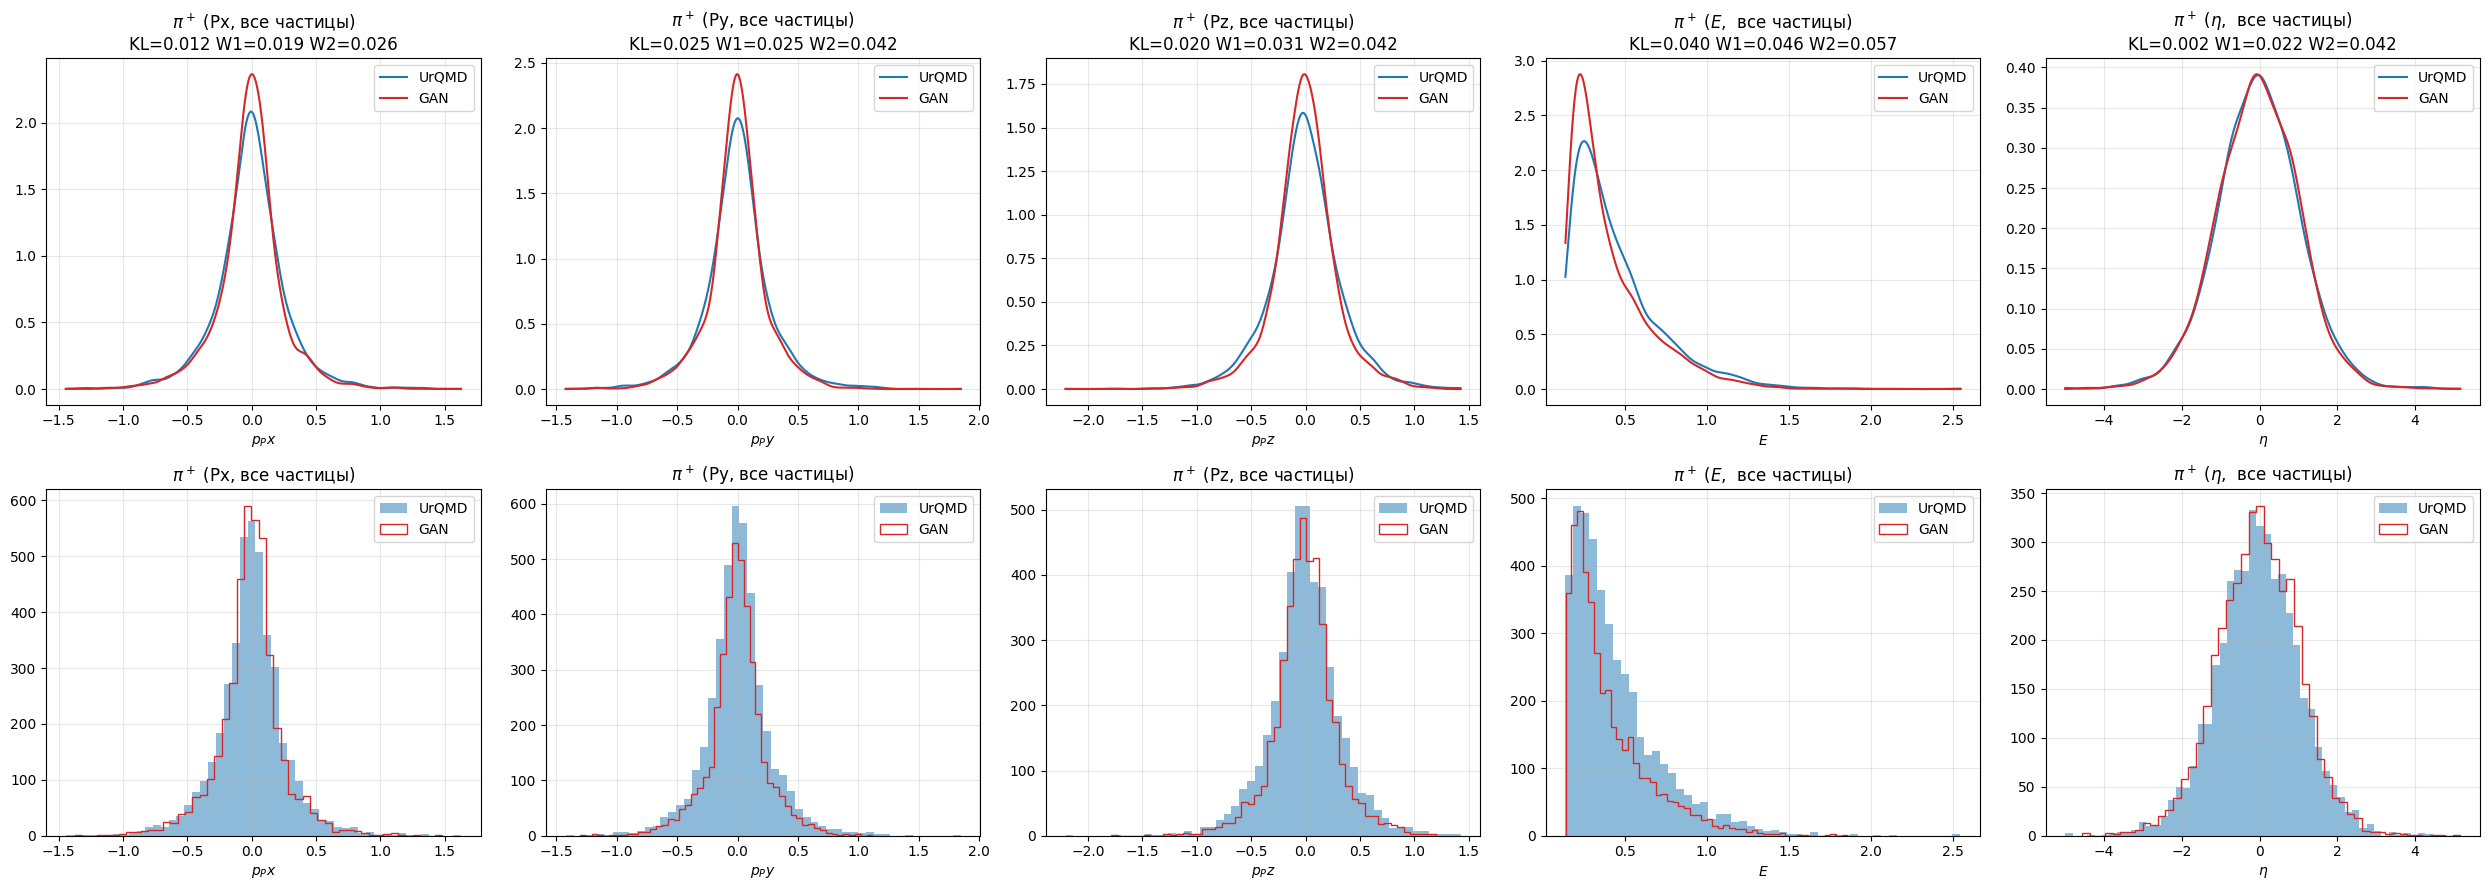

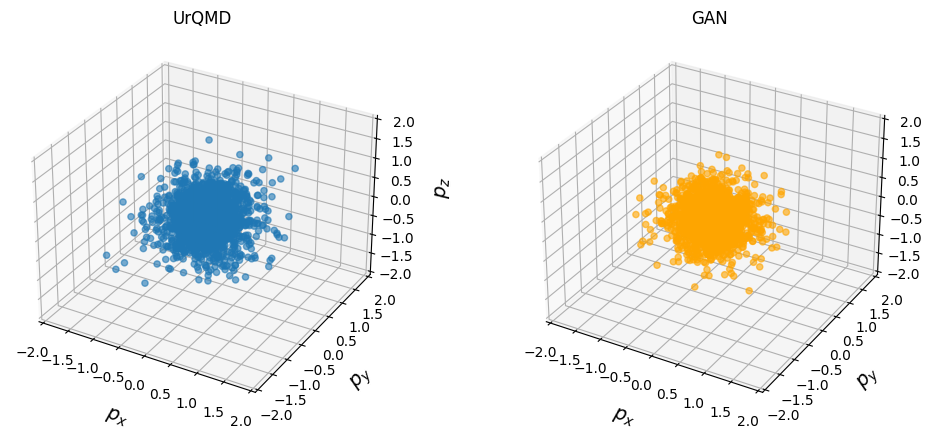

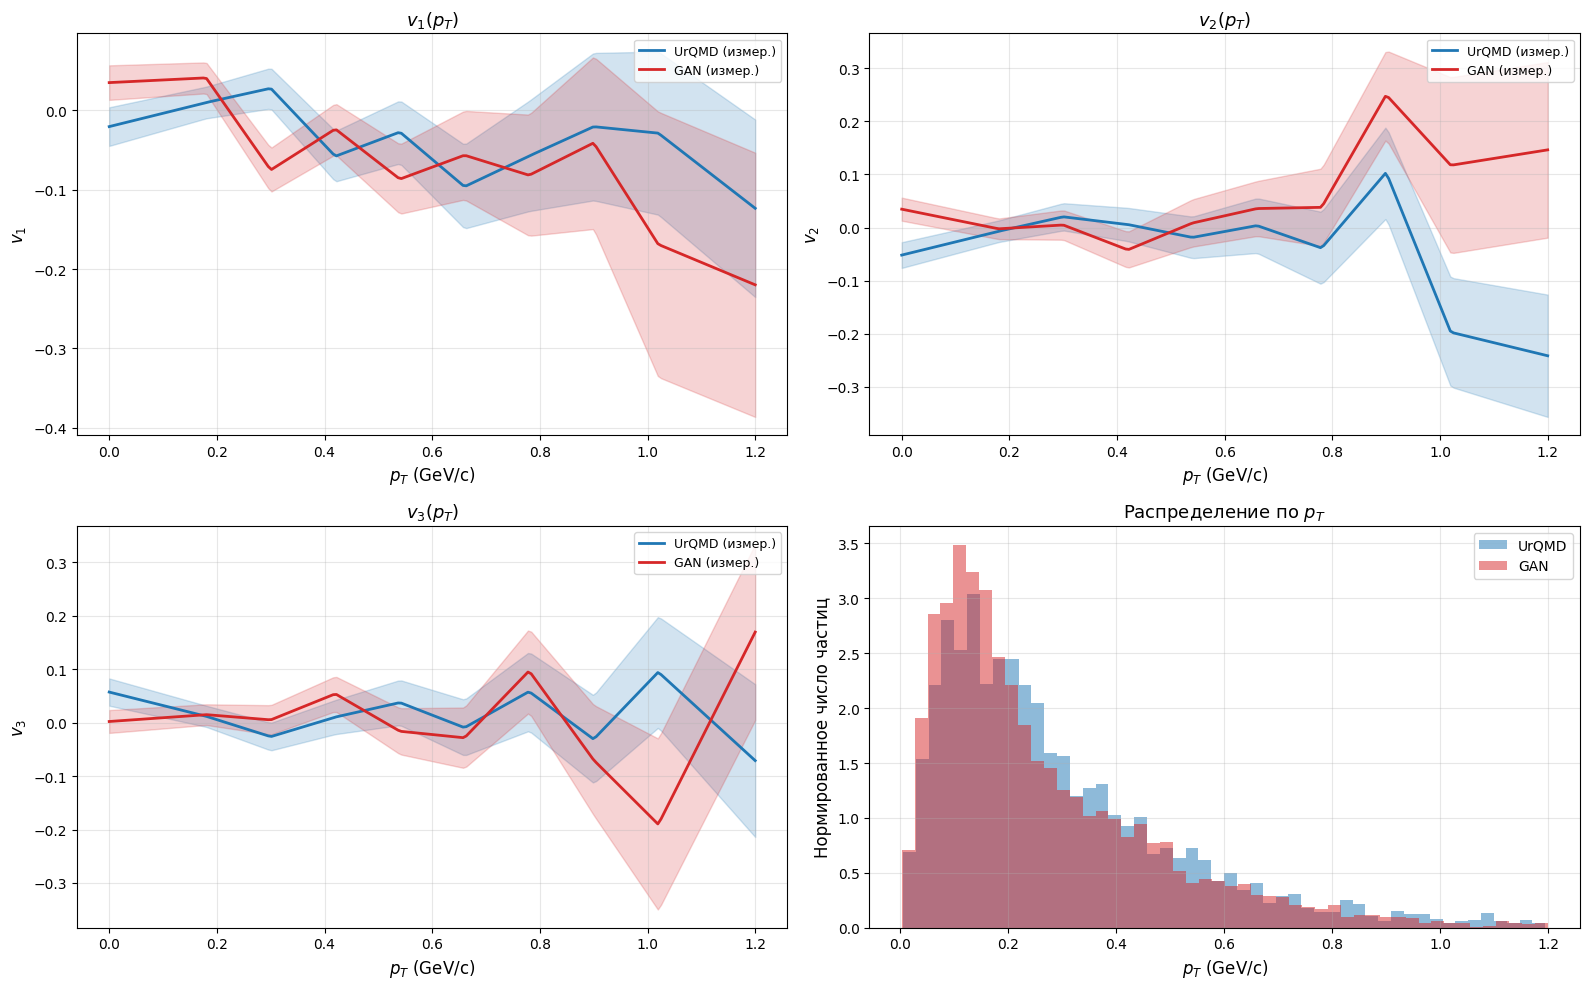

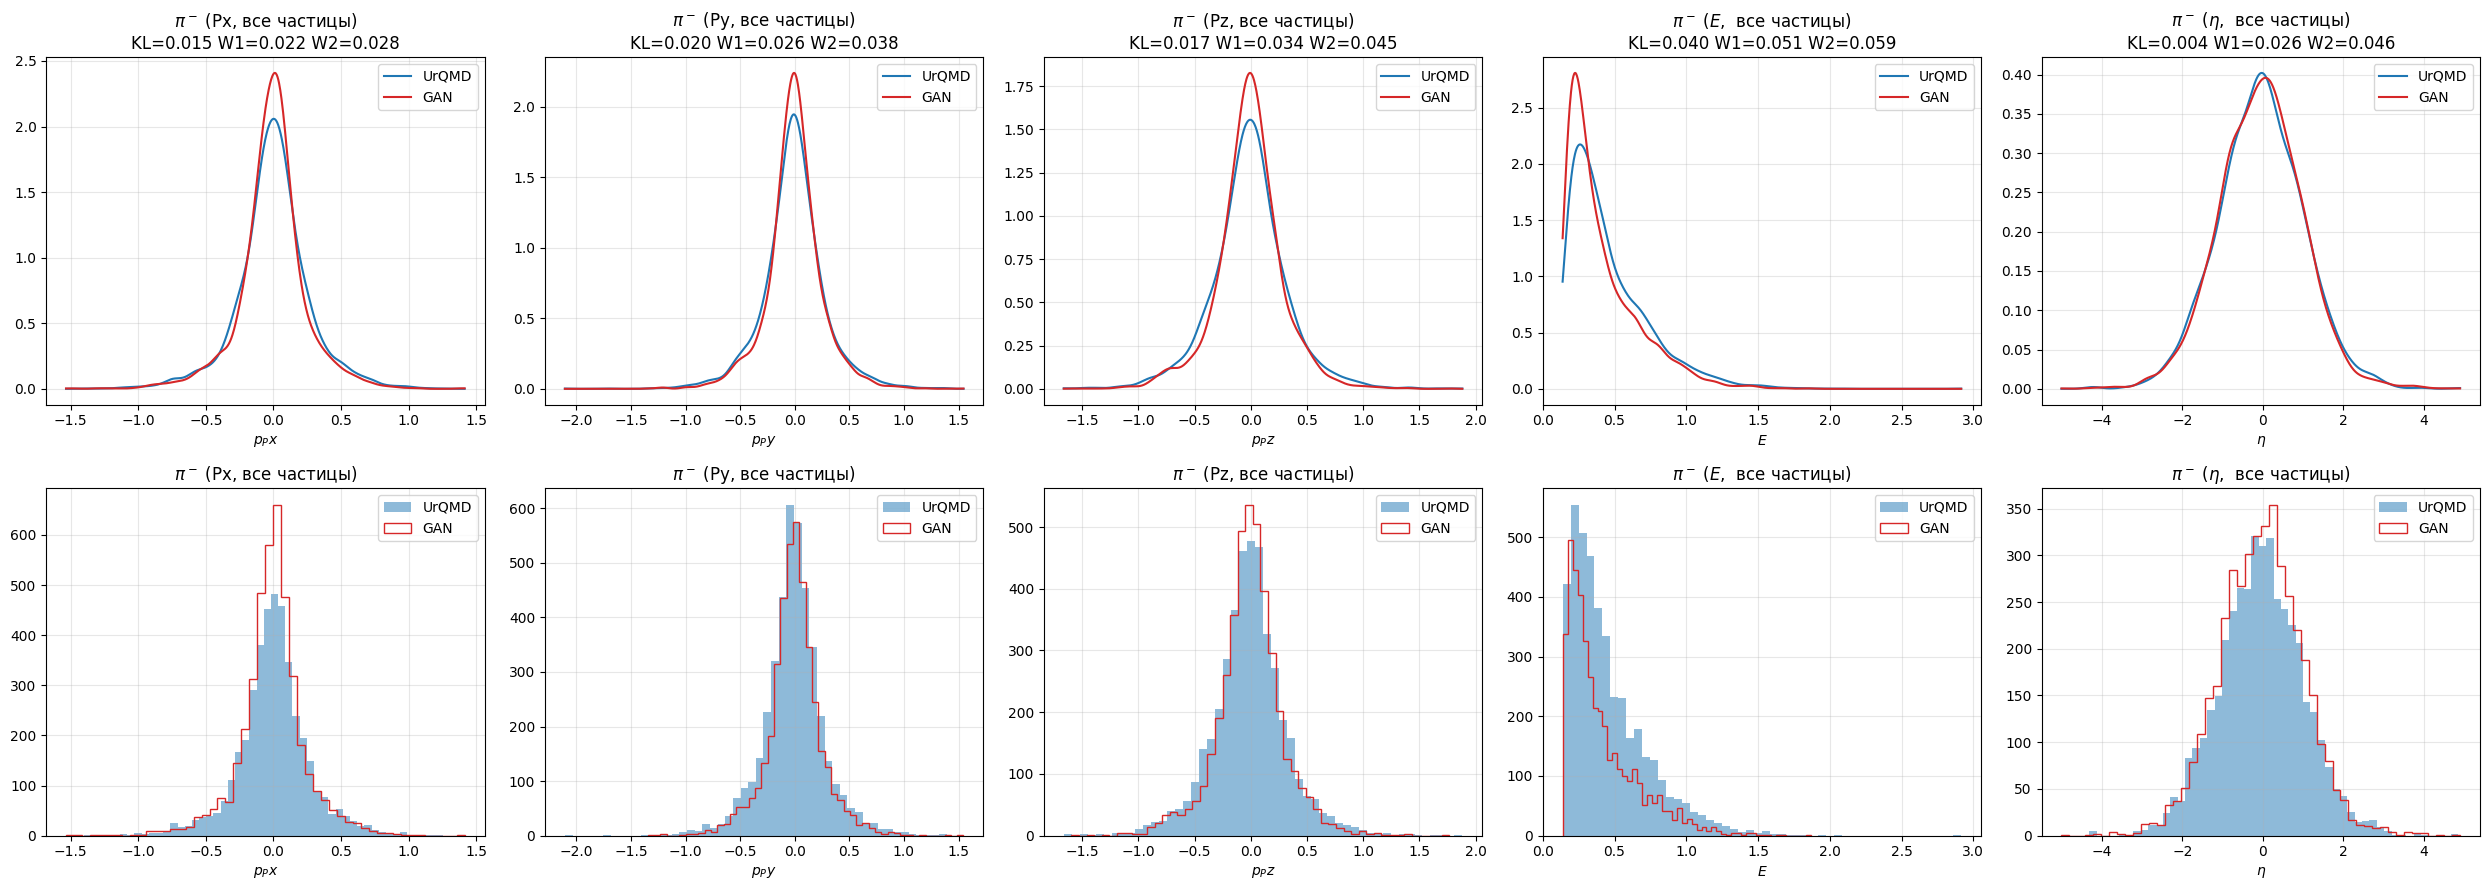

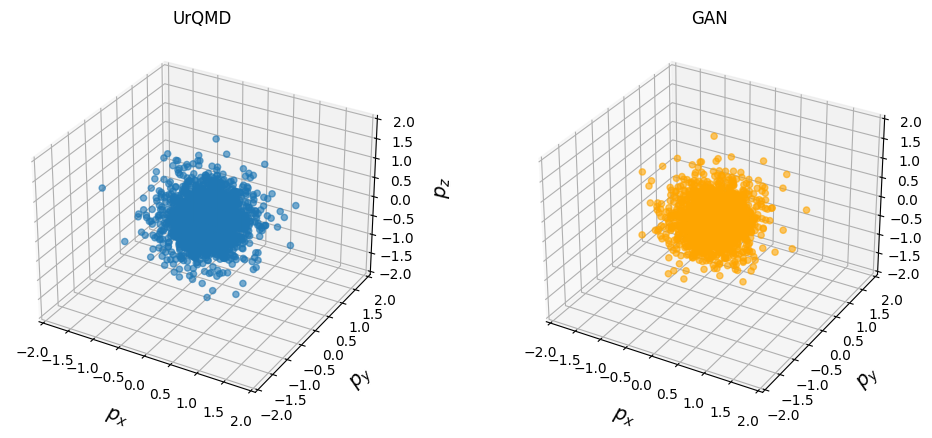

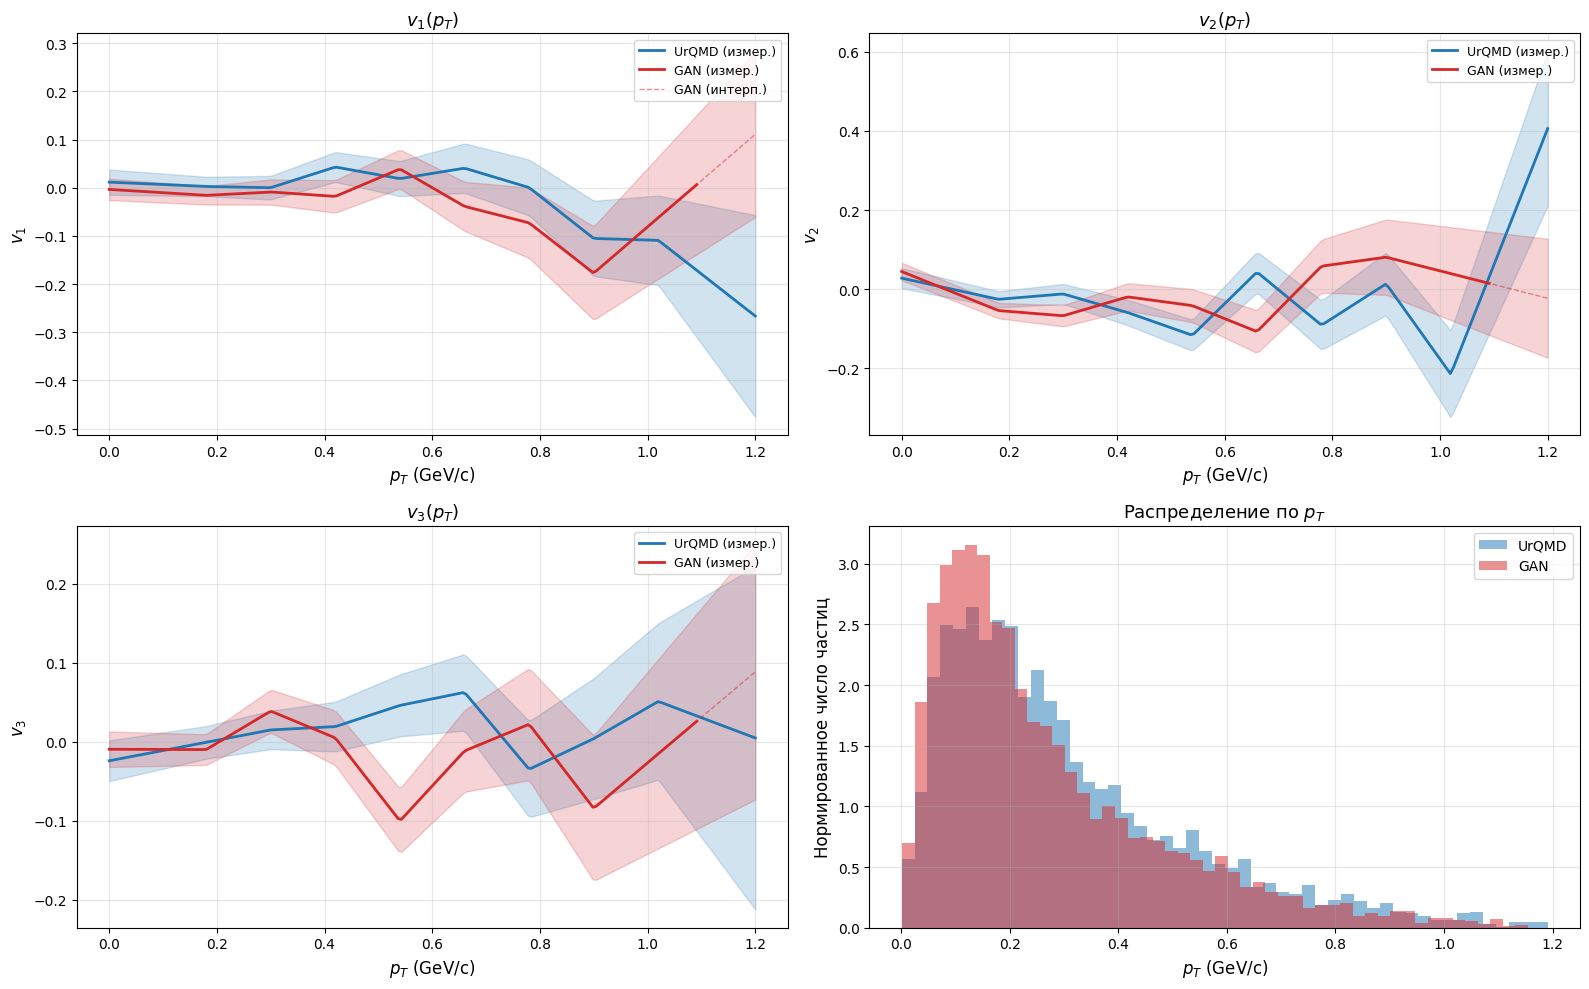

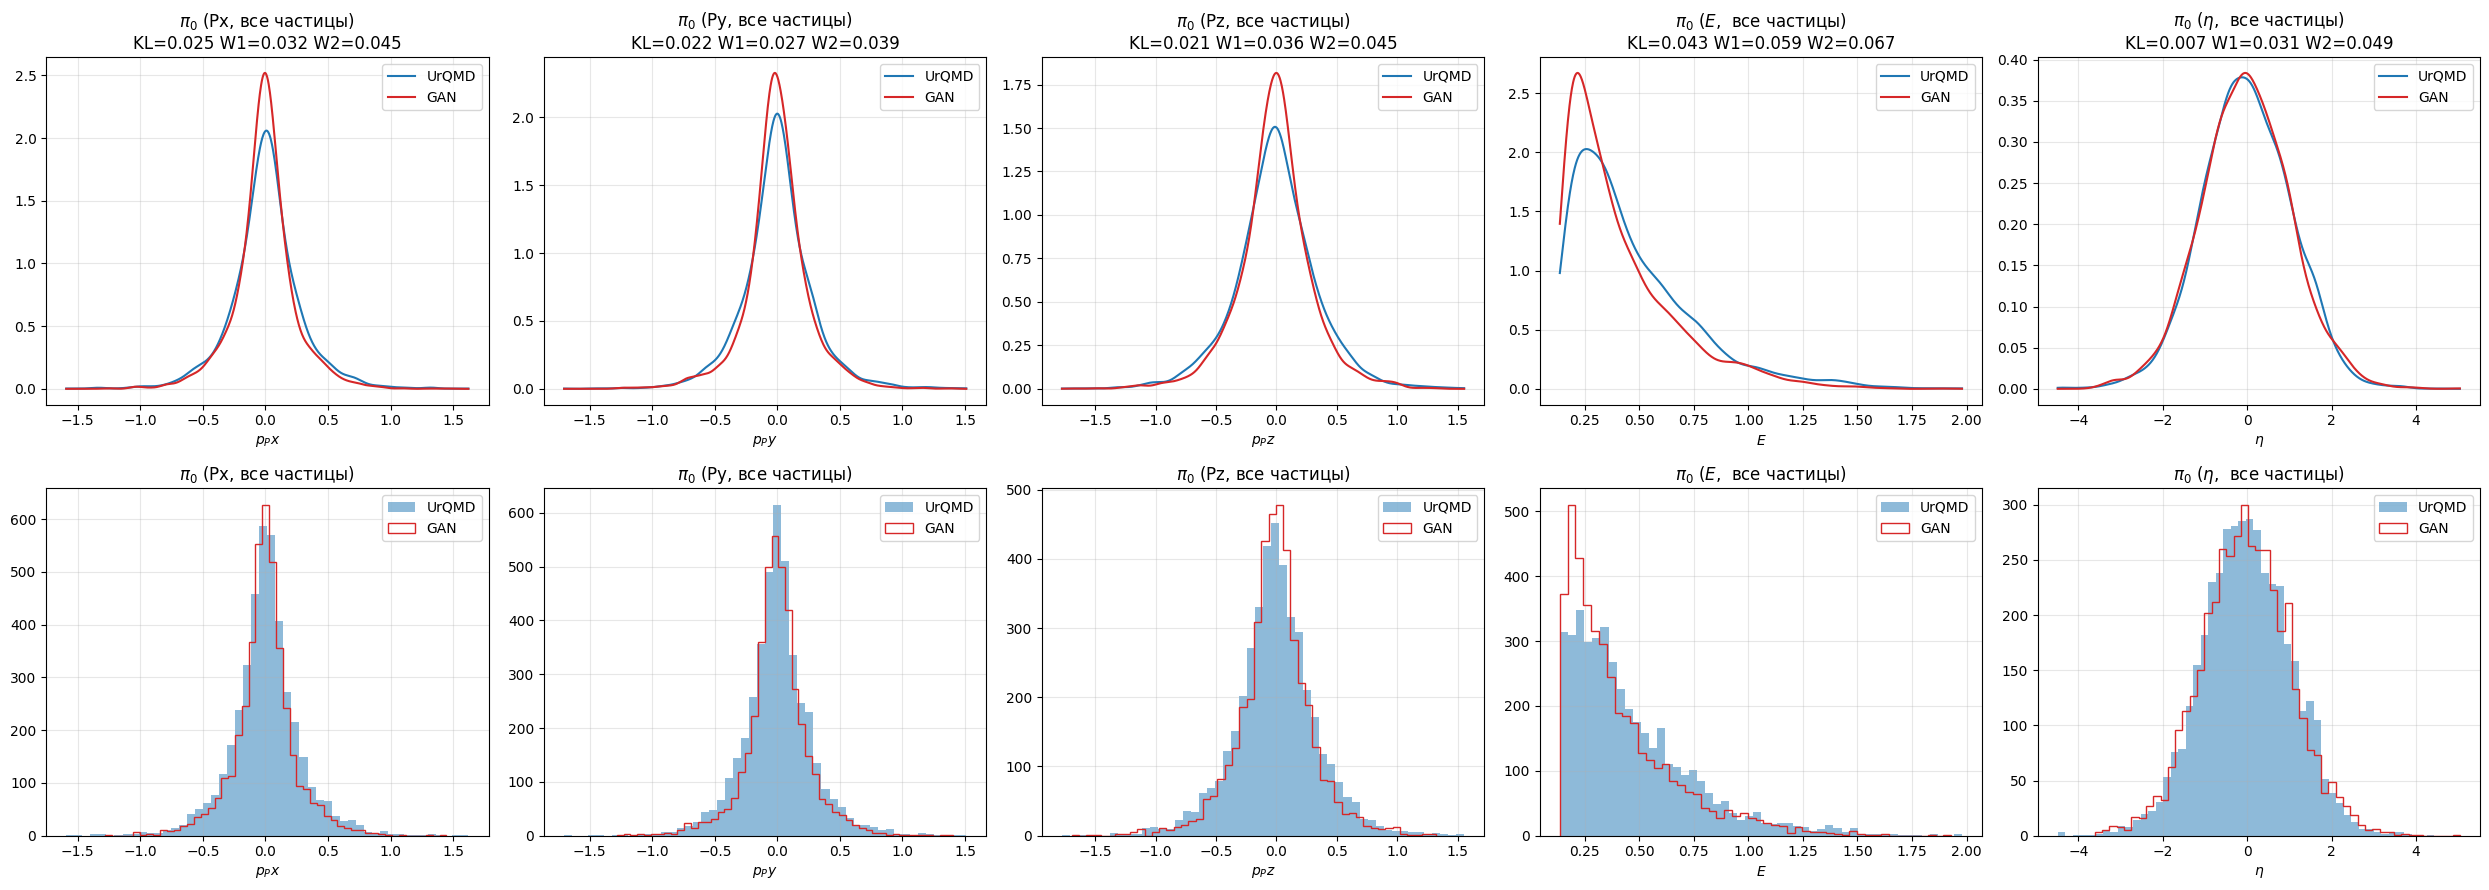

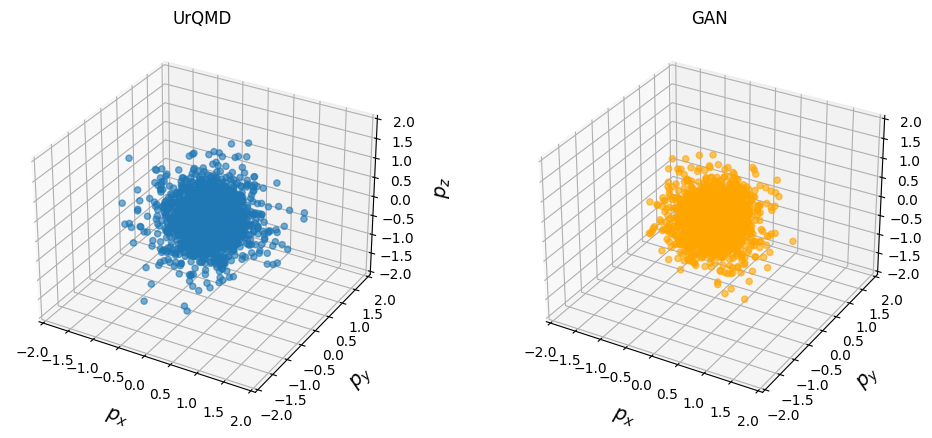

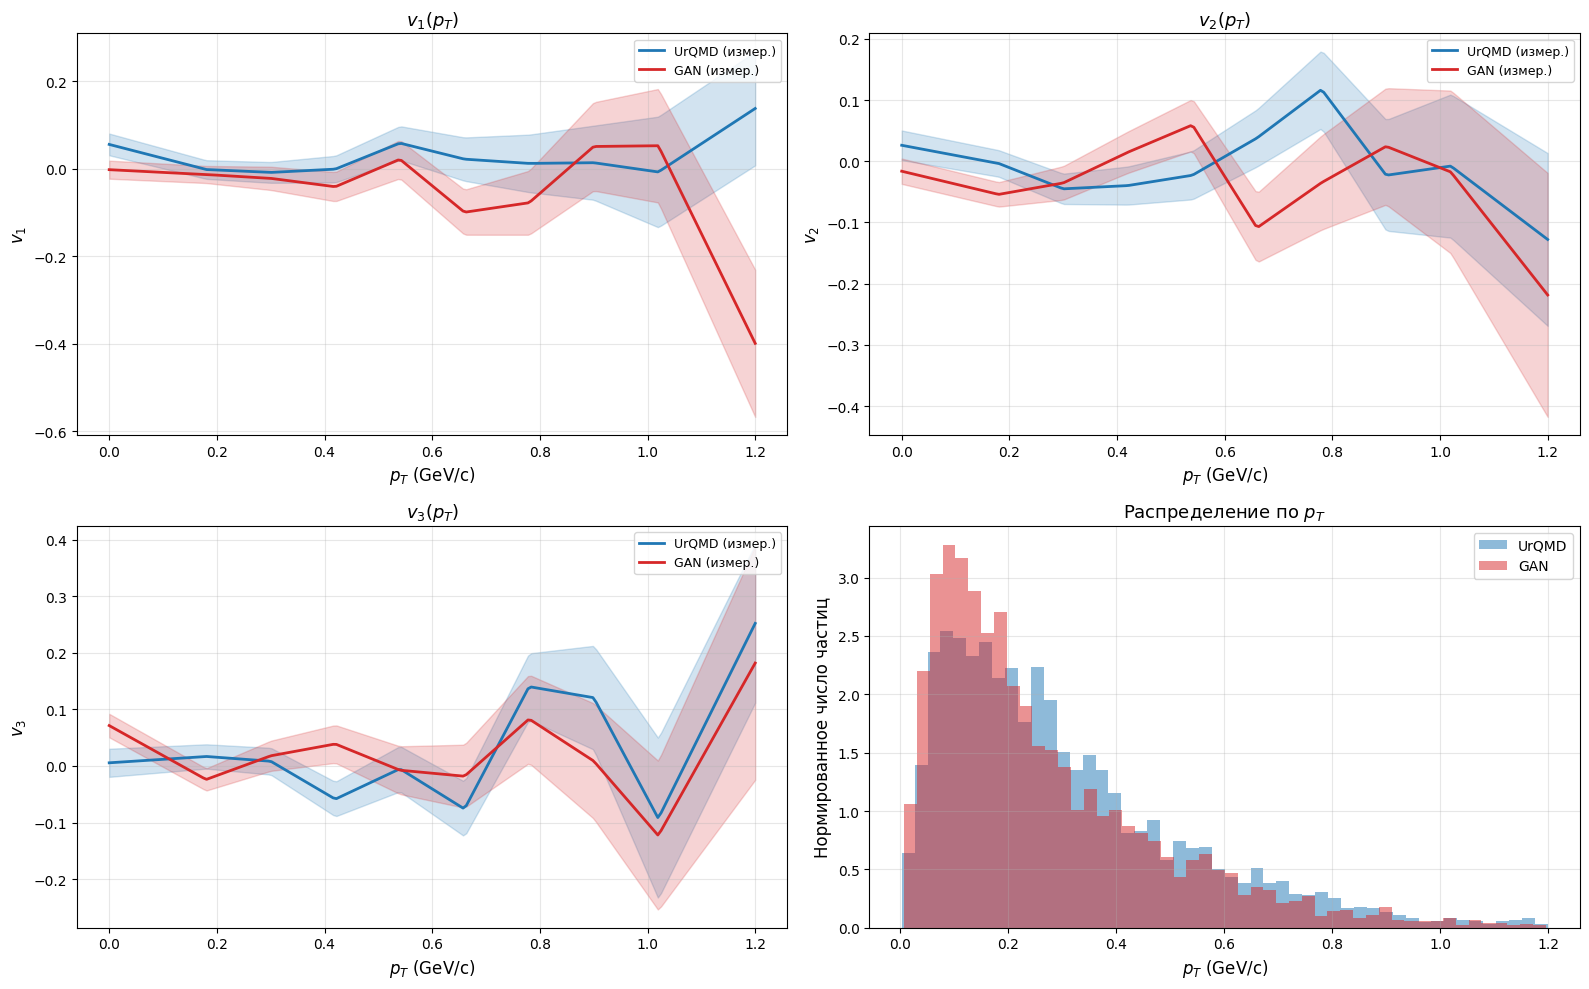

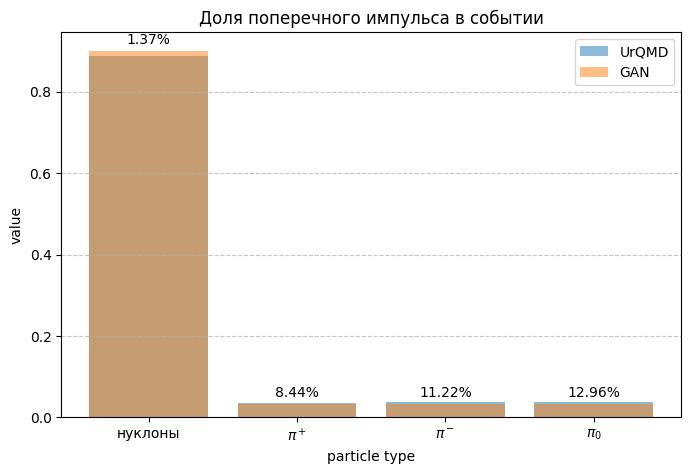

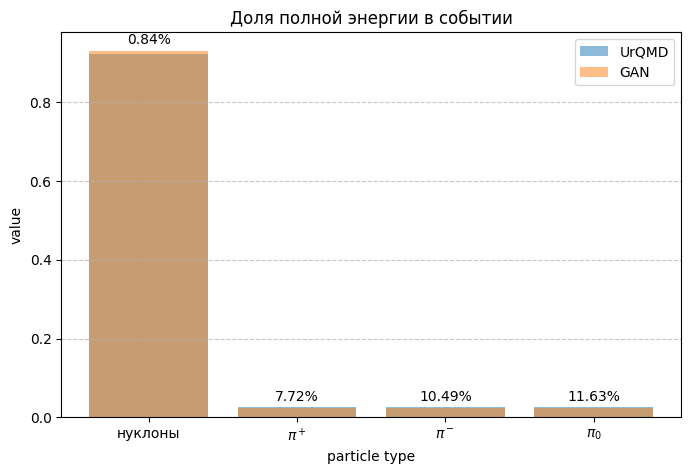

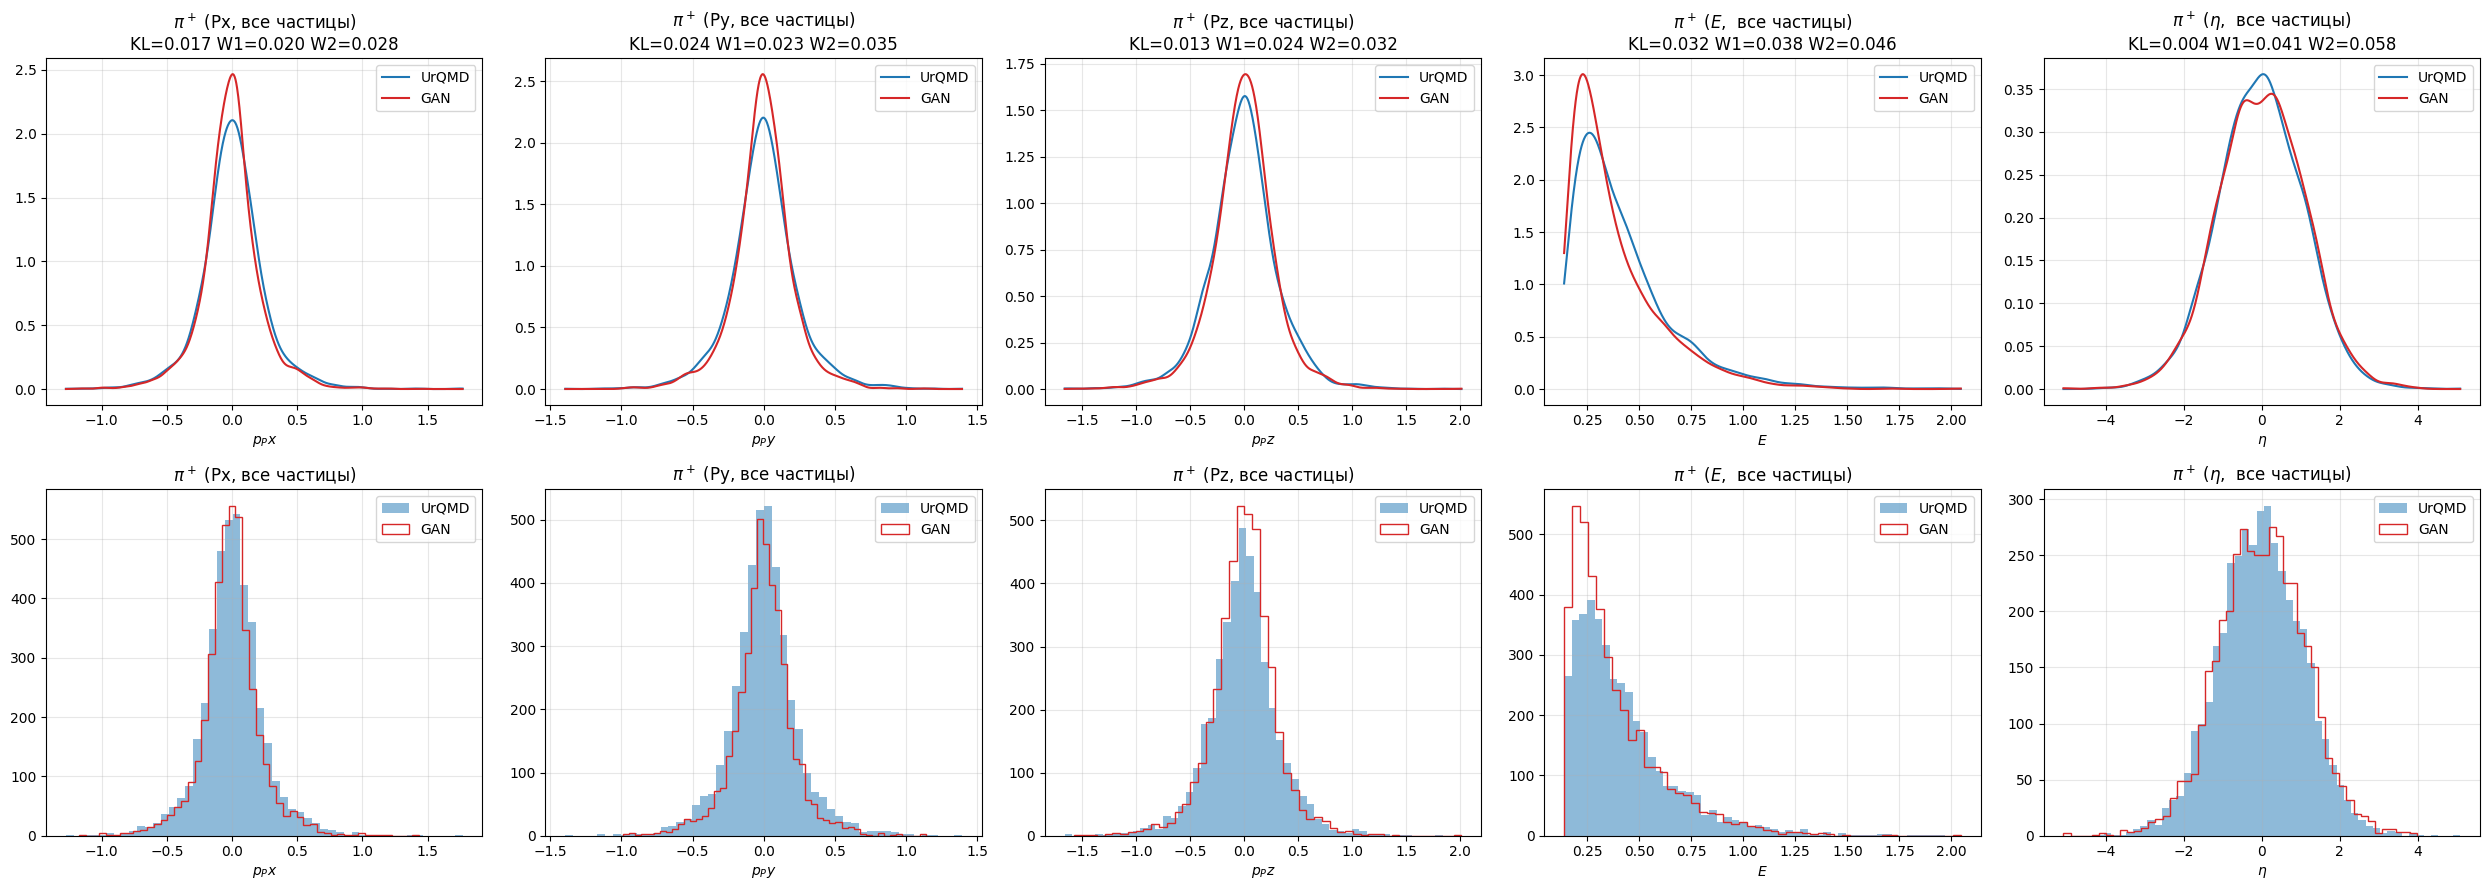

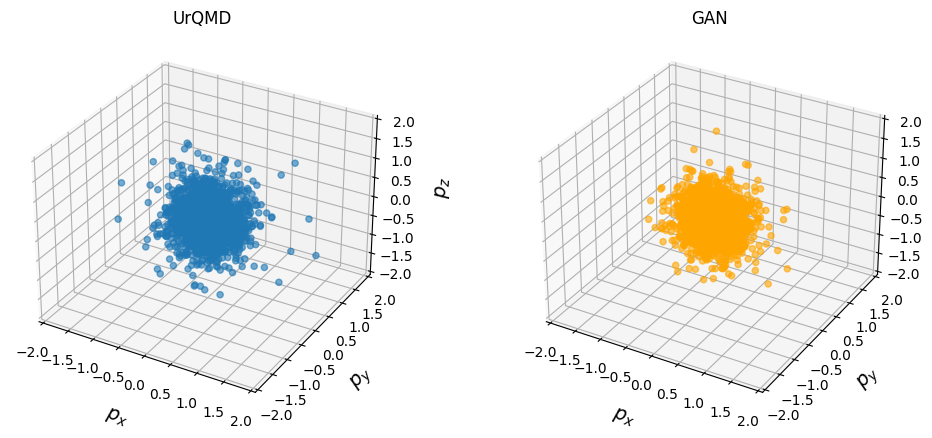

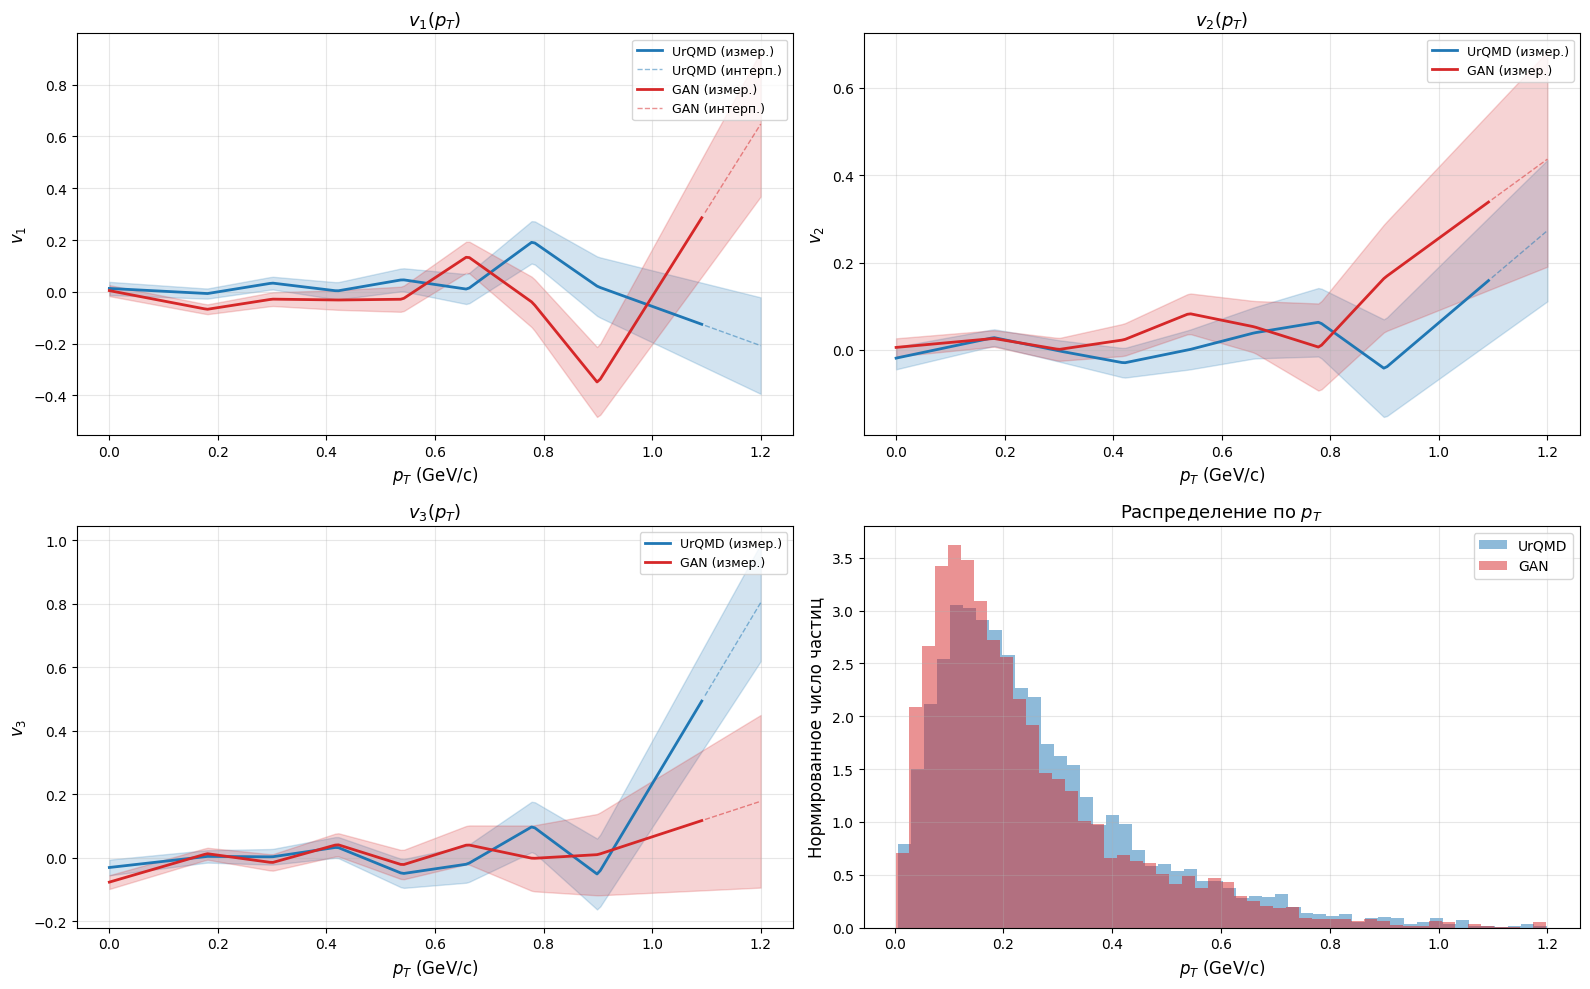

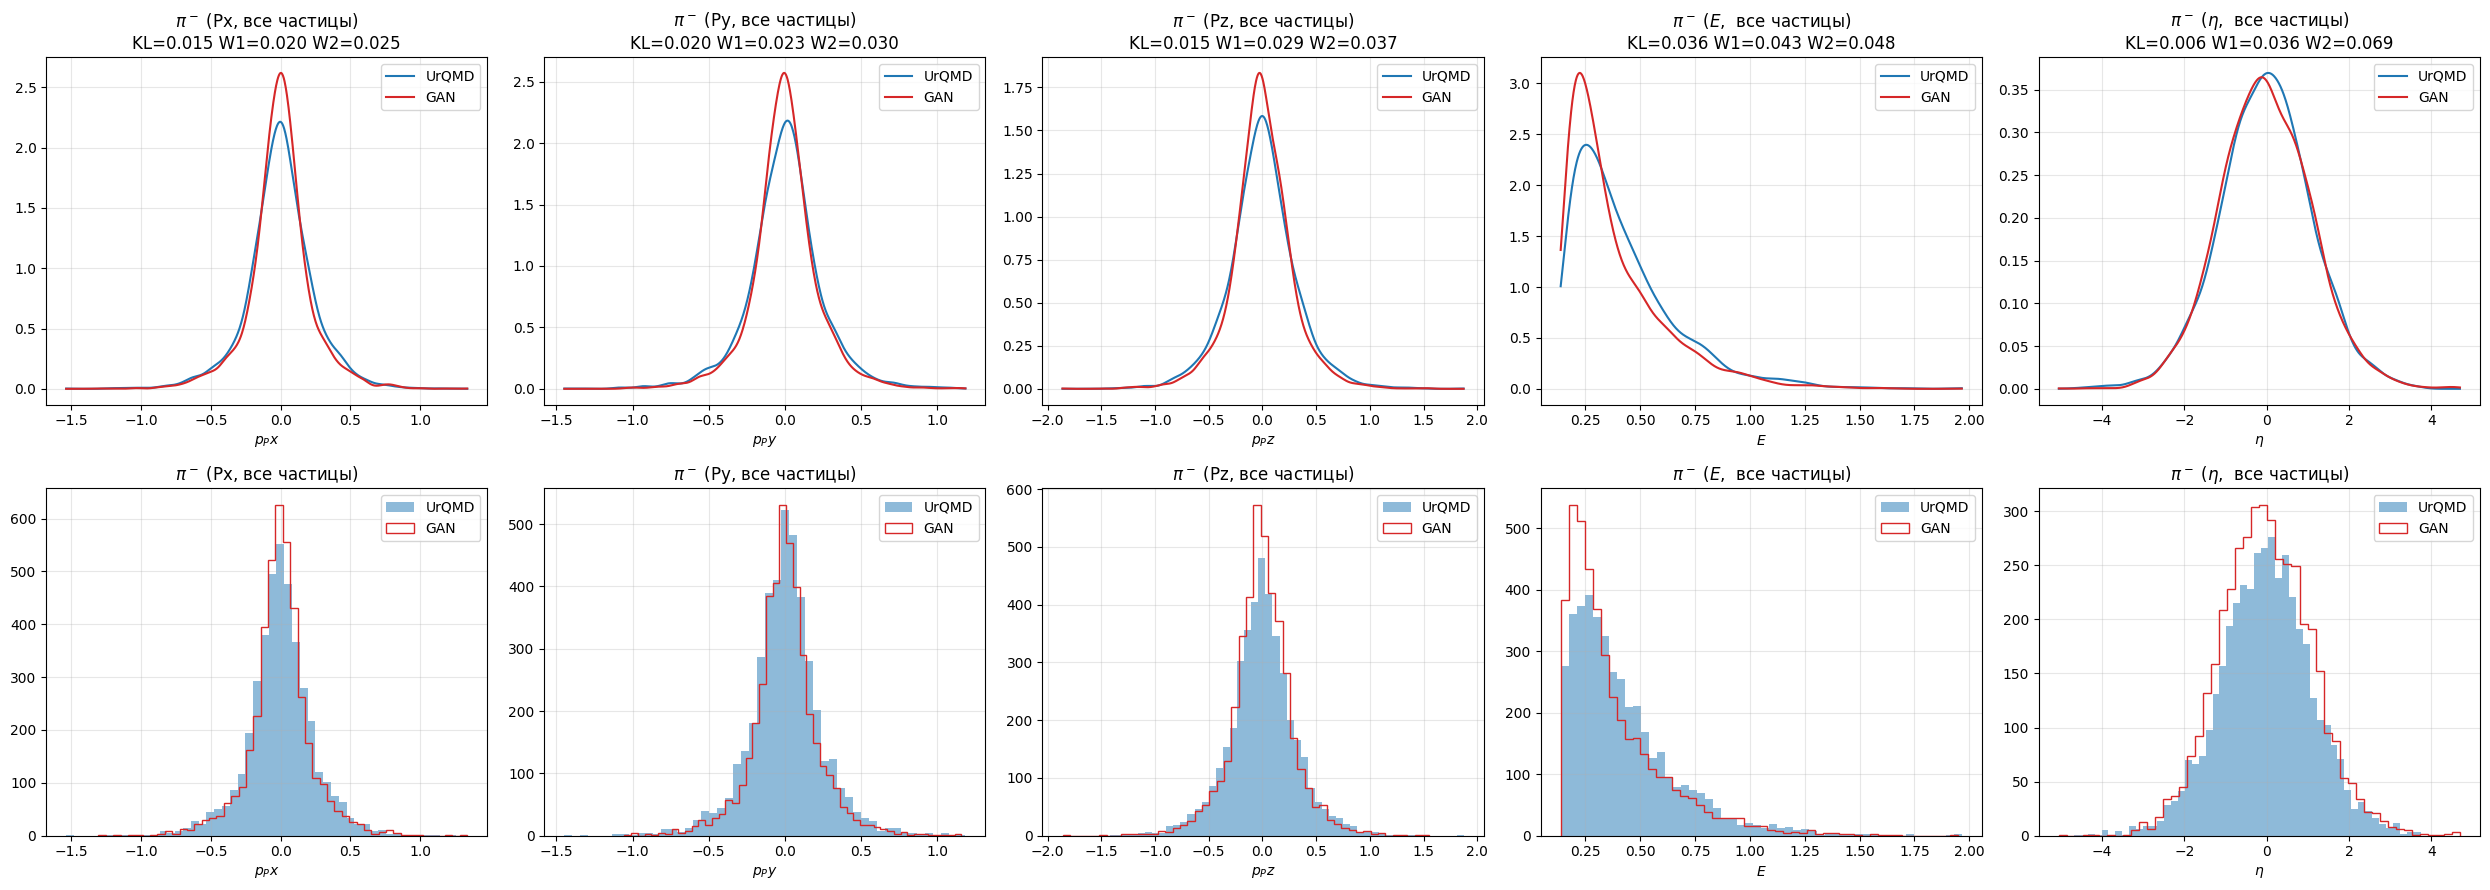

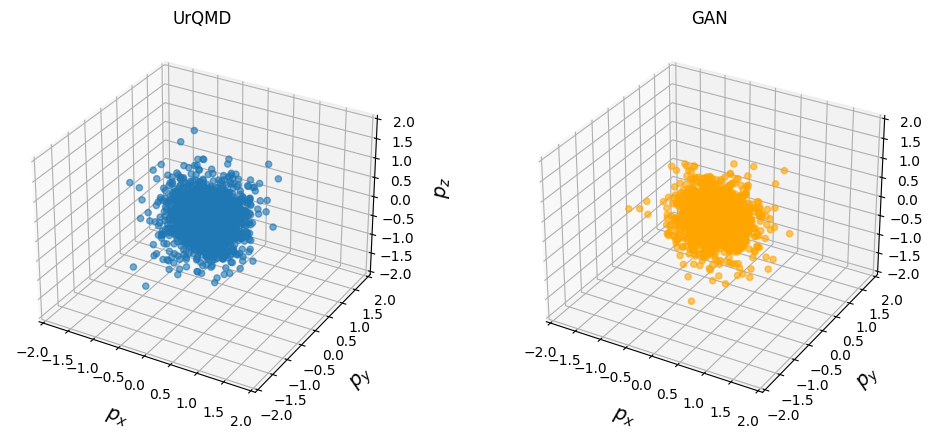

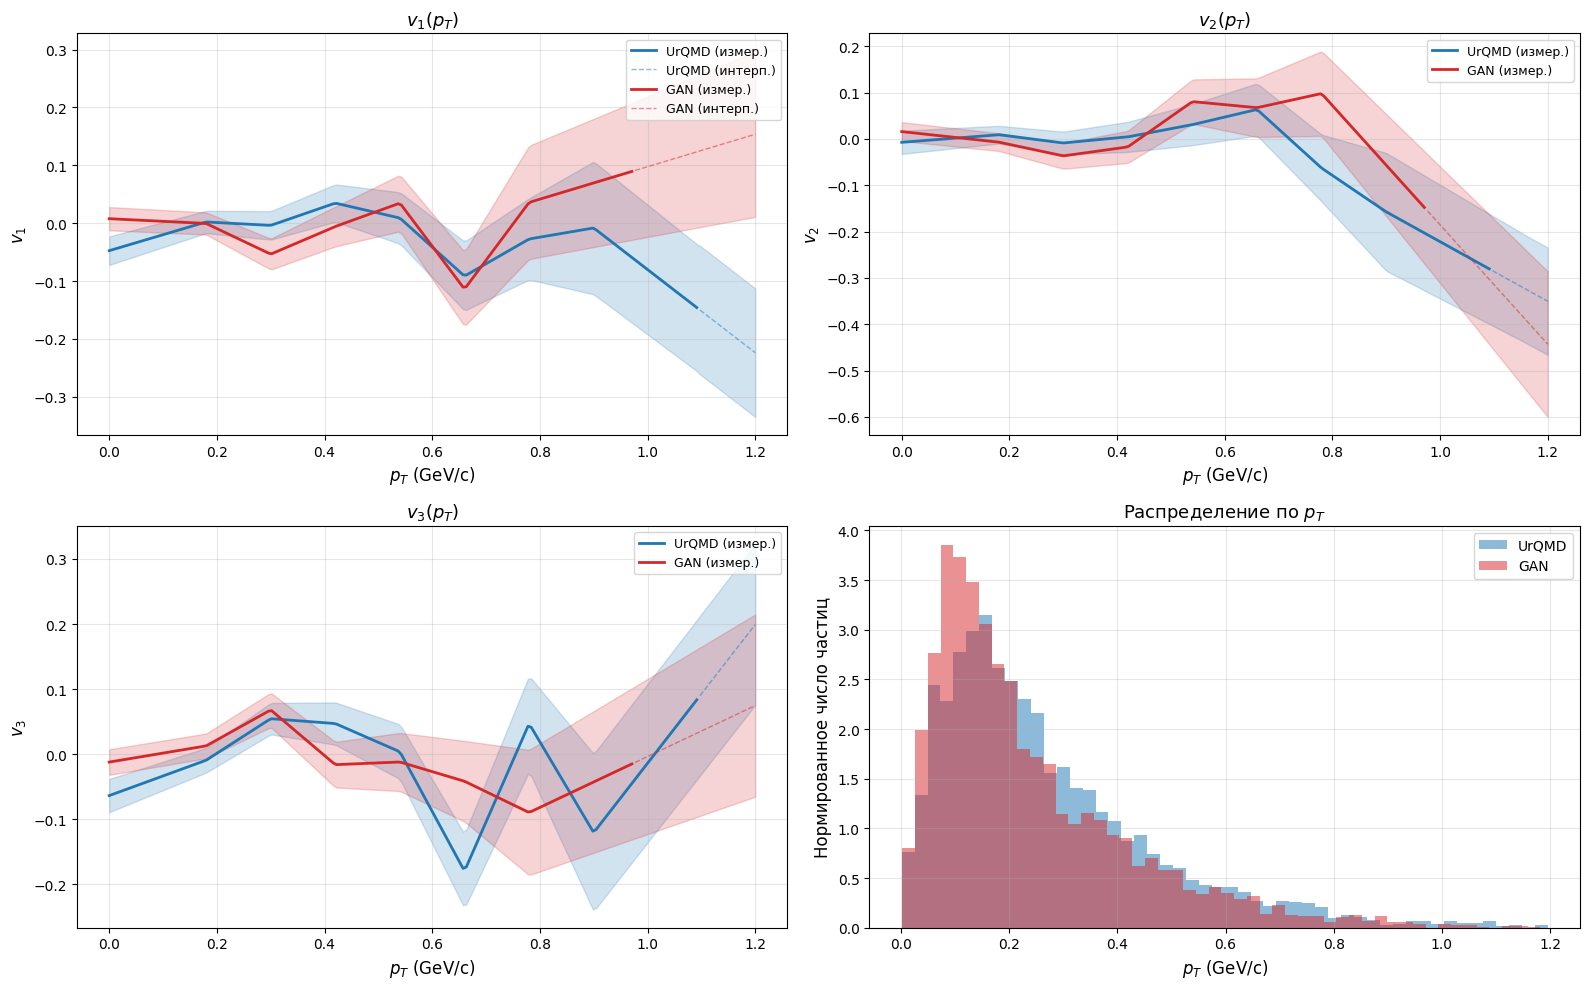

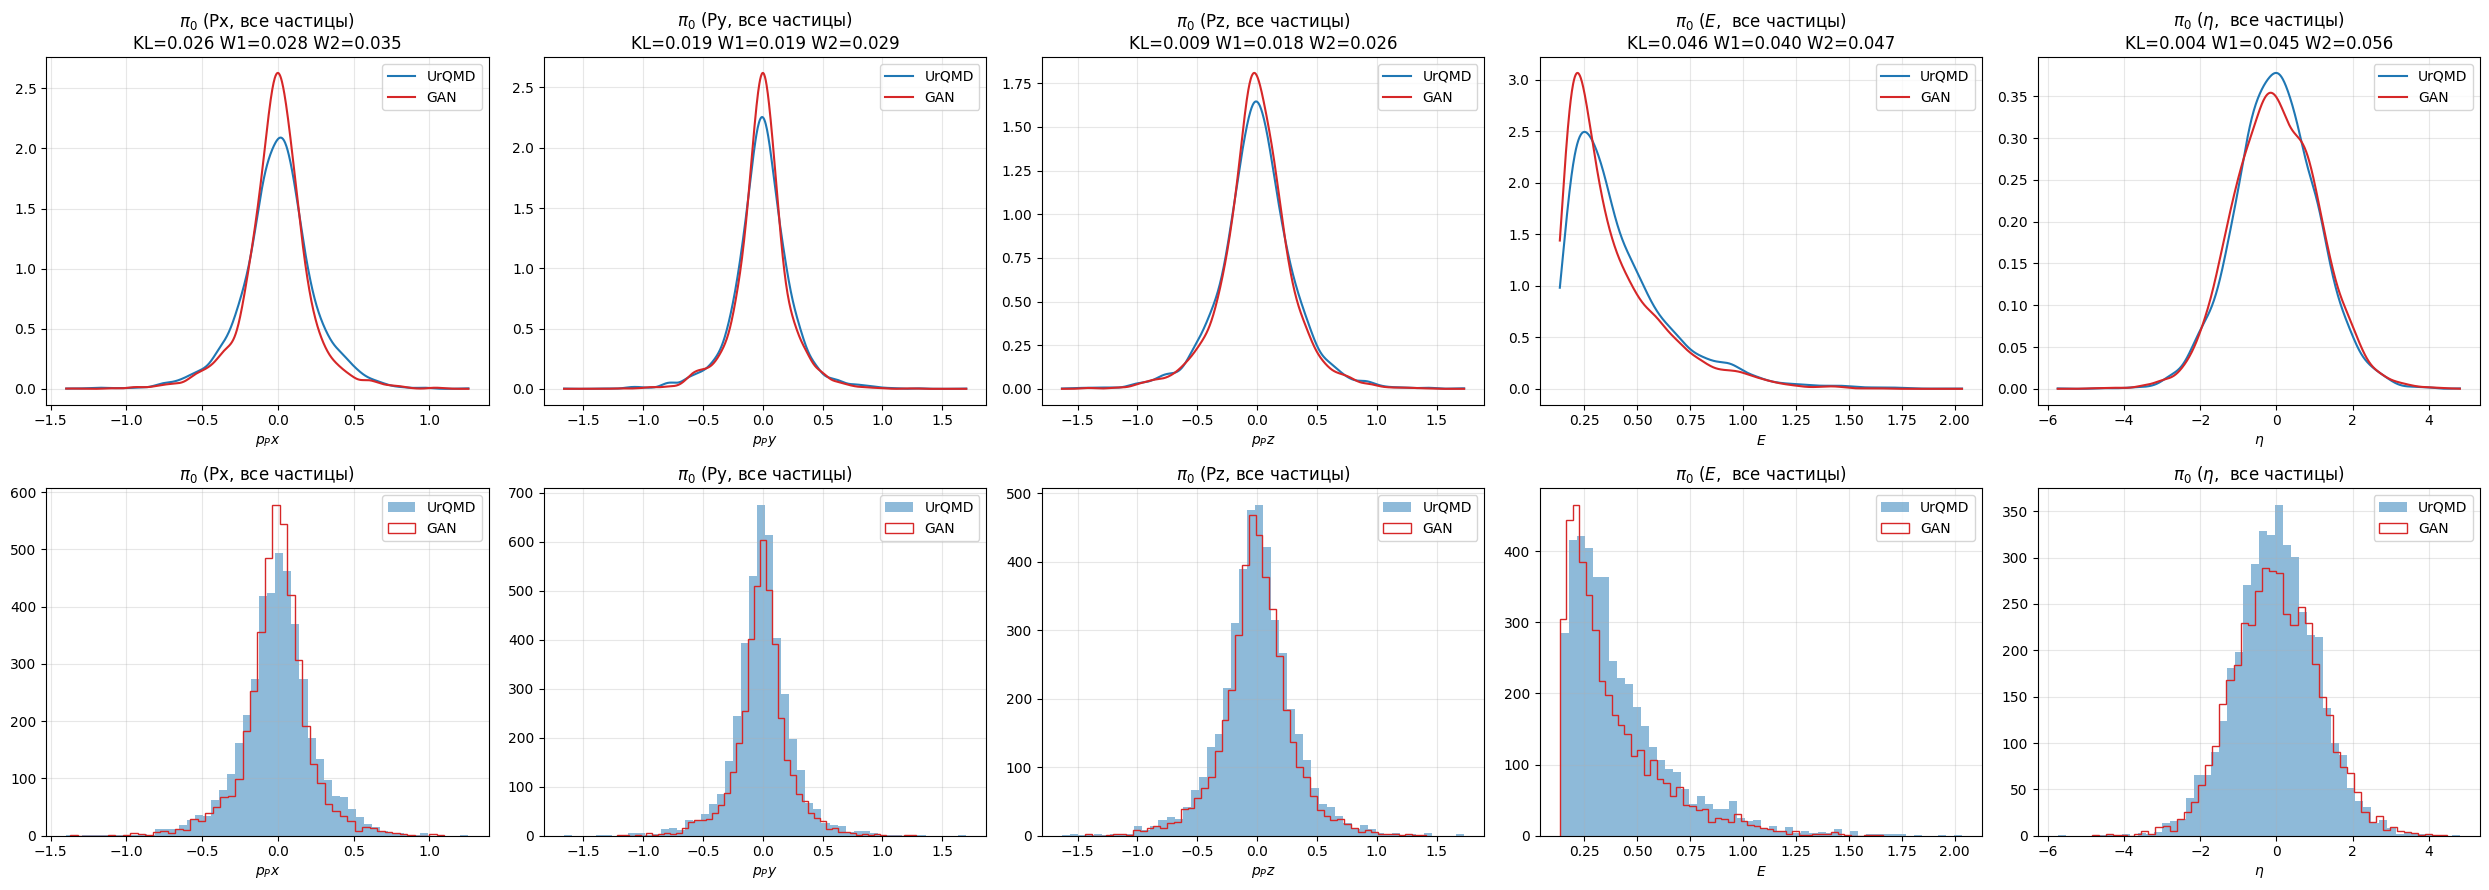

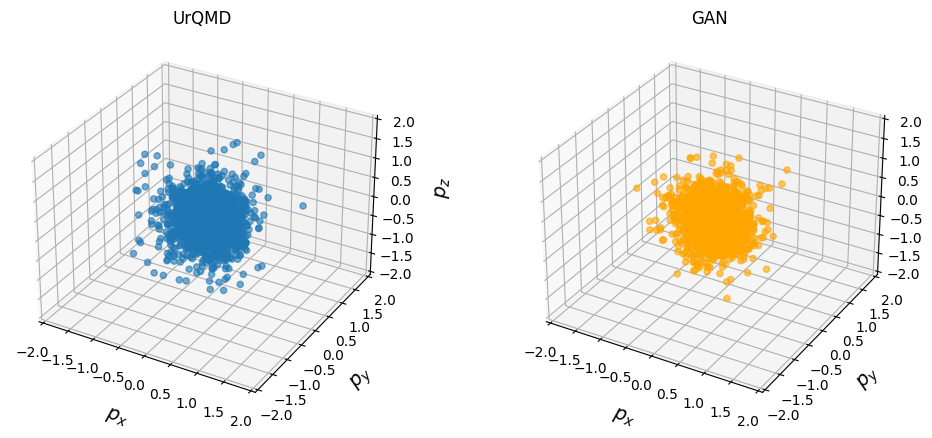

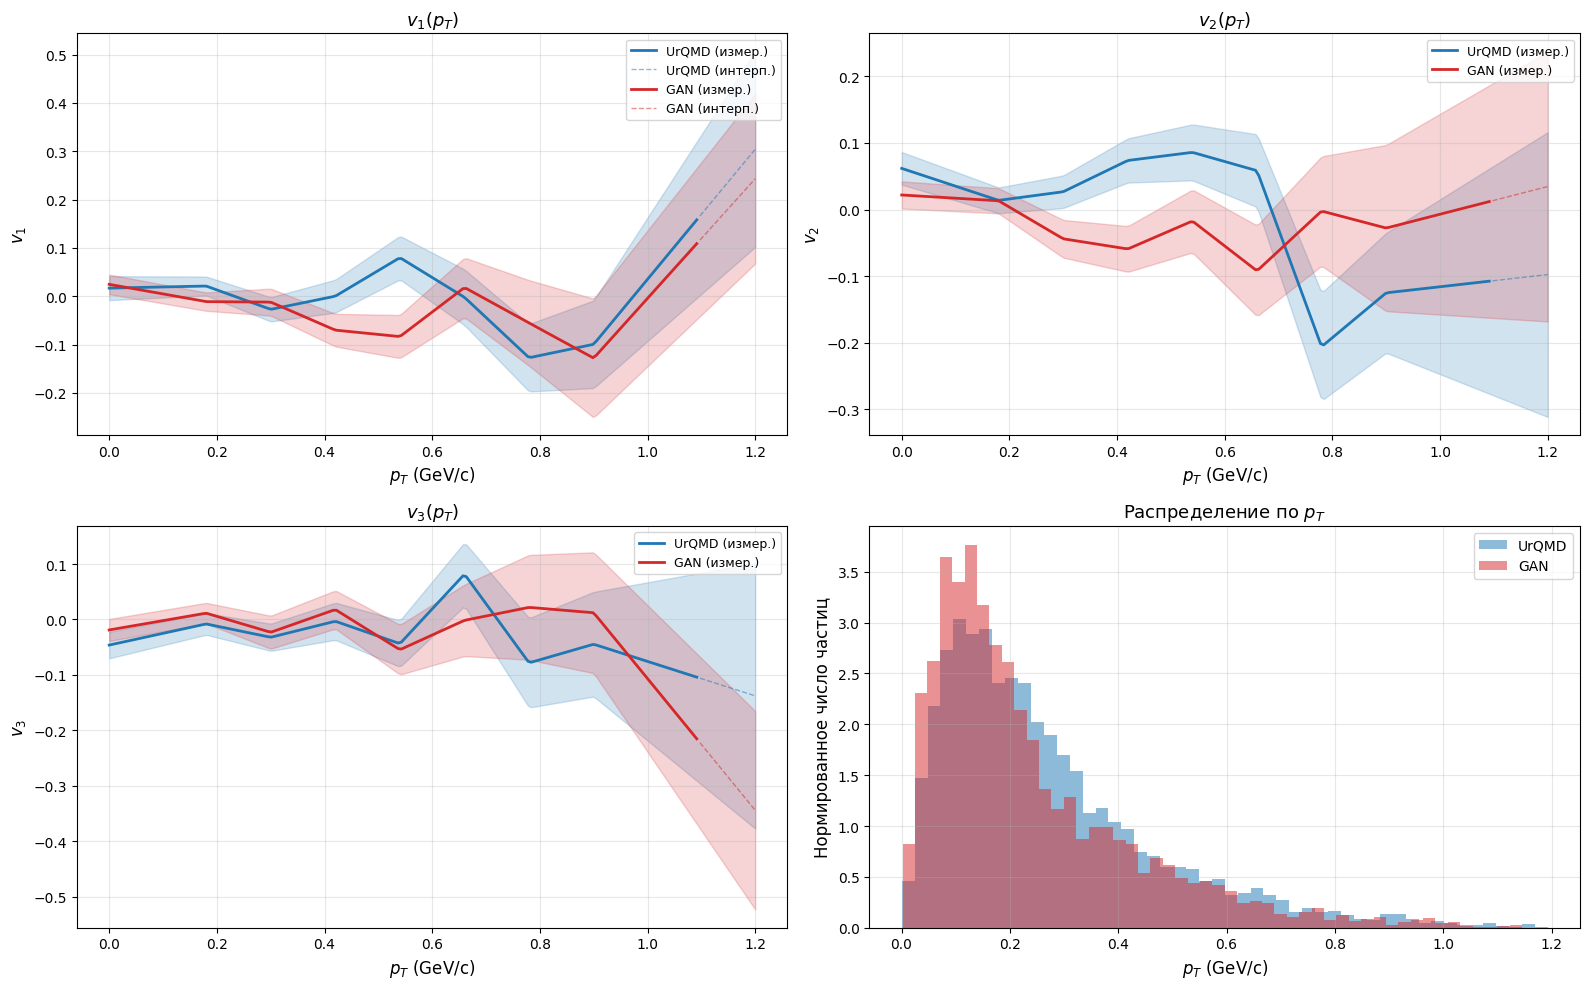

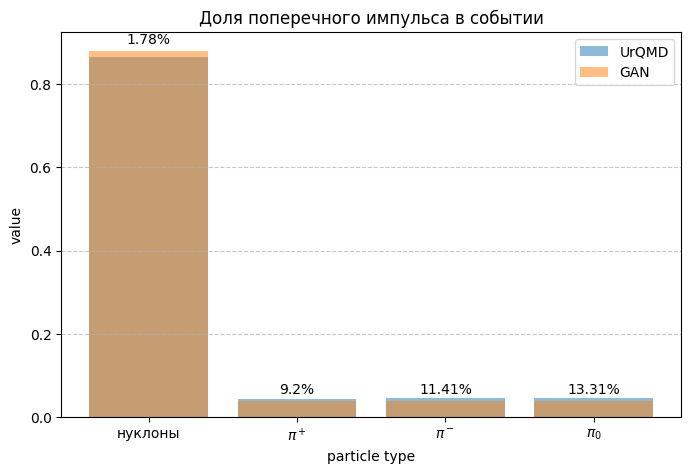

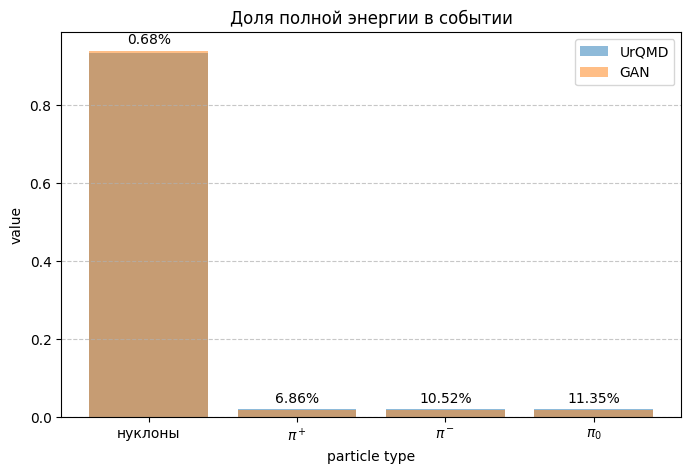

In [19]:
for _ in range(1):
    for seed in seeds:
        set_seed(seed)
        ratio = 1
        train_n_1_7 = int(0.8 * len(urqmd_1_7))
        val_n_1_7 = (len(urqmd_1_7) - train_n_1_7) // 2
        train_n_5 = ratio * train_n_1_7
        val_n_5 = ratio * val_n_1_7
        ids_1_7 = np.random.permutation(len(urqmd_1_7))
        ids_5 = np.random.permutation(len(urqmd_5))
        urqmd_train_1_7 = urqmd_1_7.iloc[ids_1_7[:train_n_1_7]]
        urqmd_val_1_7 = urqmd_1_7.iloc[ids_1_7[train_n_1_7 : train_n_1_7 + val_n_1_7]]
        urqmd_test_1_7 = urqmd_1_7.iloc[
            ids_1_7[train_n_1_7 + val_n_1_7 : train_n_1_7 + val_n_1_7 * 2]
        ]
        urqmd_train_5 = urqmd_5.iloc[ids_5[:train_n_5]]
        urqmd_val_5 = urqmd_5.iloc[ids_5[train_n_5 : train_n_5 + val_n_5]]
        urqmd_test_5 = urqmd_5.iloc[
            ids_5[train_n_5 + val_n_5 : train_n_5 + val_n_5 * 2]
        ]
        urqmd_train = pd.concat([urqmd_train_1_7, urqmd_train_5], ignore_index=True)
        urqmd_val = pd.concat([urqmd_val_1_7, urqmd_val_5], ignore_index=True)
        COUNT = {}
        COUNT_2 = {}
        for code in particles:
            selected_count = urqmd_train.apply(
                lambda x: (np.array(x["fParticles.fPdg"]) == code).sum(), axis=1
            ).values
            final_count = (
                int(np.percentile(selected_count, 0.95))
                if code in pions
                else selected_count.max()
            )
            mean_ = np.mean(selected_count)
            std_ = np.std(selected_count)
            if final_count == 0:
                final_count = int(selected_count.max())
            COUNT[code] = final_count
            COUNT_2[code] = {"mean": mean_, "std": std_}
        meson_count_max = max(
            {k: v for k, v in COUNT.items() if k not in nucleons}.values()
        )
        nucleon_count_max = max(
            {k: v for k, v in COUNT.items() if k in nucleons}.values()
        )
        train, cond_cols, nucl_cols, nucl_mask_cols = preprocess_urqmd(
            urqmd_train,
            max_size_t=meson_count_max,
            max_size_c=nucleon_count_max,
            return_cols=True,
        )
        val = preprocess_urqmd(
            urqmd_val, max_size_t=meson_count_max, max_size_c=nucleon_count_max
        )
        test_1_7 = preprocess_urqmd(
            urqmd_test_1_7, max_size_t=meson_count_max, max_size_c=nucleon_count_max
        )
        test_5 = preprocess_urqmd(
            urqmd_test_5, max_size_t=meson_count_max, max_size_c=nucleon_count_max
        )
        means = {}
        stds = {}
        for col in cond_cols:
            means[col] = train[col].mean()
            stds[col] = train[col].std()
            train[col] = (train[col] - means[col]) / stds[col]
            val[col] = (val[col] - means[col]) / stds[col]
            test_1_7[col] = (test_1_7[col] - means[col]) / stds[col]
            test_5[col] = (test_5[col] - means[col]) / stds[col]
        train_cond = train[cond_cols].values.astype(float)
        train_nucl = list(train[nucl_cols[0]].values)
        train_nucl_mask = list(train[nucl_mask_cols[0]].values)
        train_label = train["label"].values
        train_event = train["event"].values
        train_mom = list(train["target_moms"].values)
        train_mask = list(train["target_mask"].values)
        val_cond = val[cond_cols].values.astype(float)
        val_nucl = list(val[nucl_cols[0]].values)
        val_nucl_mask = list(val[nucl_mask_cols[0]].values)
        val_label = val["label"].values
        val_event = val["event"].values
        val_mom = list(val["target_moms"].values)
        val_mask = list(val["target_mask"].values)
        test_1_7_cond = test_1_7[cond_cols].values.astype(float)
        test_1_7_nucl = list(test_1_7[nucl_cols[0]].values)
        test_1_7_nucl_mask = list(test_1_7[nucl_mask_cols[0]].values)
        test_1_7_label = test_1_7["label"].values
        test_1_7_event = test_1_7["event"].values
        test_1_7_mom = list(test_1_7["target_moms"].values)
        test_1_7_mask = list(test_1_7["target_mask"].values)
        test_5_cond = test_5[cond_cols].values.astype(float)
        test_5_nucl = list(test_5[nucl_cols[0]].values)
        test_5_nucl_mask = list(test_5[nucl_mask_cols[0]].values)
        test_5_label = test_5["label"].values
        test_5_event = test_5["event"].values
        test_5_mom = list(test_5["target_moms"].values)
        test_5_mask = list(test_5["target_mask"].values)
        urqmd_train_dataset = TensorDataset(
            torch.tensor(train_mom, dtype=torch.float32),
            torch.tensor(train_cond, dtype=torch.float32),
            torch.tensor(train_label),
            torch.tensor(train_mask, dtype=torch.float32),
        )
        urqmd_train_dataloader = DataLoader(
            urqmd_train_dataset, batch_size=batch_size, shuffle=True
        )
        num_classes = len(pions)
        extern_cond_d = len(cond_cols)
        G = Pion_Gan_Generator(
            latent_global=latent_dim,
            latent_local=latent_local_dim,
            num_labels=num_classes,
            feats=feat_dim,
            max_len=meson_count_max,
            d_model=hid_dim,
            n_heads=n_heads,
            extern_cond_d=extern_cond_d,
            d_ff=hid_dim * 2,
            n_modes=1,
            use_learnable_noise=False,
            n_layers=num_layers_gen,
            # use_weight_norm=True
        ).to(device)
        D = Pion_Gan_Discriminator(
            num_labels=num_classes,
            feats=feat_dim,
            d_model=hid_dim,
            n_heads=n_heads,
            d_ff=hid_dim * 2,
            extern_cond_d=extern_cond_d,
            n_layers=num_layers_disc,
            # use_weight_norm=True
        ).to(device)

        opt_g = optim.Adam(G.parameters(), lr=lr, betas=betas)
        opt_d = optim.Adam(D.parameters(), lr=lr, betas=betas)

        G, G_shadow, D = train_and_test(
            G=G,
            D=D,
            train_loader=urqmd_train_dataloader,
            optim_G=opt_g,
            optim_D=opt_d,
            device=device,
            mode="lsgan",
            d_iters=d_iters,
            epochs=epochs,
            train_epoch_func=train_epoch_transformer,
            generate_func=generate_transformer,
            val_mom_obj={0: val_mom},
            val_cond_obj={0: val_cond},
            val_label_obj={0: val_label},
            val_mask_obj={0: val_mask},
            val_nucl_mask_obj={0: val_nucl_mask},
            val_nucl_obj={0: val_nucl},
            val_event_obj={1.7: val_event},
            test_mom_obj={1.7: test_1_7_mom, 5: test_5_mom},
            test_cond_obj={1.7: test_1_7_cond, 5: test_5_cond},
            test_label_obj={1.7: test_1_7_label, 5: test_5_label},
            test_mask_obj={1.7: test_1_7_mask, 5: test_5_mask},
            test_nucl_mask_obj={1.7: test_1_7_nucl_mask, 5: test_5_nucl_mask},
            test_nucl_obj={1.7: test_1_7_nucl, 5: test_5_nucl},
            test_event_obj={1.7: test_1_7_event, 5: test_5_event},
            metrics_mode_name="std",
            final_metrics=METRICS,
            seeds=[seed],
            num_classes=num_classes,
            meson_count_max=meson_count_max,
            use_shadow=True,
            ema_beta=0.999,
            model_name="std",
        )

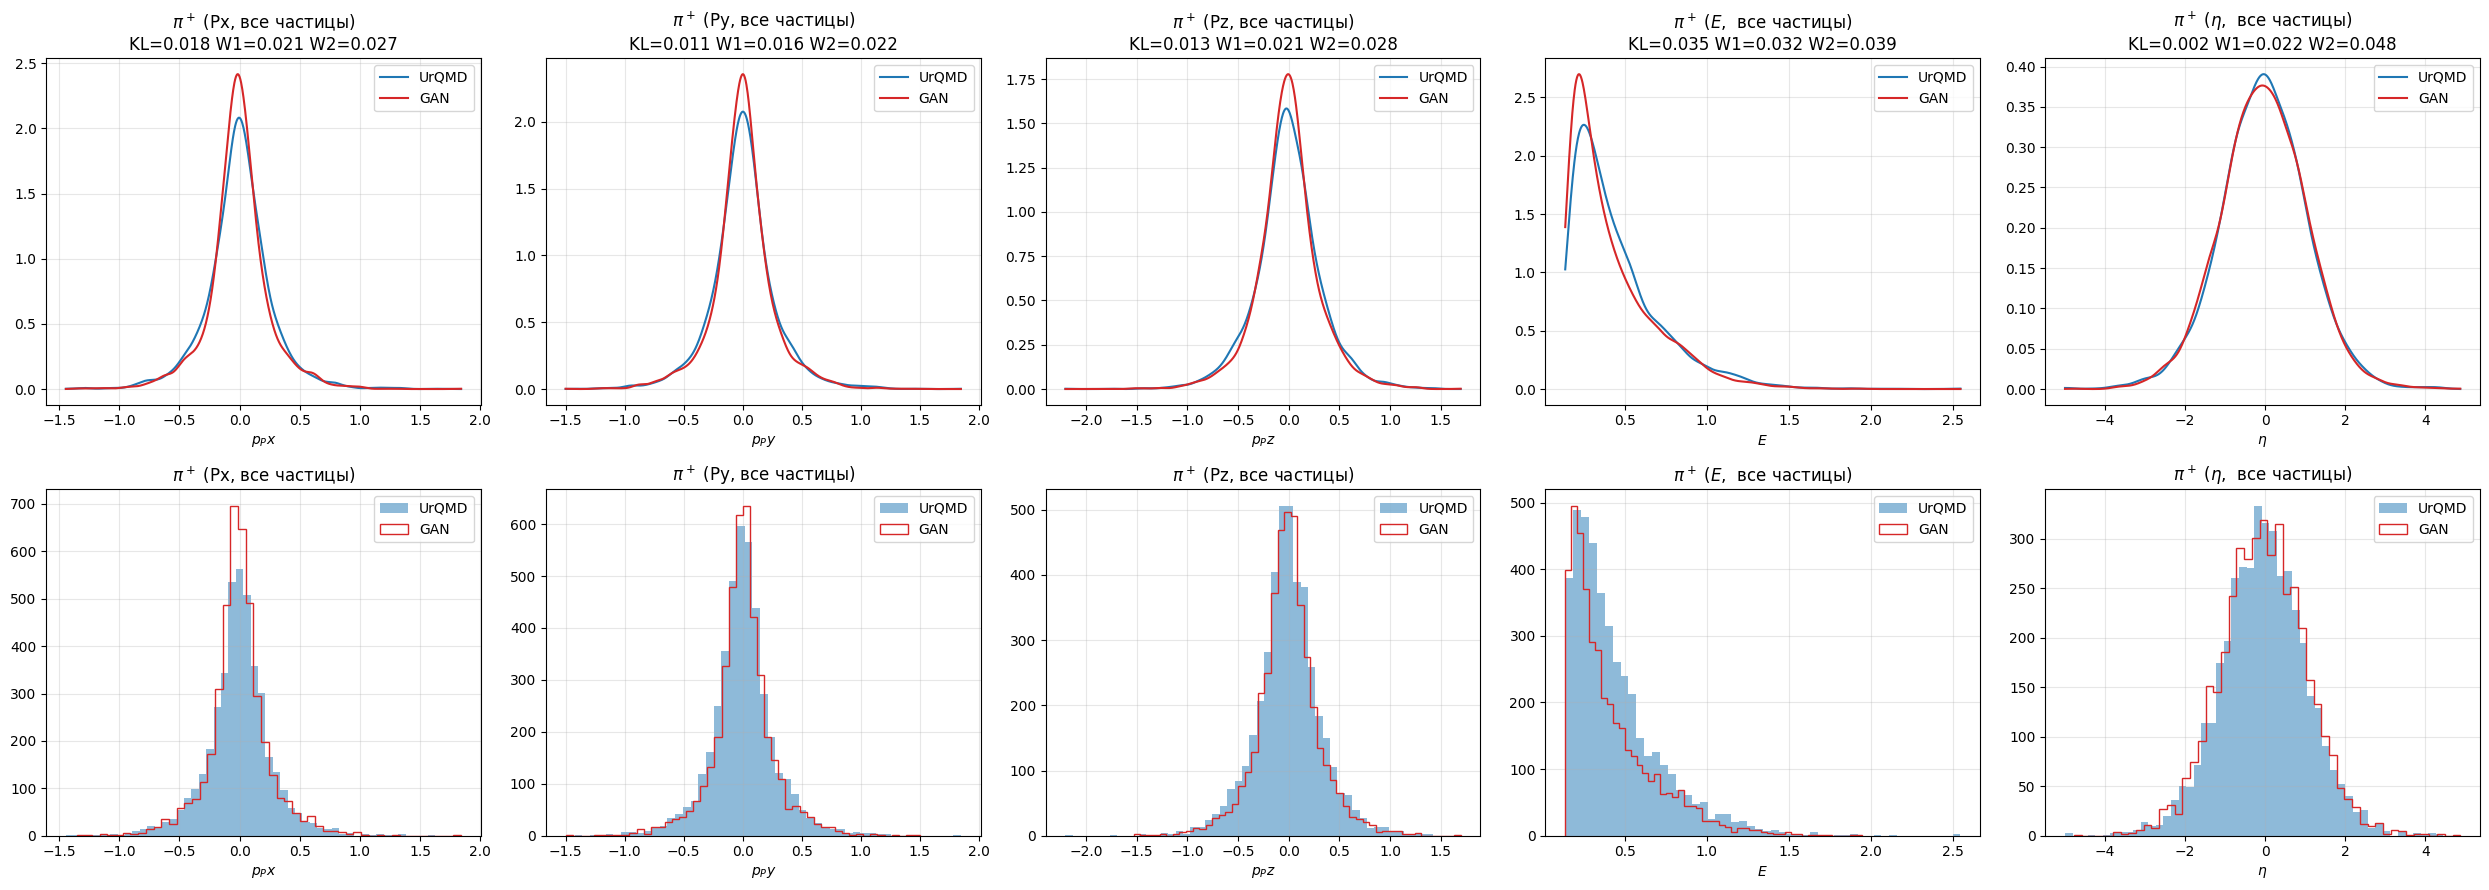

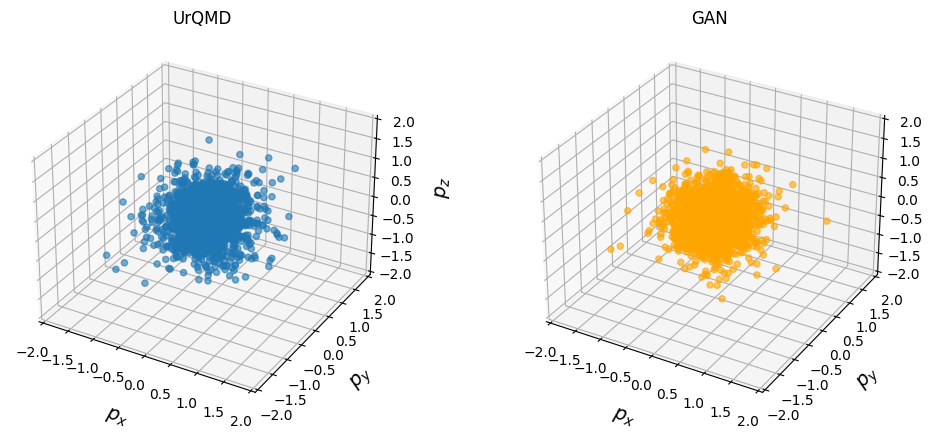

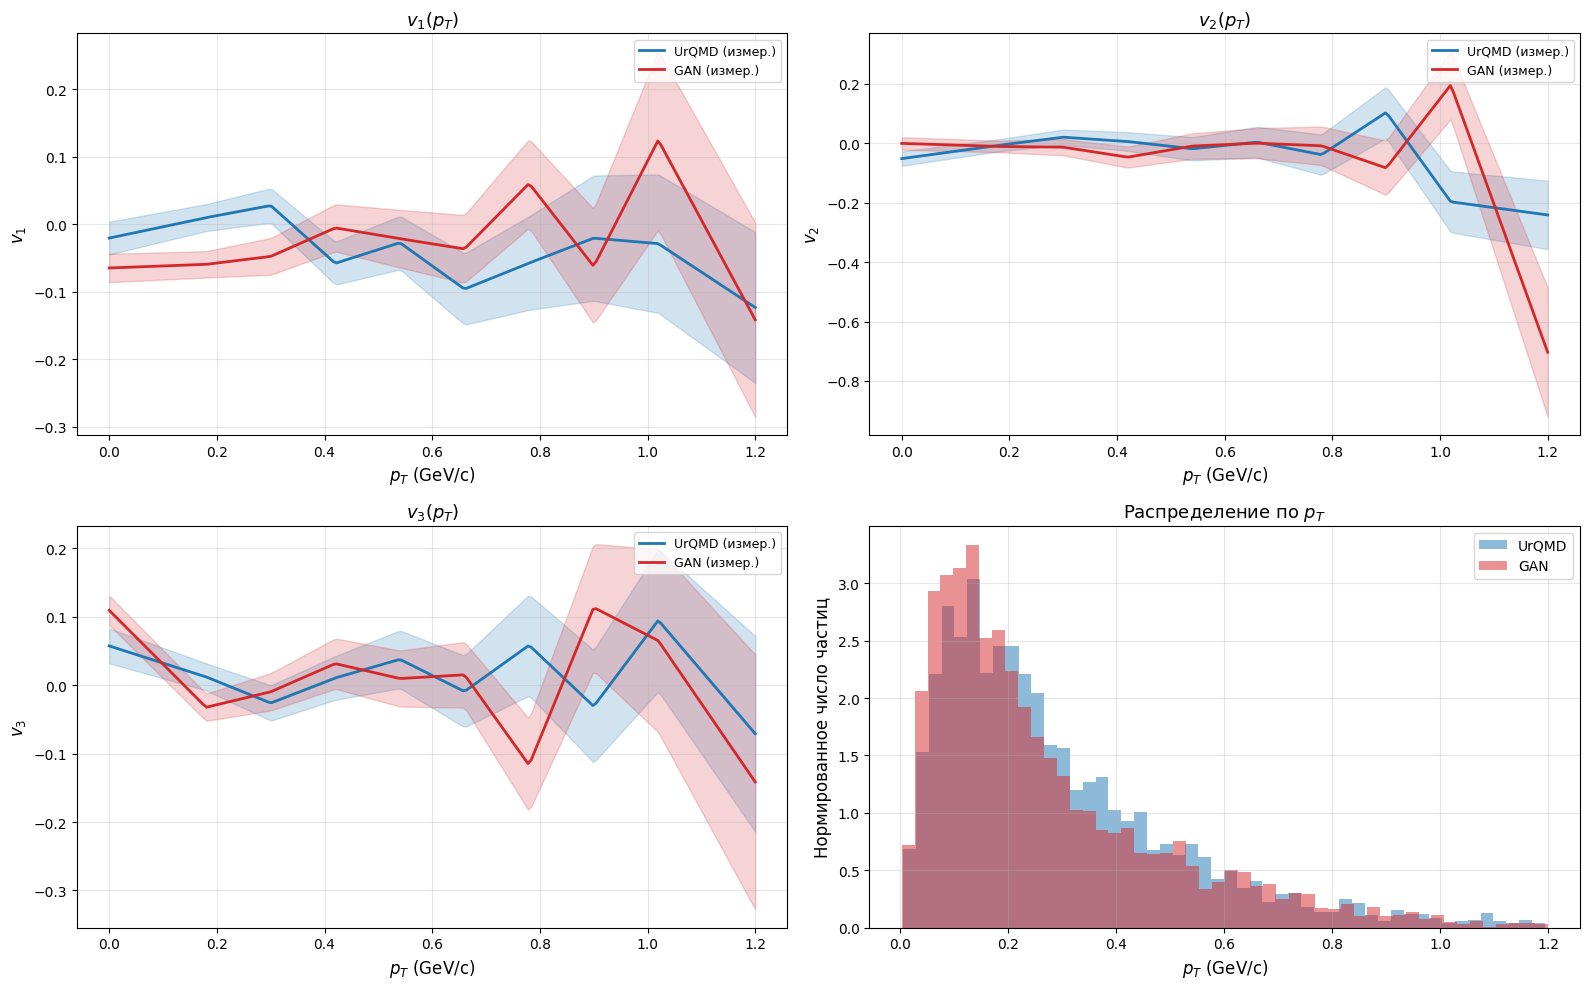

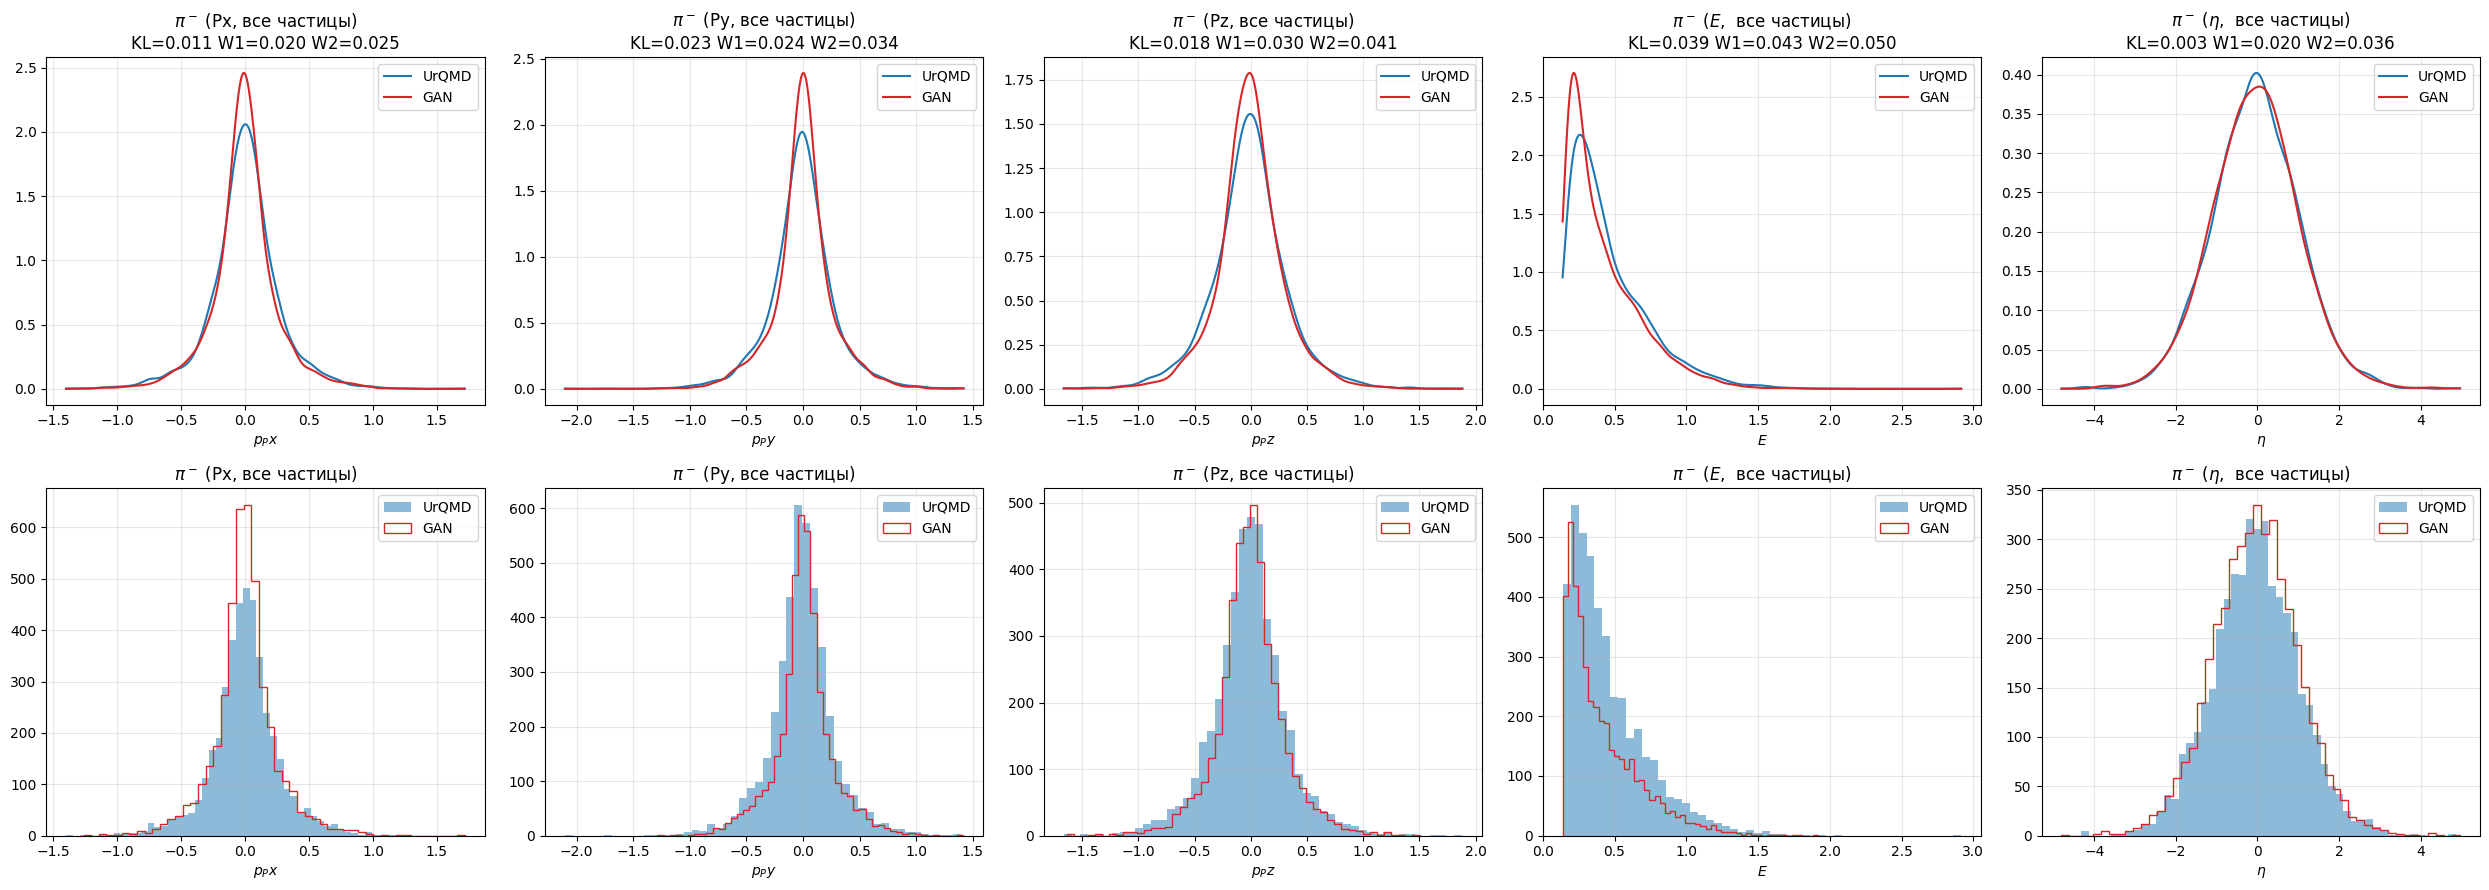

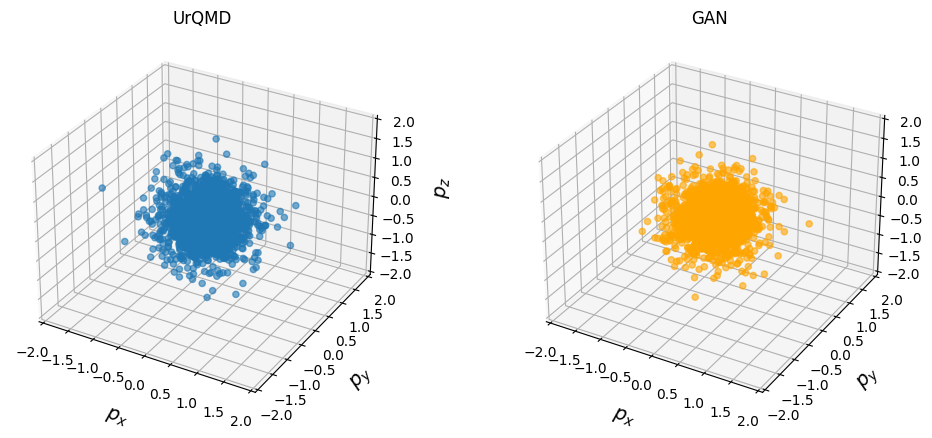

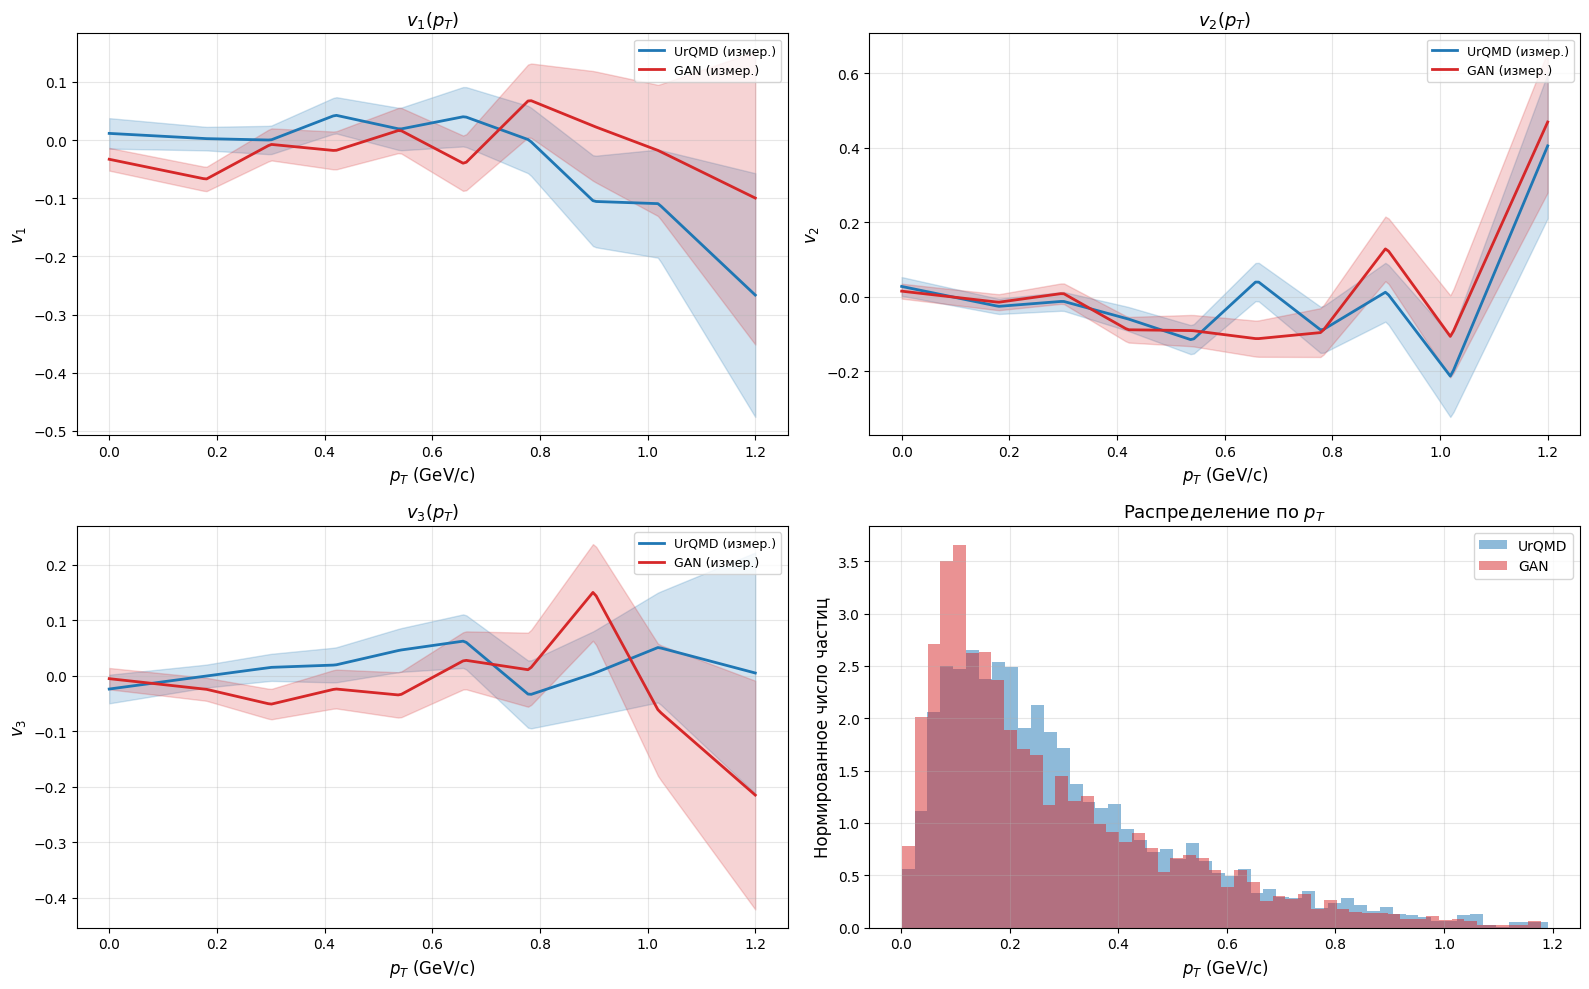

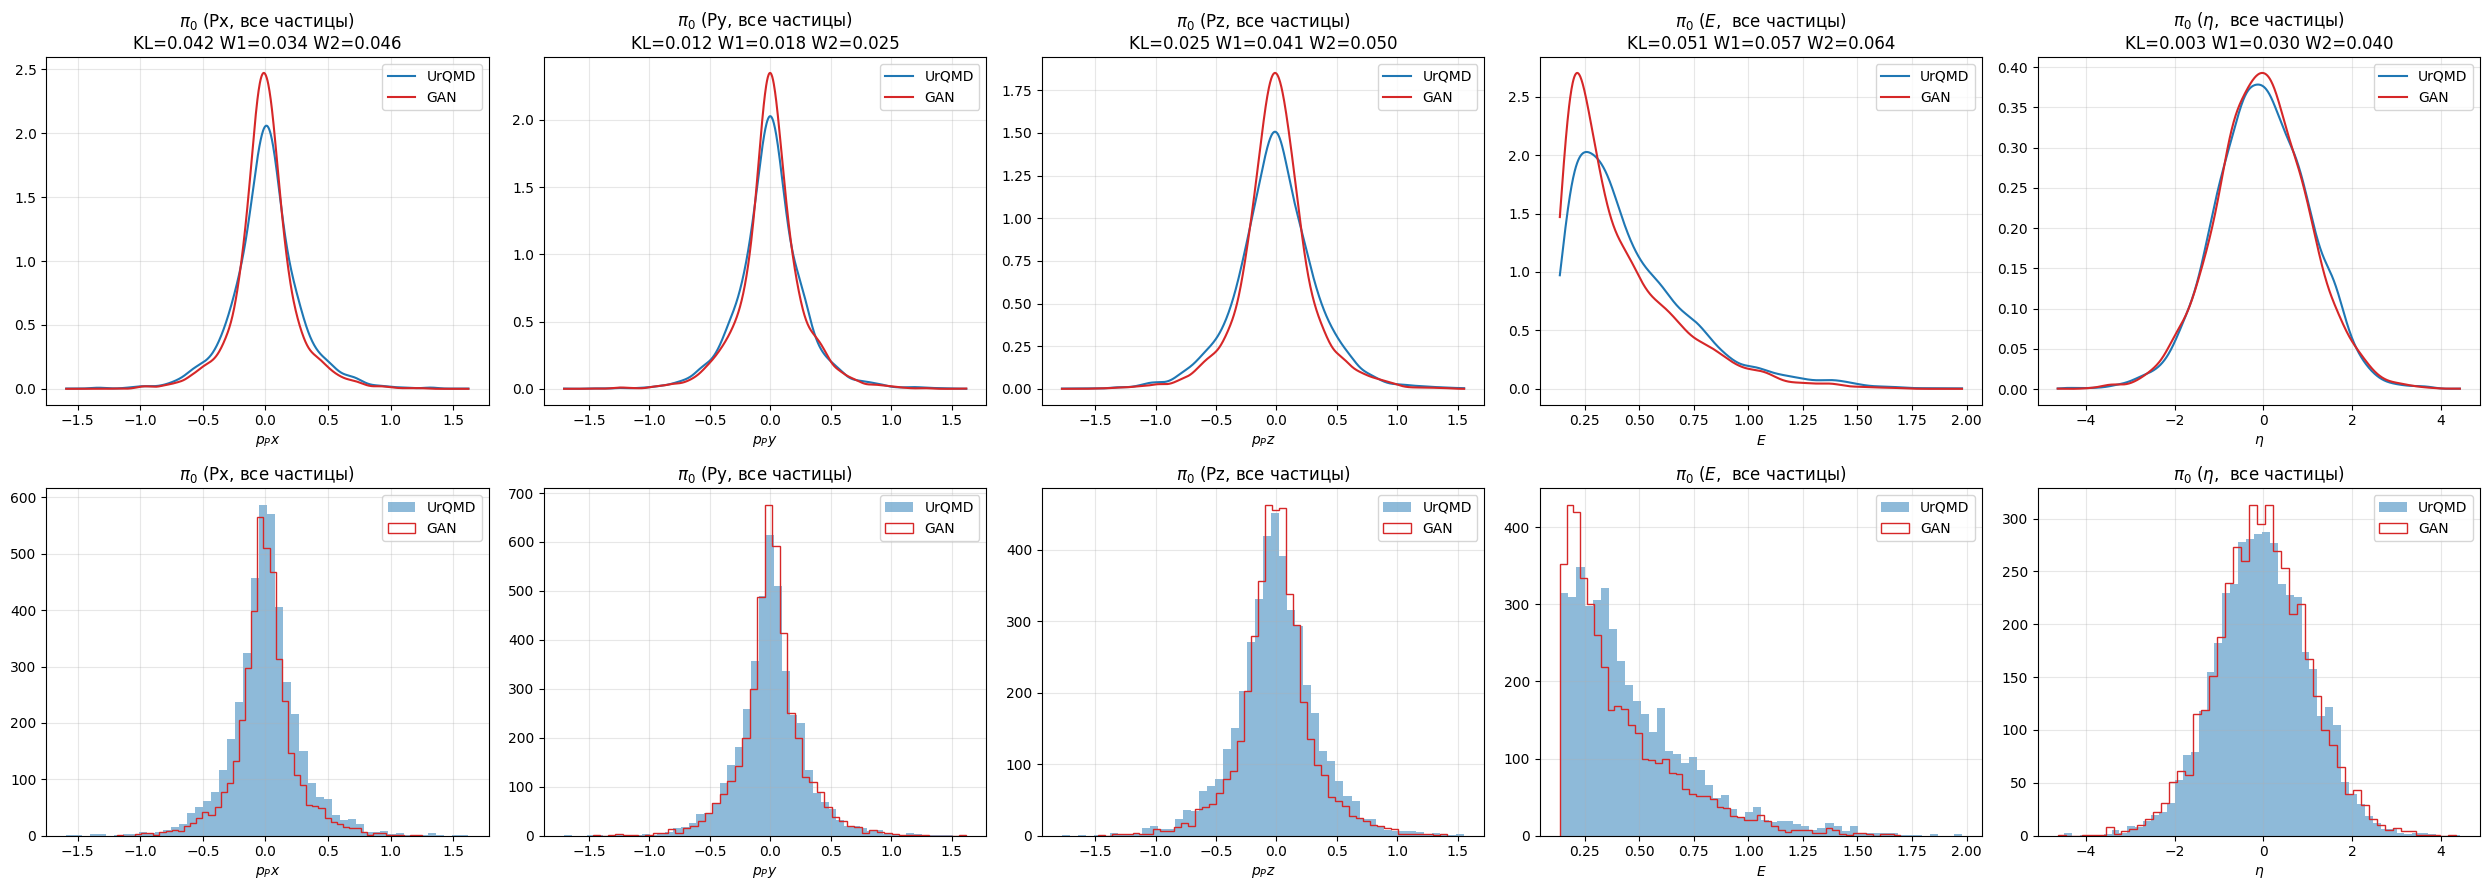

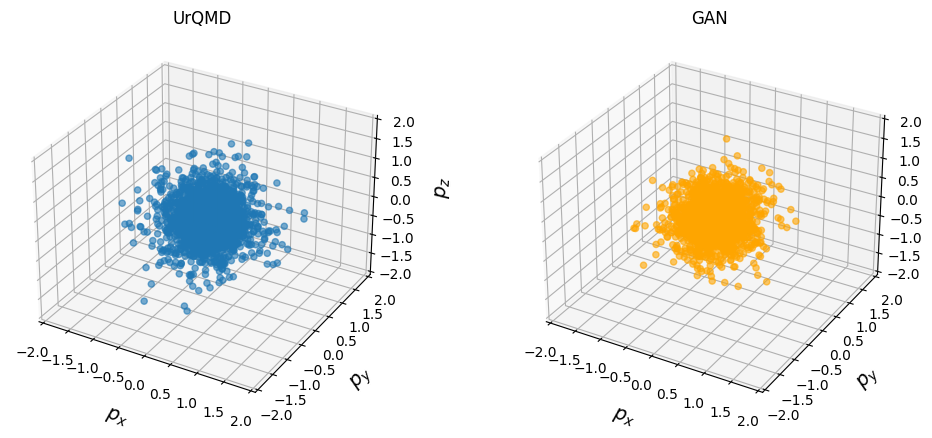

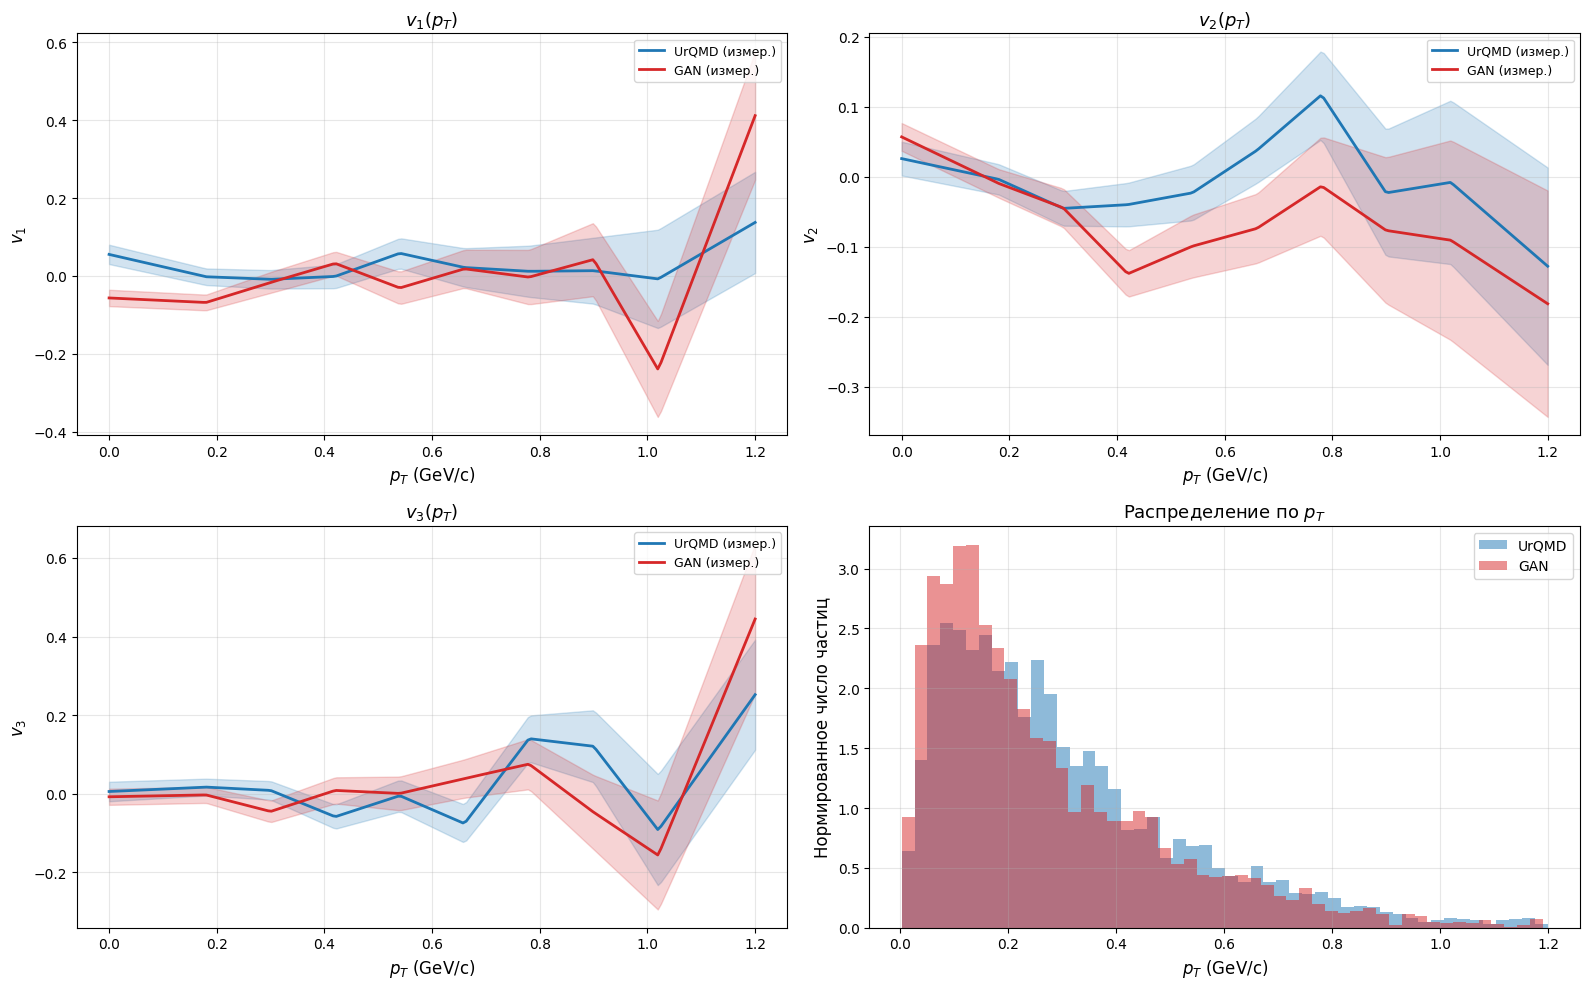

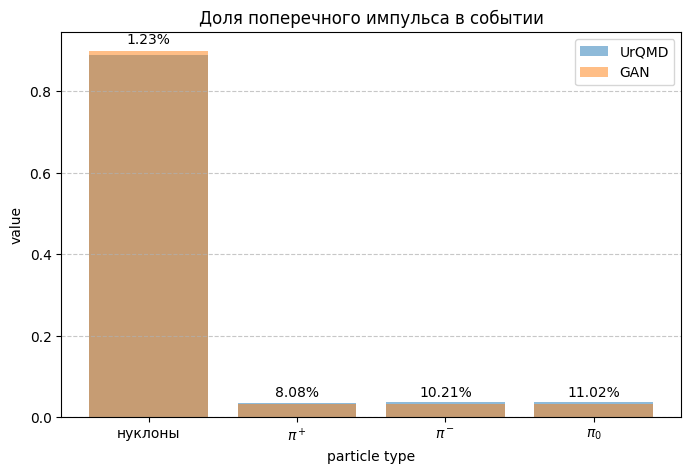

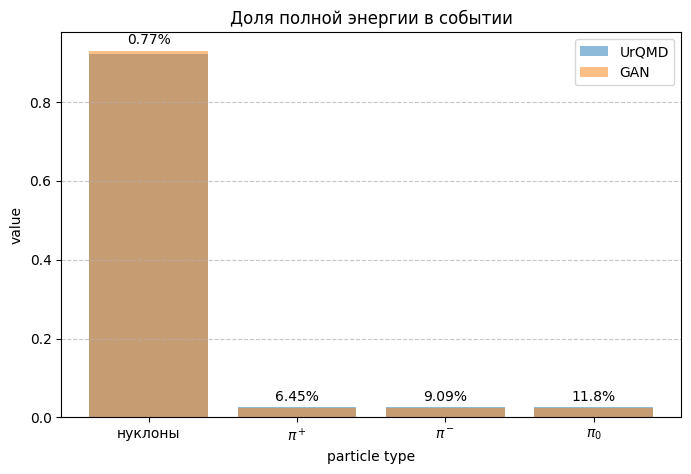

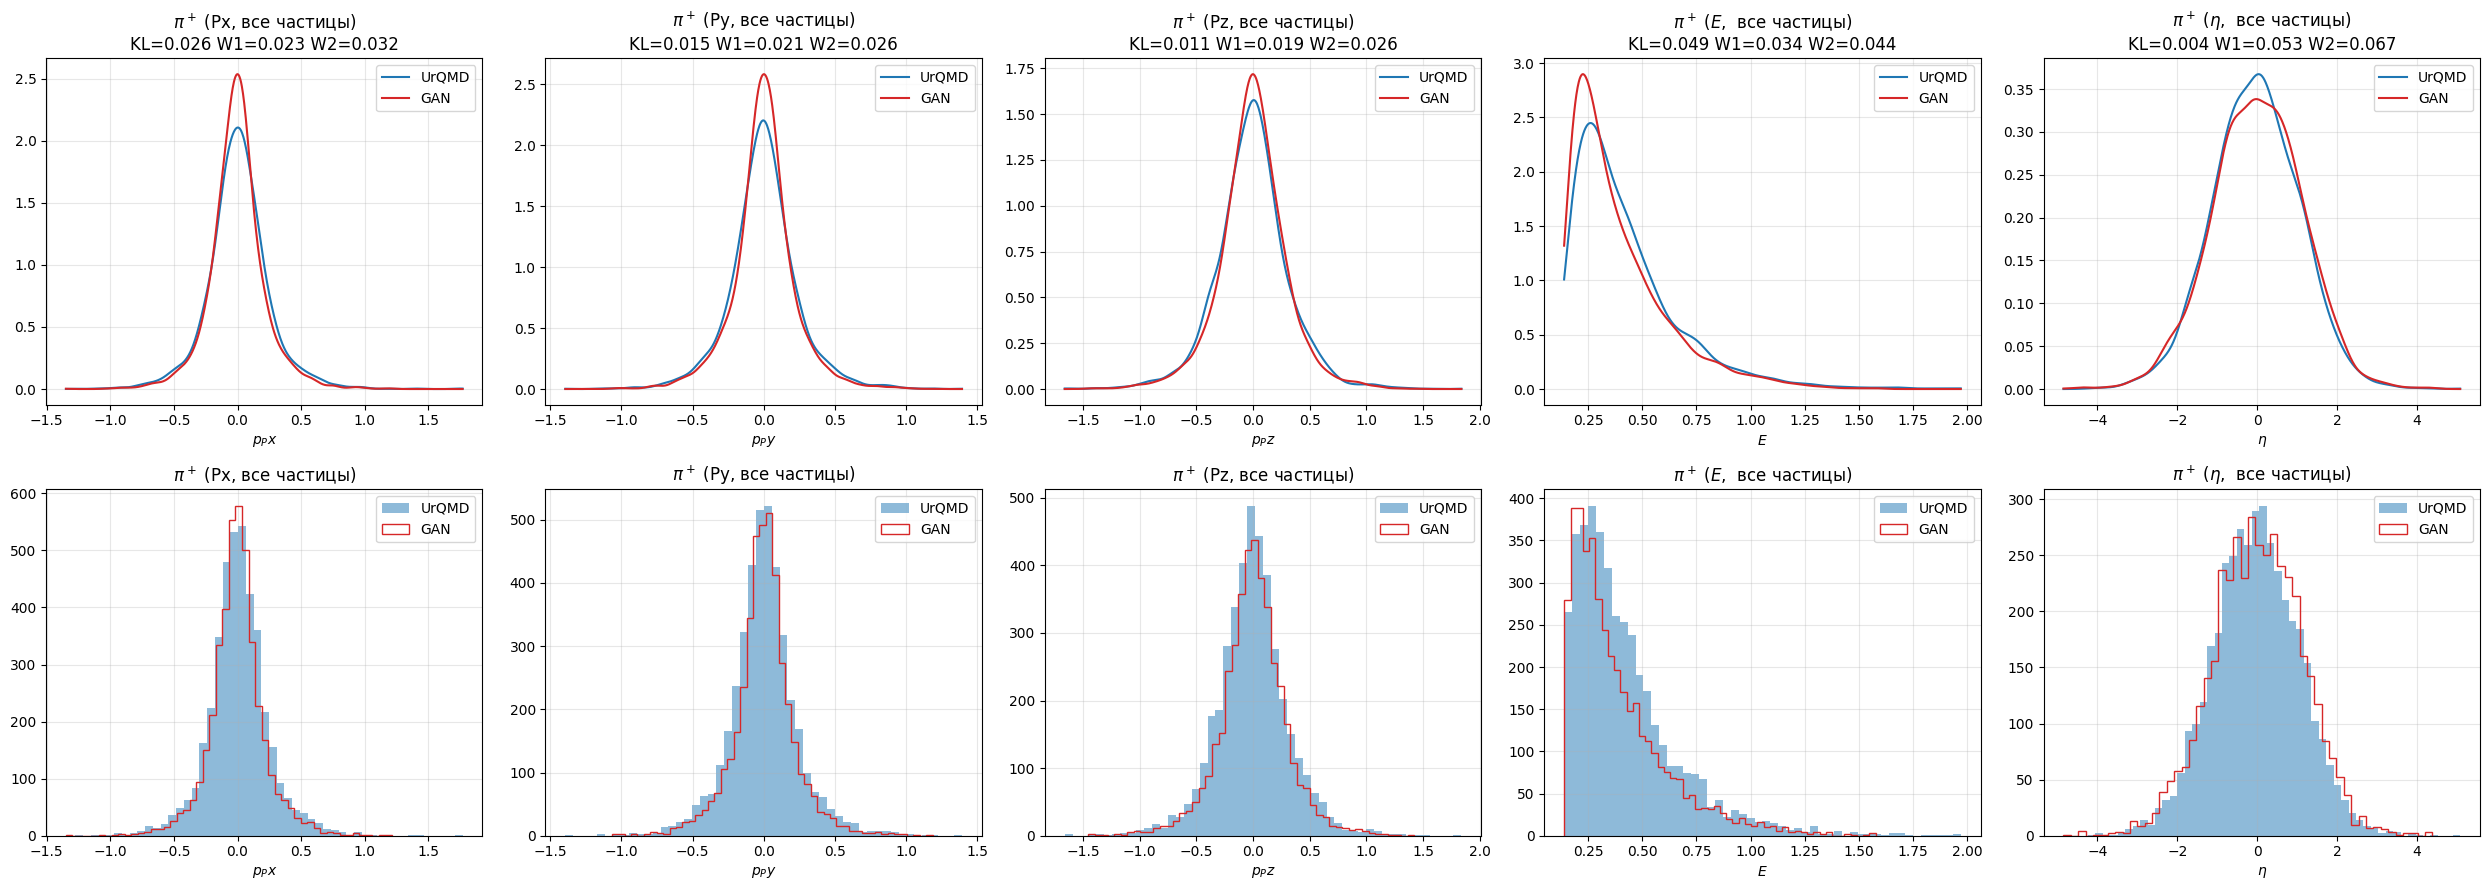

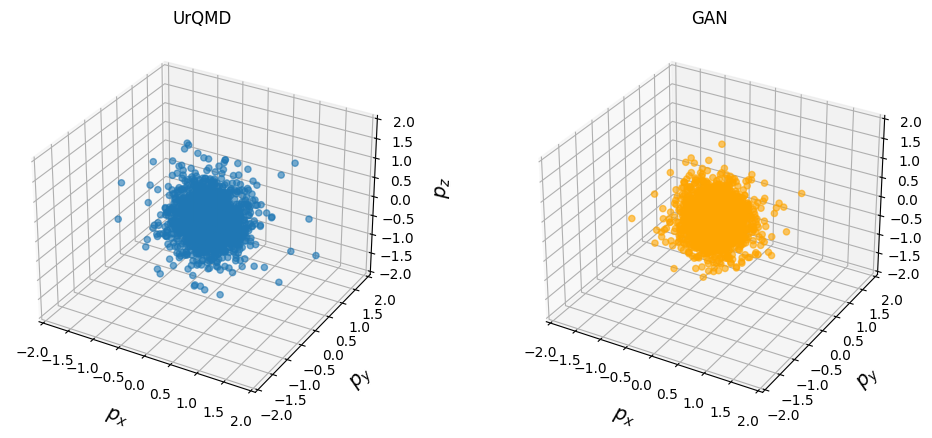

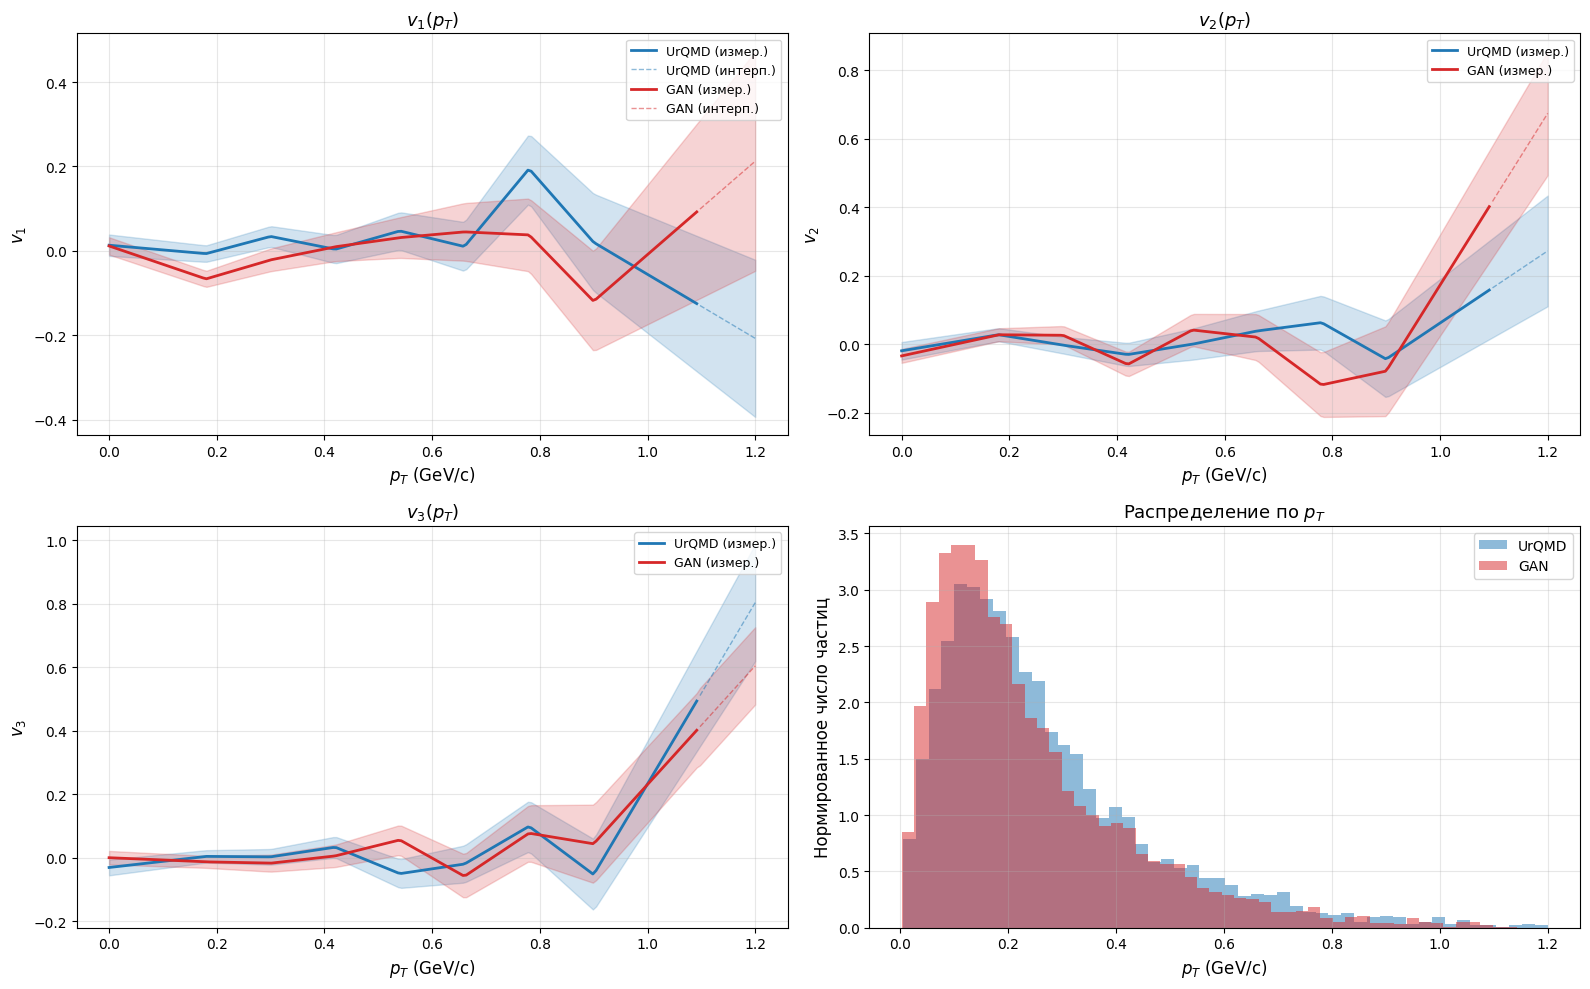

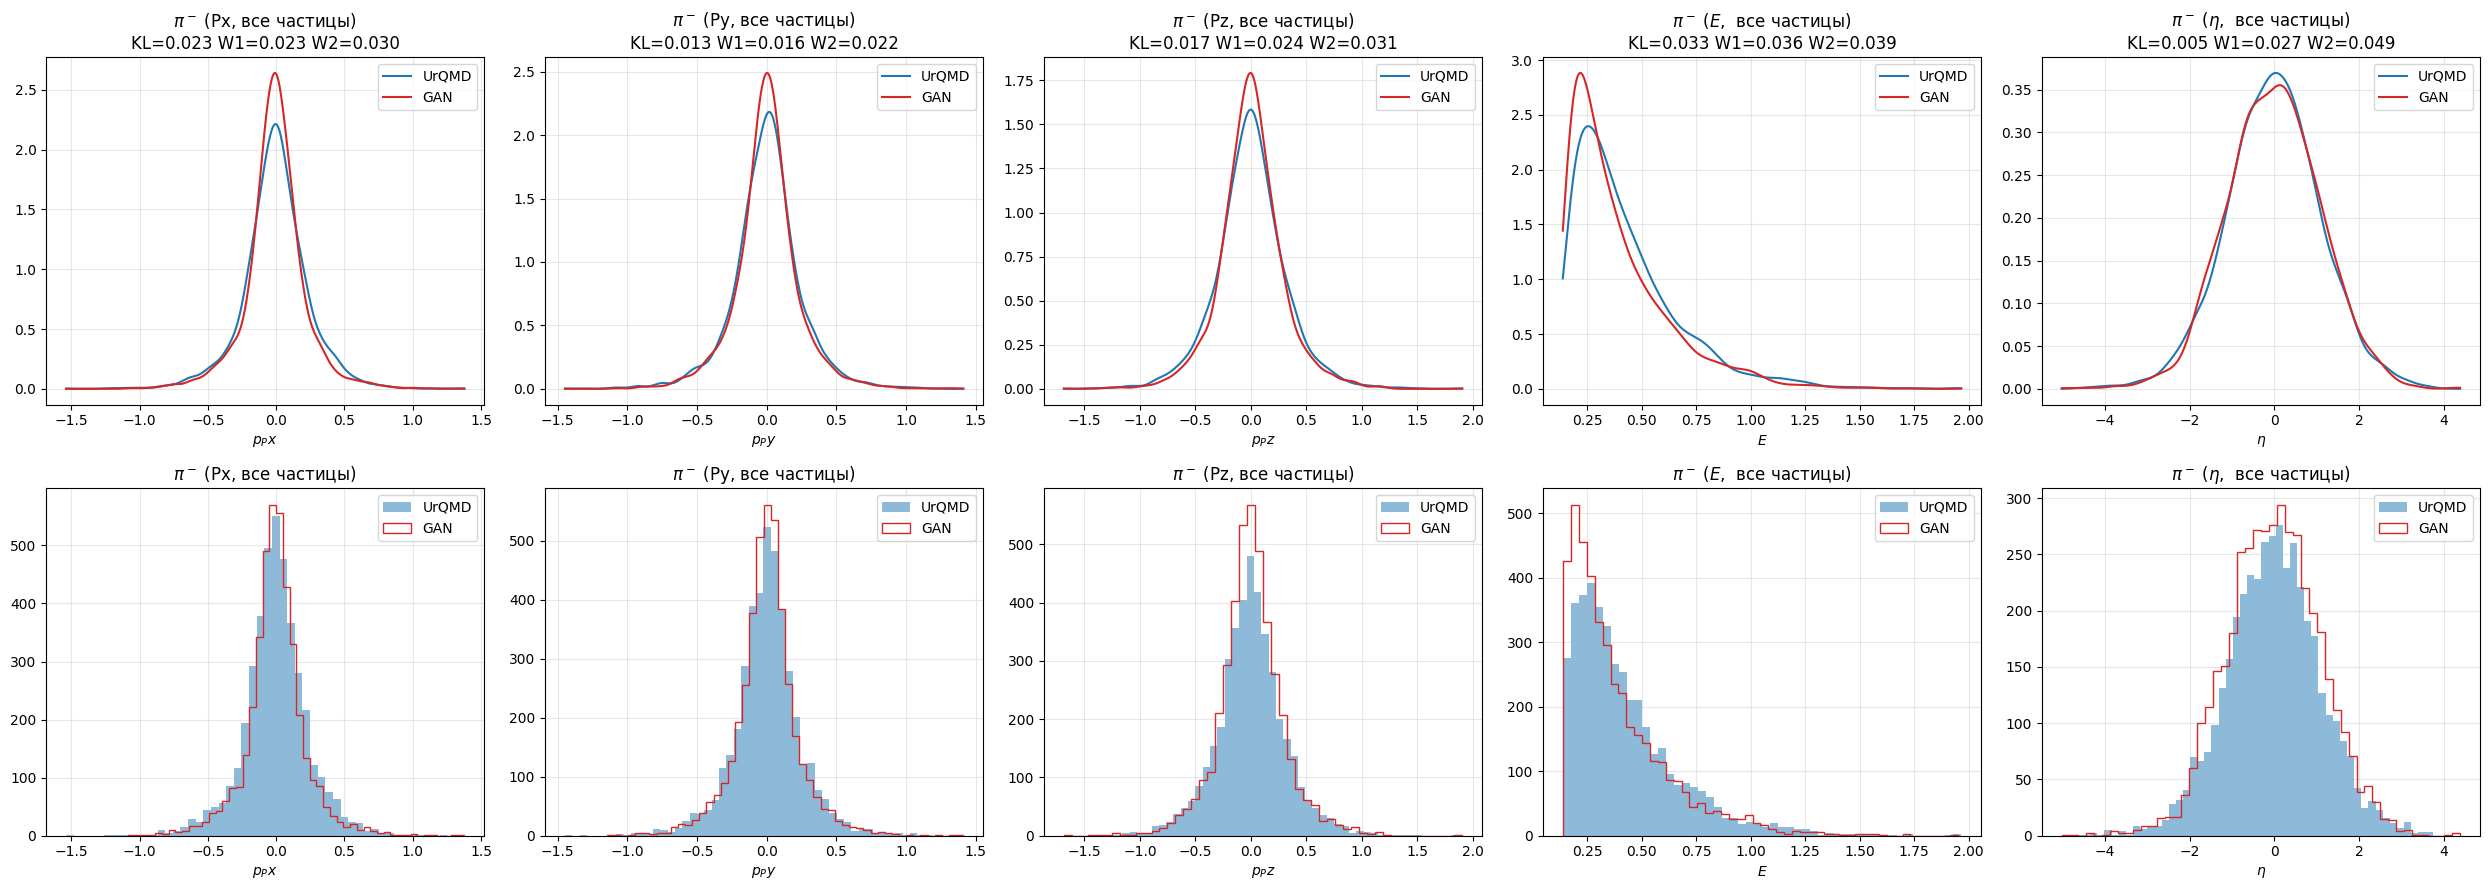

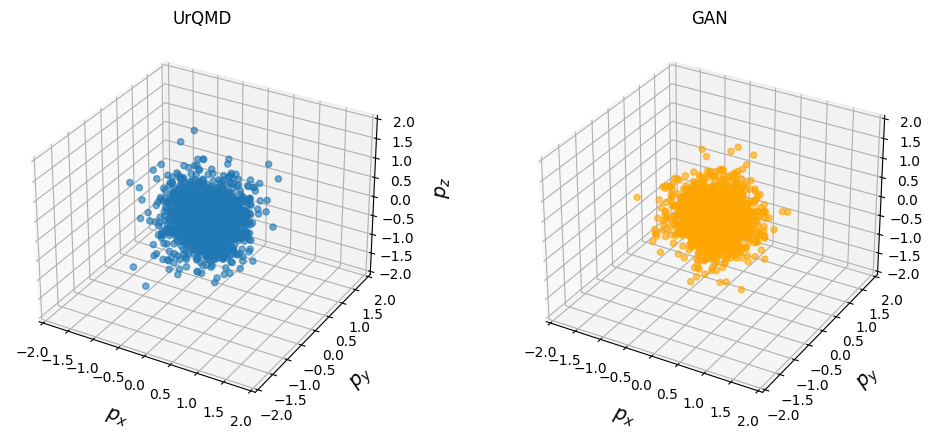

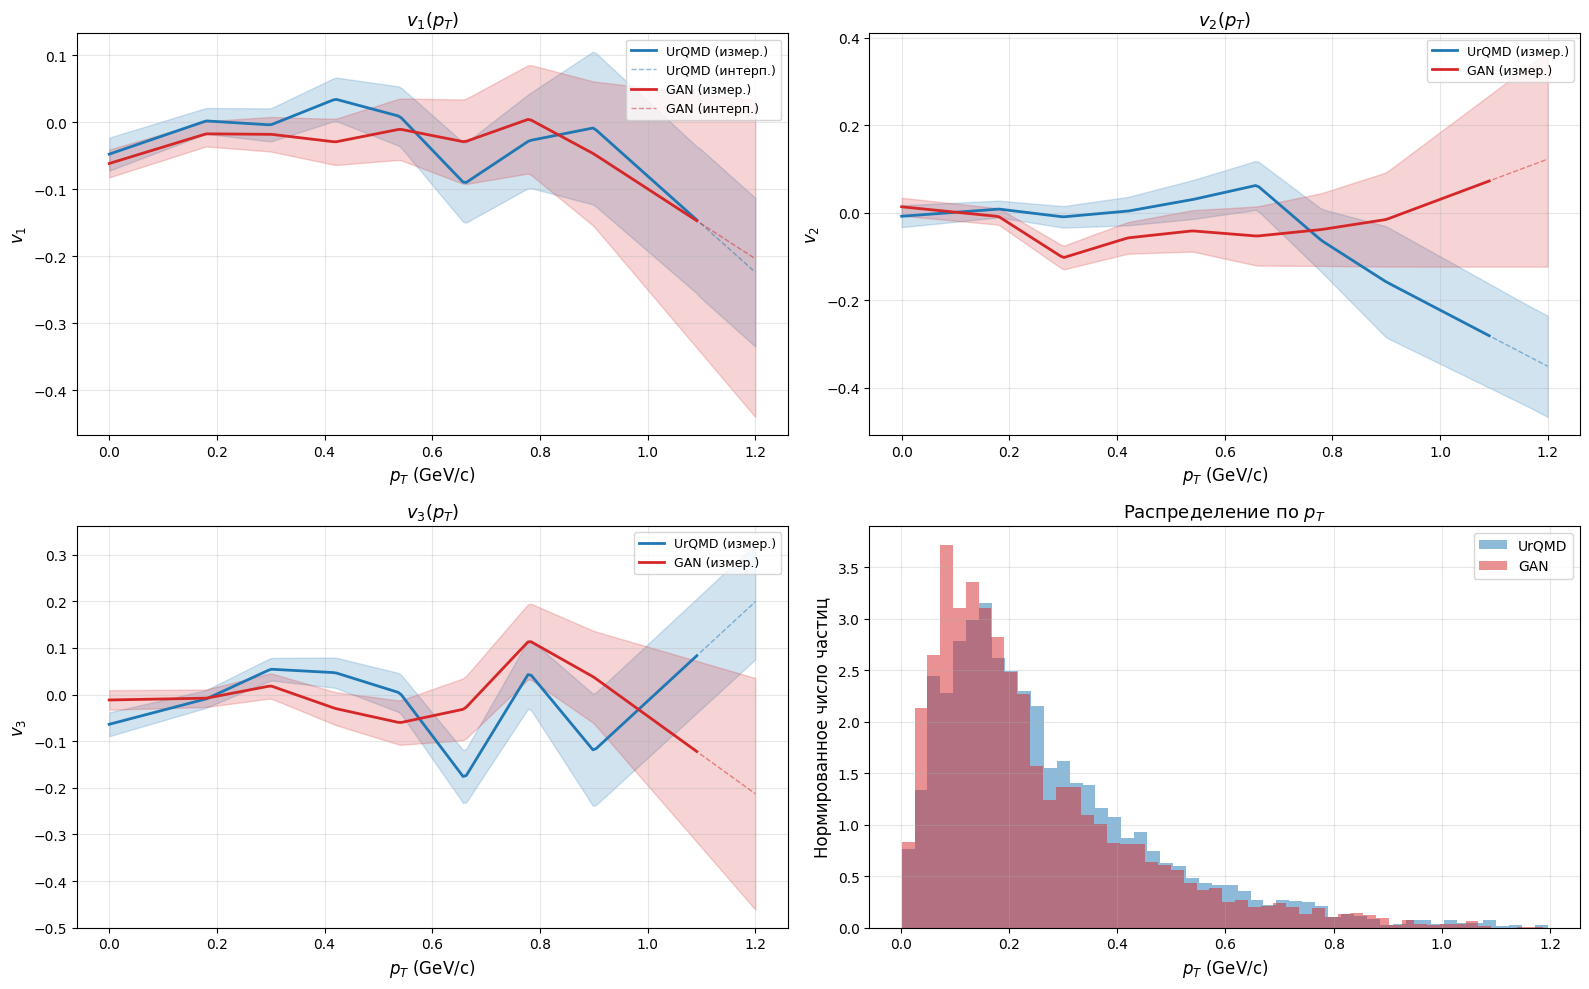

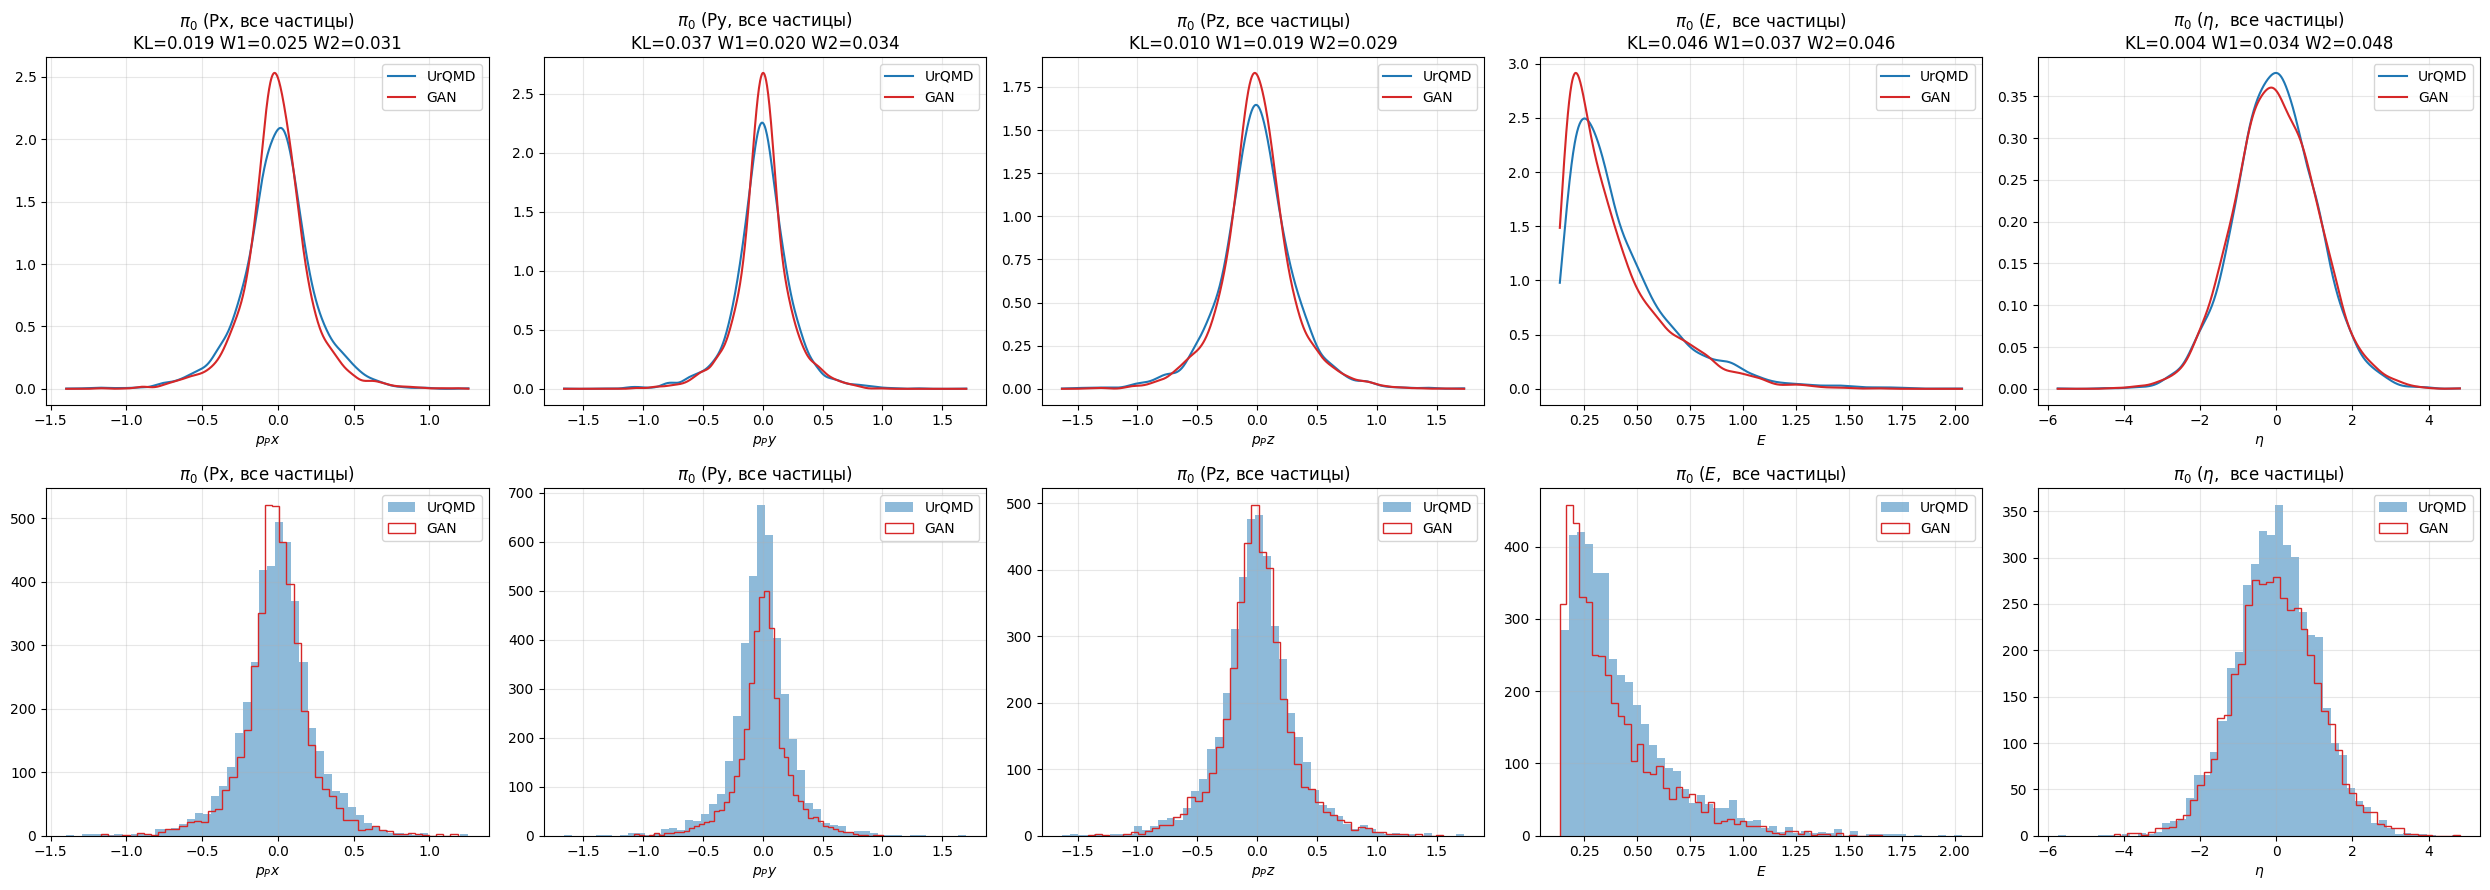

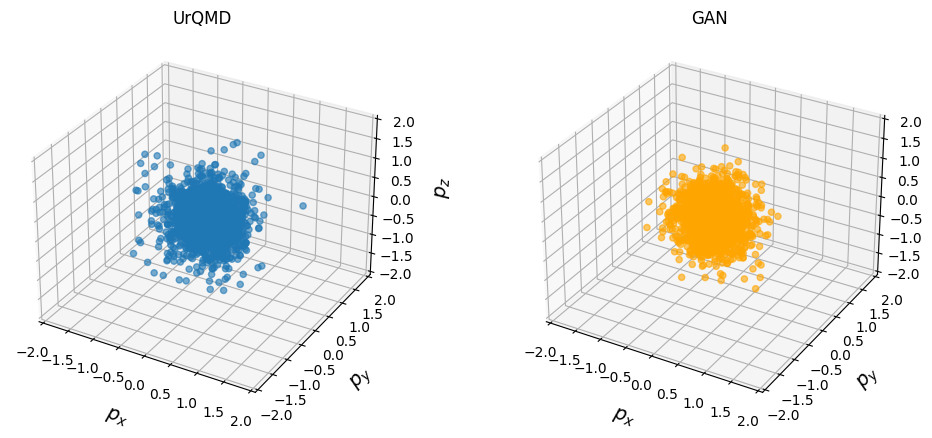

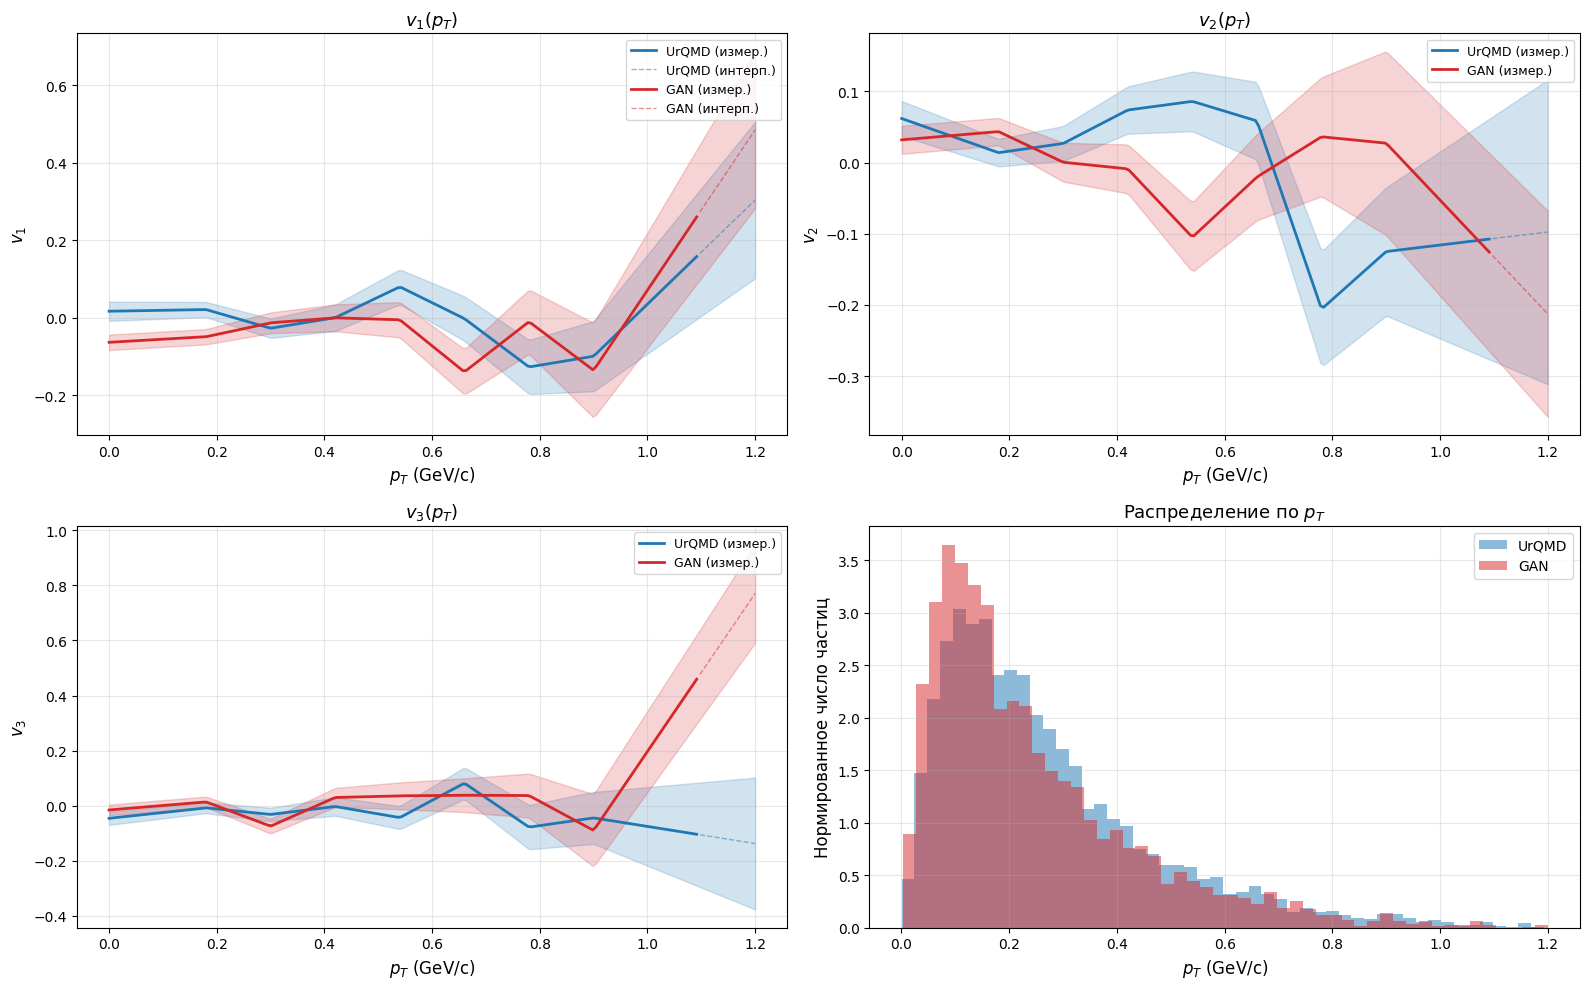

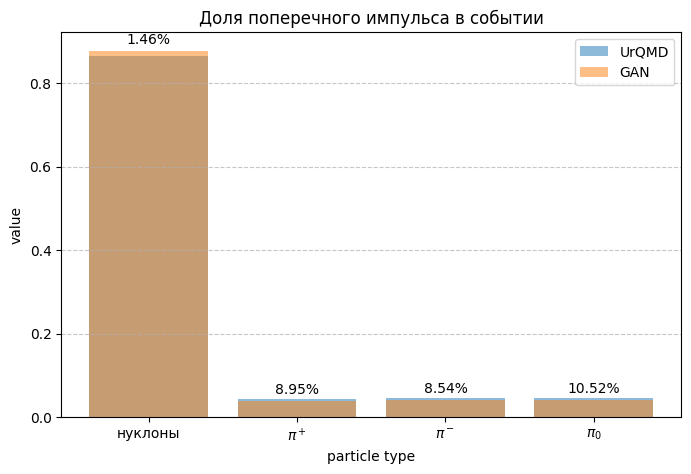

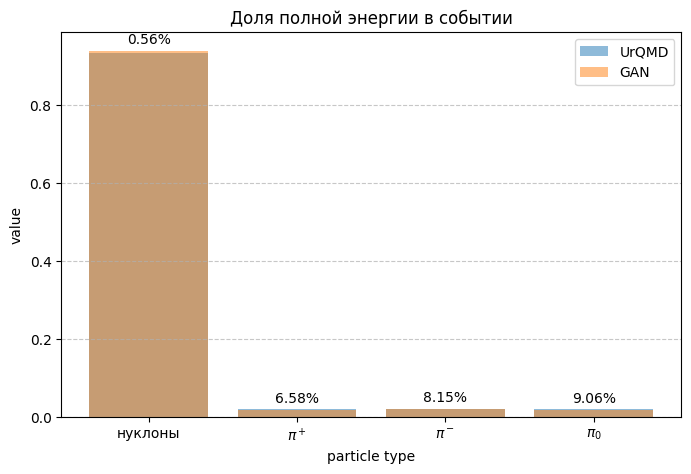

In [20]:
for n_modes in n_modes_lst:
    for seed in seeds:
        set_seed(seed)
        ratio = 1
        train_n_1_7 = int(0.8 * len(urqmd_1_7))
        val_n_1_7 = (len(urqmd_1_7) - train_n_1_7) // 2
        train_n_5 = ratio * train_n_1_7
        val_n_5 = ratio * val_n_1_7
        ids_1_7 = np.random.permutation(len(urqmd_1_7))
        ids_5 = np.random.permutation(len(urqmd_5))
        urqmd_train_1_7 = urqmd_1_7.iloc[ids_1_7[:train_n_1_7]]
        urqmd_val_1_7 = urqmd_1_7.iloc[ids_1_7[train_n_1_7 : train_n_1_7 + val_n_1_7]]
        urqmd_test_1_7 = urqmd_1_7.iloc[
            ids_1_7[train_n_1_7 + val_n_1_7 : train_n_1_7 + val_n_1_7 * 2]
        ]
        urqmd_train_5 = urqmd_5.iloc[ids_5[:train_n_5]]
        urqmd_val_5 = urqmd_5.iloc[ids_5[train_n_5 : train_n_5 + val_n_5]]
        urqmd_test_5 = urqmd_5.iloc[
            ids_5[train_n_5 + val_n_5 : train_n_5 + val_n_5 * 2]
        ]
        urqmd_train = pd.concat([urqmd_train_1_7, urqmd_train_5], ignore_index=True)
        urqmd_val = pd.concat([urqmd_val_1_7, urqmd_val_5], ignore_index=True)
        COUNT = {}
        COUNT_2 = {}
        for code in particles:
            selected_count = urqmd_train.apply(
                lambda x: (np.array(x["fParticles.fPdg"]) == code).sum(), axis=1
            ).values
            final_count = (
                int(np.percentile(selected_count, 0.95))
                if code in pions
                else selected_count.max()
            )
            mean_ = np.mean(selected_count)
            std_ = np.std(selected_count)
            if final_count == 0:
                final_count = int(selected_count.max())
            COUNT[code] = final_count
            COUNT_2[code] = {"mean": mean_, "std": std_}
        meson_count_max = max(
            {k: v for k, v in COUNT.items() if k not in nucleons}.values()
        )
        nucleon_count_max = max(
            {k: v for k, v in COUNT.items() if k in nucleons}.values()
        )
        train, cond_cols, nucl_cols, nucl_mask_cols = preprocess_urqmd(
            urqmd_train,
            max_size_t=meson_count_max,
            max_size_c=nucleon_count_max,
            return_cols=True,
        )
        val = preprocess_urqmd(
            urqmd_val, max_size_t=meson_count_max, max_size_c=nucleon_count_max
        )
        test_1_7 = preprocess_urqmd(
            urqmd_test_1_7, max_size_t=meson_count_max, max_size_c=nucleon_count_max
        )
        test_5 = preprocess_urqmd(
            urqmd_test_5, max_size_t=meson_count_max, max_size_c=nucleon_count_max
        )
        means = {}
        stds = {}
        for col in cond_cols:
            means[col] = train[col].mean()
            stds[col] = train[col].std()
            train[col] = (train[col] - means[col]) / stds[col]
            val[col] = (val[col] - means[col]) / stds[col]
            test_1_7[col] = (test_1_7[col] - means[col]) / stds[col]
            test_5[col] = (test_5[col] - means[col]) / stds[col]
        train_cond = train[cond_cols].values.astype(float)
        train_nucl = list(train[nucl_cols[0]].values)
        train_nucl_mask = list(train[nucl_mask_cols[0]].values)
        train_label = train["label"].values
        train_event = train["event"].values
        train_mom = list(train["target_moms"].values)
        train_mask = list(train["target_mask"].values)
        val_cond = val[cond_cols].values.astype(float)
        val_nucl = list(val[nucl_cols[0]].values)
        val_nucl_mask = list(val[nucl_mask_cols[0]].values)
        val_label = val["label"].values
        val_event = val["event"].values
        val_mom = list(val["target_moms"].values)
        val_mask = list(val["target_mask"].values)
        test_1_7_cond = test_1_7[cond_cols].values.astype(float)
        test_1_7_nucl = list(test_1_7[nucl_cols[0]].values)
        test_1_7_nucl_mask = list(test_1_7[nucl_mask_cols[0]].values)
        test_1_7_label = test_1_7["label"].values
        test_1_7_event = test_1_7["event"].values
        test_1_7_mom = list(test_1_7["target_moms"].values)
        test_1_7_mask = list(test_1_7["target_mask"].values)
        test_5_cond = test_5[cond_cols].values.astype(float)
        test_5_nucl = list(test_5[nucl_cols[0]].values)
        test_5_nucl_mask = list(test_5[nucl_mask_cols[0]].values)
        test_5_label = test_5["label"].values
        test_5_event = test_5["event"].values
        test_5_mom = list(test_5["target_moms"].values)
        test_5_mask = list(test_5["target_mask"].values)
        urqmd_train_dataset = TensorDataset(
            torch.tensor(train_mom, dtype=torch.float32),
            torch.tensor(train_cond, dtype=torch.float32),
            torch.tensor(train_label),
            torch.tensor(train_mask, dtype=torch.float32),
        )
        urqmd_train_dataloader = DataLoader(
            urqmd_train_dataset, batch_size=batch_size, shuffle=True
        )
        num_classes = len(pions)
        extern_cond_d = len(cond_cols)
        G = Pion_Gan_Generator(
            latent_global=latent_dim,
            latent_local=latent_local_dim,
            num_labels=num_classes,
            feats=feat_dim,
            max_len=meson_count_max,
            d_model=hid_dim,
            n_heads=n_heads,
            extern_cond_d=extern_cond_d,
            d_ff=hid_dim * 2,
            n_modes=n_modes,
            n_layers=num_layers_gen,
            #  use_weight_norm=True
        ).to(device)
        D = Pion_Gan_Discriminator(
            num_labels=num_classes,
            feats=feat_dim,
            d_model=hid_dim,
            n_heads=n_heads,
            d_ff=hid_dim * 2,
            extern_cond_d=extern_cond_d,
            n_layers=num_layers_disc,
            #  use_weight_norm=True
        ).to(device)

        opt_g = optim.Adam(G.parameters(), lr=lr, betas=betas)
        opt_d = optim.Adam(D.parameters(), lr=lr, betas=betas)

        G, G_shadow, D = train_and_test(
            G=G,
            D=D,
            train_loader=urqmd_train_dataloader,
            optim_G=opt_g,
            optim_D=opt_d,
            device=device,
            mode="lsgan",
            d_iters=d_iters,
            epochs=epochs,
            train_epoch_func=train_epoch_transformer,
            generate_func=generate_transformer,
            val_mom_obj={0: val_mom},
            val_cond_obj={0: val_cond},
            val_label_obj={0: val_label},
            val_mask_obj={0: val_mask},
            val_nucl_mask_obj={0: val_nucl_mask},
            val_nucl_obj={0: val_nucl},
            val_event_obj={0: val_event},
            test_mom_obj={1.7: test_1_7_mom, 5: test_5_mom},
            test_cond_obj={1.7: test_1_7_cond, 5: test_5_cond},
            test_label_obj={1.7: test_1_7_label, 5: test_5_label},
            test_mask_obj={1.7: test_1_7_mask, 5: test_5_mask},
            test_nucl_mask_obj={1.7: test_1_7_nucl_mask, 5: test_5_nucl_mask},
            test_nucl_obj={1.7: test_1_7_nucl, 5: test_5_nucl},
            test_event_obj={1.7: test_1_7_event, 5: test_5_event},
            metrics_mode_name=f"learn_{n_modes}",
            final_metrics=METRICS,
            seeds=[seed],
            num_classes=num_classes,
            meson_count_max=meson_count_max,
            use_shadow=True,
            ema_beta=0.999,
            model_name=f"learn_{n_modes}",
        )

## Анализ метрик

Ниже рассчитываем агрегированное по типам частиц и по рандом-сидам значение $W_1$ (среднее, СКО).

In [21]:
records = []
for model, seeds in METRICS.items():
    for seed, bs in seeds.items():
        for b, pions in bs.items():
            for pion, model_metrics in pions.items():
                for metric, value in model_metrics.items():
                    records.append(
                        {
                            "model": model,
                            "seed": seed,
                            "b": b,
                            "pion": pion,
                            "metric": metric,
                            "value": value,
                        }
                    )
df_records = pd.DataFrame(records)
res = (
    df_records.groupby(["model", "b", "metric"])["value"]
    .agg(["mean", "std"])
    .reset_index()
)
res

,model,b,metric,mean,std
0,learn_1,1.7,e,5.367500,0.000000
1,learn_1,1.7,e_kl,0.023575,0.000800
2,learn_1,1.7,e_kl_0,0.125603,0.109832
3,learn_1,1.7,e_w1,0.034123,0.009741
4,learn_1,1.7,e_w1_0,0.071965,0.019982
...,...,...,...,...,...
151,std,5.0,eta_w1_0,0.131237,0.007726
152,std,5.0,pt,8.925000,0.000000
153,std,5.0,v1,0.026475,0.029649
154,std,5.0,v2,0.008536,0.004194


Посмотрим модель, которая выдала наилучшую метрику $W_1$ для частицы с максимальным абсолютным значением импульса.